# Exercise 9a — matched JANA versus the minimal multiclass hybrid

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_9a_JANA.ipynb)

This exercise makes the missing control explicit.  Each campaign first fits a direct posterior and a normalized direct likelihood, freezes them, and then compares two estimators built from **the same simulations and checkpoints**:

1. **Matched-objective JANA direct/control:** use the fitted posterior and likelihood directly, with no classifier correction.
2. **Hybrid CE:** use the same frozen proposals, corrected by equal-prior multiclass classification trained with ordinary cross entropy only.  Conditional normalization is applied after training; normalization and bridge identities remain held-out checks.

For Figure 3, the hybrid proposals retain the literal original Exercise 9 dual hNPE--hNDE construction, but estimate each conditional density with a four-member flow mixture and each CE correction with ten independently initialized plain three-logit MLPs. All members use the same fixed 10,000 simulator pairs. The DDM campaign has one scientifically necessary exception. Its exchangeable observations mix a Bernoulli response with continuous reaction time, and Figure 6 requires a pointwise normalized likelihood for ELPD. DDM therefore keeps a joint four-parameter posterior flow mixture but uses a Bernoulli-response $\times$ scalar conditional log-RT flow mixture for $q_\eta$, plus plain data-set $S/P$ and event $S/L$ softmax heads combined into data-set three-class logits. Even there, the sole optimized correction loss is the overall equal-prior three-class CE.

The matched backend is intentional: the two Figure 3 networks have disjoint parameters, so minimizing their summed negative log likelihood is objective-equivalent to the pair of direct NPE/NLE fits used here.  It isolates the value added by CE instead of confounding it with a different simulation bank.  This is a matched-objective method control, not a byte-for-byte reconstruction of a historical TensorFlow/BayesFlow checkpoint.  In the DDM campaign, the same direct-control logic is retained but the DeepSet summary is regression-pretrained and frozen, so it is likewise not an exact reproduction of JANA's end-to-end summary training.

The Figure 3 campaign uses the pinned Gaussian Mixture and SIR simulators. The Figure 6 campaign uses the official DDM assets and, when enabled, the approximately 6 GB OSF bank already stored at `MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6/osfstorage`. Google Drive is mounted by default in Colab: simulation caches, checkpoints, numerical results, paper figures, the pinned JANA checkout, and the pre-downloaded OSF bank survive runtime resets. The notebook validates this bank but never downloads it. Every plot is exported as PDF, PNG, numerical data, and a standalone plotting script.

In [1]:
# Colab bootstrap: a Drive-backed checkout and persistent artifacts.
import importlib.util
import os
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version as package_version
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_GOOGLE_DRIVE = os.environ.get("EX9A_USE_DRIVE", "1") == "1"
IN_COLAB = "google.colab" in sys.modules
COLAB_DRIVE_ROOT = None


def run_command(*args, env=None, cwd=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env, cwd=cwd)


def installed_version(distribution):
    try:
        return package_version(distribution)
    except PackageNotFoundError:
        return None


if IN_COLAB:
    if USE_GOOGLE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        COLAB_DRIVE_ROOT = Path(
            os.environ.get(
                "EX9A_DRIVE_ROOT",
                "/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab",
            )
        )
        COLAB_DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
        repository = COLAB_DRIVE_ROOT / "nsbi-lhc-toolkit"
    else:
        repository = Path("/content/nsbi-lhc-toolkit")

    if not (repository / ".git").exists():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run_command(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, repository, env=clone_env,
        )
    else:
        run_command("git", "-C", repository, "remote", "set-url", "origin", REPO_URL)
        run_command("git", "-C", repository, "fetch", "origin", BRANCH)
        run_command("git", "-C", repository, "checkout", BRANCH)
        run_command("git", "-C", repository, "pull", "--ff-only", "origin", BRANCH)
    run_command(
        "git", "-C", repository, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )

    requirements = []
    if installed_version("nflows") != "0.14":
        requirements.append("nflows==0.14")
    if importlib.util.find_spec("pyarrow") is None:
        requirements.append("pyarrow")
    if requirements:
        run_command(sys.executable, "-m", "pip", "install", "-q", *requirements)

    importlib.invalidate_caches()
    assert installed_version("nflows") == "0.14"
    print("Pinned runtime: nflows=0.14; pyarrow available for DDM bank validation")
    os.chdir(repository / "workshops" / "ml4hep_tifr_colab")
    print("Colab workshop:", Path.cwd())
else:
    print("Local runtime: Colab bootstrap skipped.")

Mounted at /content/drive
Pinned runtime: nflows=0.14; pyarrow available for DDM bank validation
Colab workshop: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab


## Pinned references and the head-to-head contract

- JANA paper: Radev, Schmitt, Pratz, Picchini, Köthe & Bürkner, *JANA: Jointly Amortized Neural Approximation of Complex Bayesian Models*, arXiv:2302.09125, version 3.
- Reference implementation: `bayesflow-org/JANA-Paper`, commit `6cbbc94faf0aa85147986f7f9516d13a52551bd4` (MIT license).
- The paper repository pins BayesFlow commit `153dfefadd347717b7aeb9c4872a4b51ac04e83c`.  Its Figure 3 priors, simulators, scaling, and stabilization are translated directly below.
- Official large DDM data: the pre-downloaded OSF project `2nbk6` at `MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6/osfstorage`. The directory is validated before it can be used; the notebook contains no OSF download path.

The standard JANA loss is

$$
\mathcal L_{\rm JANA}=
-\mathbb E_{p(\theta,x)}\log q_\phi(\theta\mid x)
-\mathbb E_{p(\theta,x)}\log q_\eta(x\mid\theta).
$$

Because the posterior and likelihood networks have disjoint parameters, the loss separates exactly.  Training the two terms with separate optimizers is therefore objective-equivalent to optimizing their sum.  We call their direct composition **matched-objective JANA** in Figure 3.  The hybrid uses those same frozen flows and adds only the CE-trained multiclass correction.  This tests the proposed ML ingredient without changing the simulation bank; a separate historical-checkpoint reproduction would answer a different, architecture-dependent question.  The DDM keeps a matched direct-density control but, as documented below, uses a mixed-event likelihood factorization and freezes a regression-pretrained DeepSet summary before the posterior NLL fit.

“Posterior SBC” conditions on fresh simulator observations.  “Joint SBC” draws an observation from the learned likelihood and then applies the learned posterior.  For every rank comparison, JANA direct and Hybrid CE use the same held-out truths, rank count, and randomized-rank jitter.  Ground-truth densities, official posteriors, normalization estimates, bridge statistics, Bridge sampling, and PSIS are evaluation-only and cannot influence a checkpoint.

In [2]:
import copy
import csv
import hashlib
import json
import math
import os
import subprocess
import sys
from dataclasses import asdict, dataclass
from importlib.metadata import version as package_version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from scipy.integrate import odeint
from scipy.special import log_ndtr, logsumexp, ndtr
from torch.utils.data import DataLoader, TensorDataset


def _find_workshop_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "workshops" / "ml4hep_tifr_colab",
        Path("/content/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab"),
    ]
    for candidate in candidates:
        if (candidate / "utils_hnpe.py").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find utils_hnpe.py. Run from the workshop directory or "
        "clone nsbi-lhc-toolkit under /content."
    )


WORKSHOP_DIR = _find_workshop_dir()
if IN_COLAB and USE_GOOGLE_DRIVE:
    DEFAULT_PERSIST_ROOT = Path("/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA")
else:
    DEFAULT_PERSIST_ROOT = WORKSHOP_DIR / "persistent_exercise_artifacts"
PERSIST_ROOT = Path(os.environ.get("EX9A_PERSIST_ROOT", DEFAULT_PERSIST_ROOT)).resolve()
PERSIST_ROOT.mkdir(parents=True, exist_ok=True)
if str(WORKSHOP_DIR) not in sys.path:
    sys.path.insert(0, str(WORKSHOP_DIR))

from utils_benchmark import infer_parameter_transform
from utils_hnpe import (
    install_nflows_rqs_float64_retry,
    sample_spline_flow_ensemble,
    spline_flow_ensemble_log_prob,
    train_spline_flow_ensemble,
)

# Install the audited inverse-RQS precision retry before any flow is sampled.
NFLOWS_VERSION = package_version("nflows")
RQS_NUMERIC_GUARD = install_nflows_rqs_float64_retry(required_version="0.14")
RQS_NUMERIC_GUARD_ACTIVE = any(
    bool(getattr(RQS_NUMERIC_GUARD, flag, False))
    for flag in ("_hybrid_float64_retry", "_exercise9_float64_retry", "_ex9b_float64_retry")
)
if not RQS_NUMERIC_GUARD_ACTIVE:
    raise RuntimeError("The audited nflows inverse-RQS guard was not installed.")

SEED = 230209125
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")
print("Workshop:", WORKSHOP_DIR)
print("Device:", DEVICE)
print("Persistent artifact root:", PERSIST_ROOT)

Workshop: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab
Device: cuda
Persistent artifact root: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA


## Workload profiles

`tutorial` and `paper` both preserve the fixed 10,000-call Figure 3 training budget, four flow members per conditional density, ten classifier members, batch size 32, and the complete 250-epoch $10^{-4}\rightarrow10^{-9}$ step schedule. Only Monte-Carlo candidates and diagnostic sample sizes differ. `smoke` remains a deliberately small path test. DDM uses its documented exchangeable mixed-event factorization; `tutorial` may train on a documented subset of the official bank, while only `paper` uses the full cached campaign.

In [3]:
PROFILES = {
    "smoke": dict(
        n_train=512, n_calibration=48, flow_ensemble=1, classifier_ensemble=1,
        flow_epochs=2, classifier_epochs=2,
        class_width=96, class_layers=2, flow_batch_size=32, classifier_batch_size=32,
        training_patience=2,
        diagnostic_contexts=16, diagnostic_inner=4,
        rank_draws=32, posterior_candidates=96, likelihood_candidates=64,
        ddm_datasets=128, ddm_trials_min=24, ddm_trials_max=32,
        ddm_event_cap=4_096, ddm_eval_datasets=3,
    ),
    "tutorial": dict(
        n_train=10_000, n_calibration=1_000, flow_ensemble=4, classifier_ensemble=10,
        flow_epochs=250, classifier_epochs=250,
        class_width=1024, class_layers=4, flow_batch_size=32, classifier_batch_size=32,
        training_patience=250,
        diagnostic_contexts=256, diagnostic_inner=24,
        rank_draws=250, posterior_candidates=1_024,
        likelihood_candidates=256,
        ddm_datasets=12_000, ddm_trials_min=80, ddm_trials_max=120,
        ddm_event_cap=1_500_000, ddm_eval_datasets=20,
    ),
    "paper": dict(
        n_train=10_000, n_calibration=1_000, flow_ensemble=4, classifier_ensemble=10,
        flow_epochs=250, classifier_epochs=250,
        class_width=1024, class_layers=4, flow_batch_size=32, classifier_batch_size=32,
        training_patience=250,
        diagnostic_contexts=512, diagnostic_inner=64,
        rank_draws=250, posterior_candidates=4_096,
        likelihood_candidates=1_024,
        ddm_datasets=None, ddm_trials_min=80, ddm_trials_max=120,
        ddm_event_cap=None, ddm_eval_datasets=100,
    ),
}

PROFILE = "paper"             # smoke | tutorial | paper
RUN_FIG3 = True
RUN_DDM = False                # requires the pinned JANA checkout + OSF bank
ALLOW_PINNED_GIT_CLONE = True  # source/assets only; safe on persistent Drive
JANA_OSF_ACCESS_MODE = "pre_downloaded_drive_only"
FORCE_RETRAIN = False           # matching Drive checkpoints are reused

CFG = PROFILES[PROFILE]
RUN_TAG = f"{PROFILE}_v11_10k_deep_ensembles_step_lr"
MODEL_DIR = PERSIST_ROOT / "models_exercise9a_JANA" / RUN_TAG
OUTPUT_DIR = PERSIST_ROOT / "exercise9a_JANA_figures_scripts" / RUN_TAG
CACHE_DIR = PERSIST_ROOT / "cache_exercise9a_JANA" / RUN_TAG
for directory in (MODEL_DIR, OUTPUT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TRAINING_OBJECTIVE_VERSION = "equal_prior_multiclass_ce_only_v1"
CLASSIFIER_ARCHITECTURE_VERSION = "plain_relu_mlp_no_regularization_v1"
FLOW_ARCHITECTURE_VERSION = "original_exercise9_joint_rqs_v1"
DDM_CLASS_GROUP_SCHEMA = "ddm_coherent_S_P_L_encoder_aligned_v2"
INITIAL_LEARNING_RATE = 1.0e-4
MINIMUM_LEARNING_RATE = 1.0e-9
LEARNING_RATE_DROP_FACTOR = 0.1
LEARNING_RATE_STEP_EPOCHS = 40
NORMALIZATION_ESTIMATOR = "heldout_independent_A_B_cross_mass_v3"
BRIDGE_ESTIMATOR = "heldout_iid_unbiased_sample_variance_v2"
SIMULTANEOUS_ECDF_MC = 5_000 if PROFILE == "smoke" else 20_000

if PROFILE != "smoke":
    if CFG["n_train"] != 10_000:
        raise ValueError("The JANA comparison must retain the fixed 10,000-pair simulator bank.")
    if CFG["flow_ensemble"] != 4 or CFG["classifier_ensemble"] != 10:
        raise ValueError("The full JANA comparison requires 4 flows and 10 classifiers.")

print(json.dumps({"profile": PROFILE, **CFG}, indent=2))
print("Models:", MODEL_DIR)
print("Caches:", CACHE_DIR)
print("Results/figures:", OUTPUT_DIR)


{
  "profile": "paper",
  "n_train": 10000,
  "n_calibration": 1000,
  "flow_ensemble": 4,
  "classifier_ensemble": 10,
  "flow_epochs": 250,
  "classifier_epochs": 250,
  "class_width": 1024,
  "class_layers": 4,
  "flow_batch_size": 32,
  "classifier_batch_size": 32,
  "training_patience": 250,
  "diagnostic_contexts": 512,
  "diagnostic_inner": 64,
  "rank_draws": 250,
  "posterior_candidates": 4096,
  "likelihood_candidates": 1024,
  "ddm_datasets": null,
  "ddm_trials_min": 80,
  "ddm_trials_max": 120,
  "ddm_event_cap": null,
  "ddm_eval_datasets": 100
}
Models: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/models_exercise9a_JANA/paper_v11_10k_deep_ensembles_step_lr
Caches: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/cache_exercise9a_JANA/paper_v11_10k_deep_ensembles_step_lr
Results/figures: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/paper_v11_10k_deep_ensembles_step_lr


## Figure 3: matched-objective JANA first; deep-ensemble CE correction second

For Figure 3, the two direct flows are first trained with $\mathcal L_{\rm JANA}$ above. Their uncorrected posterior and likelihood form the matched-objective direct control and are then frozen. The Figure 3 hybrid proposal is exactly the original Exercise 9 construction:

\[
q_\phi(\boldsymbol\theta\mid x),\qquad
q_\eta(x\mid\boldsymbol\theta),
\]

where $\boldsymbol\theta$ denotes the **whole** parameter vector. In particular, a parameter pair such as $(\mu,\alpha)$ is one two-dimensional flow target, not $q(\mu\mid x)q(\alpha\mid\mu,x)$. Each conditional density is now an equal-weight mixture of four independently initialized flows. Every member retains the original Exercise 9 architecture: ten quadratic-spline coupling layers, width 512, four hidden blocks, 16 bins, tail bound 5, and zero dropout.

The simulator budget remains fixed at **10,000 pairs**, as in the JANA comparison. Both flow and classifier members train for 250 epochs with minibatch size 32. The learning rate is $10^{-4}$ for epochs 1--40 and is divided by ten every 40 epochs, reaching $10^{-9}$ for epochs 201--250. Patience spans the full 250-epoch schedule, and the best held-out checkpoint is restored. There is no dropout or weight decay.

Let $S(\theta,x)=\rho(\theta)p(x\mid\theta)$, $P(\theta,x)=m_\rho(x)q_\phi(\theta\mid x)$, and $L(\theta,x)=\rho(\theta)q_\eta(x\mid\theta)$. Ten independently initialized plain MLPs return unrestricted logits $(\ell_S,\ell_P,\ell_L)$. For each member,

\[
(\pi_S,\pi_P,\pi_L)=\operatorname{softmax}(\ell_S,\ell_P,\ell_L),\qquad
r_P=\frac{\pi_S}{\pi_P},\quad r_L=\frac{\pi_S}{\pi_L}.
\]

The ensemble corrections are the arithmetic means of the ten positive ratio estimates. This is the usual mixture-of-ratios estimator; the notebook takes its logarithm only when a log density or bridge identity requires it. The **only** classifier loss for every member is

\[
\mathcal L_{\rm train}=\mathcal L_{\rm CE}^{S/P/L}.
\]

There is no direct-$a$ BCE, $-\log 2$ term, preflight objective, normalization or bridge penalty, dropout, weight decay, LayerNorm, BatchNorm, residual connection, output clipping, or other regularization. Because a class minibatch preserves complete matched $S/P/L$ groups, a nominal classifier row budget of 32 corresponds to 10 groups (30 rows) per optimizer step.

Conditional normalization remains a **post-training density correction**,

\[
\widehat p(\theta\mid x)=\frac{q_\phi(\theta\mid x)r_P(\theta,x)}{Z_P(x)},
\qquad Z_P(x)=\mathbb E_{q_\phi(\theta\mid x)}r_P(\theta,x),
\]

and analogously for the likelihood. Independent held-out banks report normalization and bridge consistency only after CE checkpoint selection. They never enter gradients or checkpoint selection.

“JANA direct” uses the same four-member normalized flow mixtures without classifier correction. “Hybrid CE” adds the ten-member CE ratio ensemble. Thus the comparison isolates the correction while holding the flow proposals and 10,000 simulator calls fixed. These are matched-objective/control labels, not claims that a historical paper checkpoint was loaded. The DDM campaign uses the same training schedule and ensemble counts, with its separately documented mixed discrete/continuous factorization.


In [4]:
def seed_everything(seed):
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def as_2d(values, name):
    values = np.asarray(values, dtype=np.float32)
    if values.ndim == 1:
        values = values[:, None]
    if values.ndim != 2 or not np.isfinite(values).all():
        raise ValueError(f"{name} must be a finite two-dimensional array.")
    return values


def array_digest(*arrays):
    digest = hashlib.sha256()
    for array in arrays:
        value = np.ascontiguousarray(np.asarray(array))
        digest.update(str(value.shape).encode())
        digest.update(str(value.dtype).encode())
        digest.update(value.view(np.uint8))
    return digest.hexdigest()



def classifier_members(model_or_models):
    if isinstance(model_or_models, nn.Module):
        return (model_or_models,)
    members = tuple(model_or_models)
    if not members or not all(isinstance(member, nn.Module) for member in members):
        raise TypeError("Expected a classifier or a non-empty classifier ensemble.")
    return members


def set_classifier_mode(model_or_models, training):
    for member in classifier_members(model_or_models):
        member.train(bool(training))
    return model_or_models


def scheduled_learning_rate(epoch):
    if int(epoch) < 0:
        raise ValueError("Epoch must be non-negative.")
    return max(
        MINIMUM_LEARNING_RATE,
        INITIAL_LEARNING_RATE
        * LEARNING_RATE_DROP_FACTOR ** (int(epoch) // LEARNING_RATE_STEP_EPOCHS),
    )


def set_optimizer_learning_rate(optimizer, epoch):
    value = scheduled_learning_rate(epoch)
    for group in optimizer.param_groups:
        group["lr"] = value
    return value


def validate_group_partition(n_groups, training_index, validation_index, label):
    training_index = np.asarray(training_index, dtype=np.int64)
    validation_index = np.asarray(validation_index, dtype=np.int64)
    if training_index.ndim != 1 or validation_index.ndim != 1:
        raise ValueError(f"{label}: group indices must be one-dimensional.")
    combined = np.concatenate([training_index, validation_index])
    if len(training_index) == 0 or len(validation_index) == 0:
        raise ValueError(f"{label}: both training and validation groups are required.")
    if np.any(combined < 0) or np.any(combined >= int(n_groups)):
        raise IndexError(f"{label}: group index outside [0, {n_groups}).")
    if len(combined) != int(n_groups) or len(np.unique(combined)) != int(n_groups):
        raise RuntimeError(f"{label}: group split must be disjoint and exhaustive.")
    return training_index, validation_index


def split_group_indices(n_groups, validation_fraction, seed, label):
    order = np.random.default_rng(int(seed)).permutation(int(n_groups))
    n_validation = max(1, int(round(float(validation_fraction) * len(order))))
    if n_validation >= len(order):
        raise ValueError(f"{label}: not enough groups for a train/validation split.")
    return validate_group_partition(
        len(order), order[n_validation:], order[:n_validation], label
    )


def torch_logmeanexp(values, dim):
    return torch.logsumexp(values, dim=dim) - math.log(values.shape[dim])


def normalize_probability_weights(weights):
    """Normalize non-negative softmax-odds weights without exponentiating logits."""
    weights = np.asarray(weights, dtype=np.float64).reshape(-1)
    if len(weights) == 0 or not np.isfinite(weights).all() or np.any(weights < 0.0):
        raise FloatingPointError("Importance weights must be finite and non-negative.")
    maximum = float(np.max(weights))
    if maximum <= 0.0:
        raise FloatingPointError("At least one importance weight must be positive.")
    scaled = weights / maximum
    total = float(np.sum(scaled, dtype=np.float64))
    if not np.isfinite(total) or total <= 0.0:
        raise FloatingPointError("Importance-weight normalization failed.")
    return scaled / total


def importance_resample(values, weights, n_draws, rng):
    values = np.asarray(values)
    probabilities = normalize_probability_weights(weights)
    ess = 1.0 / np.sum(probabilities**2)
    indices = rng.choice(len(values), size=int(n_draws), replace=True, p=probabilities)
    return values[indices], float(ess)


def simultaneous_uniform_ecdf_critical(n_ranks, confidence=0.95, seed=0, n_mc=None):
    """Monte-Carlo critical value for sup_u |F_n(u)-u| under iid U(0,1)."""
    n_ranks = int(n_ranks)
    n_mc = SIMULTANEOUS_ECDF_MC if n_mc is None else int(n_mc)
    if n_ranks < 2 or n_mc < 100:
        raise ValueError("The simultaneous ECDF calibration needs n_ranks >= 2 and n_mc >= 100.")
    rng = np.random.default_rng(int(seed))
    order = np.arange(1, n_ranks + 1, dtype=np.float64)
    statistics = []
    for start in range(0, n_mc, 256):
        batch = min(256, n_mc - start)
        uniforms = np.sort(rng.random((batch, n_ranks)), axis=1)
        upper = np.max(order[None, :] / n_ranks - uniforms, axis=1)
        lower = np.max(uniforms - (order[None, :] - 1.0) / n_ranks, axis=1)
        statistics.append(np.maximum(upper, lower))
    statistics = np.concatenate(statistics)
    return float(np.quantile(statistics, confidence, method="higher"))


def simultaneous_difference_envelope(grid, critical):
    grid = np.asarray(grid, dtype=np.float64)
    return np.maximum(-grid, -critical), np.minimum(1.0 - grid, critical)


def calibration_metrics(ranks, label, parameter_names):
    ranks = np.asarray(ranks, dtype=np.float64)
    rows = []
    grid = np.linspace(0.0, 1.0, 201)
    for index, name in enumerate(parameter_names):
        empirical = (ranks[:, index, None] <= grid[None, :]).mean(axis=0)
        residual = empirical - grid
        slope, intercept = np.polyfit(grid, empirical, 1)
        prediction = slope * grid + intercept
        denominator = np.sum((empirical - empirical.mean()) ** 2)
        r2 = 1.0 - np.sum((empirical - prediction) ** 2) / max(denominator, 1e-15)
        rows.append({
            "method": label, "parameter": name,
            "MAE_ECDF": float(np.mean(np.abs(residual))),
            "RMSE_ECDF": float(np.sqrt(np.mean(residual**2))),
            "rank_bias": float(ranks[:, index].mean() - 0.5),
            "ECDF_slope": float(slope), "ECDF_intercept": float(intercept),
            "R2": float(r2), "KS": float(np.max(np.abs(residual))),
            "n_calibration": int(len(ranks)),
        })
    return pd.DataFrame(rows)


def regression_metrics(reference, estimate, label):
    reference = np.asarray(reference, dtype=np.float64).reshape(-1)
    estimate = np.asarray(estimate, dtype=np.float64).reshape(-1)
    keep = np.isfinite(reference) & np.isfinite(estimate)
    reference, estimate = reference[keep], estimate[keep]
    slope, intercept = np.polyfit(reference, estimate, 1)
    prediction = slope * reference + intercept
    denominator = np.sum((estimate - estimate.mean()) ** 2)
    return {
        "comparison": label, "n": int(len(reference)),
        "MAE": float(np.mean(np.abs(estimate - reference))),
        "RMSE": float(np.sqrt(np.mean((estimate - reference) ** 2))),
        "bias": float(np.mean(estimate - reference)),
        "slope": float(slope), "intercept": float(intercept),
        "R2": float(1.0 - np.sum((estimate - prediction) ** 2) / max(denominator, 1e-15)),
    }


def export_figure(fig, stem):
    png = OUTPUT_DIR / f"{stem}.png"
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=220, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Exported", png, "and", pdf)

## Figure 3 campaign: simulator banks and coordinate conventions

The two local simulators below are literal NumPy/SciPy translations of the [`gaussian_mixture.py`](https://github.com/stefanradev93/bayesflow/blob/153dfefadd347717b7aeb9c4872a4b51ac04e83c/bayesflow/benchmarks/gaussian_mixture.py) and [`sir.py`](https://github.com/stefanradev93/bayesflow/blob/153dfefadd347717b7aeb9c4872a4b51ac04e83c/bayesflow/benchmarks/sir.py) Figure-3 benchmark sources in BayesFlow commit `153dfefadd347717b7aeb9c4872a4b51ac04e83c`, the commit pinned by JANA.  Those source files are MIT-licensed.  This matters: the JANA Gaussian Mixture uses a narrow-component **standard deviation of 0.01** (not the 0.1 used by `sbibm==1.1.0`), and its SIR implementation is the SciPy model below rather than the `diffeqtorch`/Julia implementation shipped by `sbibm`.  Thus Exercise 9a has no `sbibm` or Julia dependency.

For Gaussian Mixture, \(\theta\sim\mathcal U([-10,10]^2)\), the two equally weighted likelihood components are \(\mathcal N(\theta,I)\) and \(\mathcal N(\theta,0.01^2I)\), and observations are divided by 12 as in the pinned BayesFlow configurator.  For SIR, \(\beta\sim\operatorname{LogNormal}(\log0.4,0.5)\) and \(\gamma\sim\operatorname{LogNormal}(\log(1/8),0.2)\).  The ODE is evaluated with `scipy.integrate.odeint` on `np.linspace(0,160,160)`, every 16th infected-population value is retained, and each is observed as \(Y_j/1000\) with \(Y_j\sim\operatorname{Binomial}(1000,I(t_j)/10^6)\).  JANA's [Gaussian-mixture experiment](https://github.com/bayesflow-org/JANA-Paper/blob/6cbbc94faf0aa85147986f7f9516d13a52551bd4/experiments/benchmarks/benchmark_7_gaussian_mixture.ipynb) additionally divides \(\theta\) by 10 at the neural-network interface.  Here we retain the hybrid method's bounded-logit flow coordinate and its Jacobian instead; that is a declared model-coordinate choice, while the physical prior, simulator, observation scaling, and SBC truth remain the pinned JANA benchmark.

JANA's [SIR experiment configurator](https://github.com/bayesflow-org/JANA-Paper/blob/6cbbc94faf0aa85147986f7f9516d13a52551bd4/experiments/benchmarks/benchmark_9_sir.ipynb) adds Gaussian noise with standard deviation \(10^{-3}\) independently to each route-specific tensor for numerical stability.  A structured S/P/L row must instead live on one common observation space, so we convolve the scaled-count observation **once** with the same \(\mathcal N(0,10^{-6})\) kernel and share that draw across S, P, and L.  This has JANA's marginal smoothing while preserving the bridge identity; it is still a continuous relaxation of a count PMF and is recorded explicitly.

The immutable cache stores the raw simulator outputs, source commit, schema, every seed namespace, bank sizes, and a payload digest.  Training and calibration are generated by **separate simulator calls with disjoint deterministic seeds**; the calibration bank is never obtained by slicing a combined generation call.  The continuous observation adapter is deterministic from another pair of disjoint recorded seeds and is applied only after cache validation.  Each classifier group contains its matched S/P/L rows: S and P share the same observation, while S and L share the same parameter.  Train/validation splitting is performed on whole groups, never flat rows.  The 10,000-pair training bank fits the two proposal flows and supplies multiclass rows, matching a jointly amortized call budget; this is not presented as cross-fitting.  The separate 1,000-pair calibration bank is never touched until SBC.  Parameters are mapped to an unconstrained coordinate using the task prior support.

In [5]:
JANA_BAYESFLOW_COMMIT = "153dfefadd347717b7aeb9c4872a4b51ac04e83c"
JANA_FIG3_SIMULATOR_SCHEMA = "jana_bayesflow_153dfef_fig3_v2_separate_banks"
JANA_GAUSSIAN_MIXTURE_OBSERVATION_SCALE = 12.0
JANA_SIR_STABILIZATION_SIGMA = 1.0e-3
JANA_FIG3_CALIBRATION_SEED_OFFSET = 10_000_000
JANA_FIG3_TRAIN_ADAPTER_SEED_OFFSET = 20_000_000
JANA_FIG3_CALIBRATION_ADAPTER_SEED_OFFSET = 30_000_000


class JanaFigure3Task:
    """Minimal prior contract needed by the hybrid Figure-3 construction."""

    def __init__(self, name):
        self.name = str(name)
        if self.name == "gaussian_mixture":
            low = -10.0 * torch.ones(2, dtype=torch.float32)
            high = 10.0 * torch.ones(2, dtype=torch.float32)
            self.prior_params = {"low": low, "high": high}
            self.prior_dist = torch.distributions.Independent(
                torch.distributions.Uniform(low, high), 1
            )
            self.dim_parameters, self.dim_data = 2, 2
        elif self.name == "sir":
            loc = torch.tensor([math.log(0.4), math.log(1.0 / 8.0)], dtype=torch.float32)
            scale = torch.tensor([0.5, 0.2], dtype=torch.float32)
            self.prior_params = {"loc": loc, "scale": scale}
            self.prior_dist = torch.distributions.Independent(
                torch.distributions.LogNormal(loc, scale), 1
            )
            self.dim_parameters, self.dim_data = 2, 10
        else:
            raise ValueError(f"Unknown JANA Figure-3 task {self.name!r}.")

    def get_prior_params(self):
        return self.prior_params

    def get_prior_dist(self):
        return self.prior_dist


@dataclass
class SBIData:
    task_name: str
    theta_train: np.ndarray
    z_train: np.ndarray
    x_train: np.ndarray
    theta_calibration: np.ndarray
    z_calibration: np.ndarray
    x_calibration: np.ndarray
    transform: object
    task: object


def _prior_log_prob_latent(task, transform, latent):
    latent = as_2d(latent, "latent")
    theta = transform.inverse(latent)
    distribution = task.get_prior_dist()
    with torch.no_grad():
        value = distribution.log_prob(torch.as_tensor(theta)).detach().cpu().numpy()
    return np.asarray(value, dtype=np.float64).reshape(-1) + transform.log_abs_det_inverse(latent)


# Adapted from the pinned BayesFlow benchmark sources linked above.
# Copyright (c) 2022 The BayesFlow Developers; MIT license.
def _jana_gaussian_mixture_prior(rng):
    return rng.uniform(low=-10.0, high=10.0, size=2)


def _jana_gaussian_mixture_simulator(theta, rng):
    component = rng.binomial(n=1, p=0.5)
    scale = 1.0 if component == 0 else 0.01
    return rng.normal(loc=np.asarray(theta), scale=scale)


def _jana_sir_prior(rng):
    return rng.lognormal(
        mean=[math.log(0.4), math.log(1.0 / 8.0)], sigma=[0.5, 0.2]
    )


def _jana_sir_derivative(state, time, population, beta, gamma):
    susceptible, infected, recovered = state
    d_susceptible = -beta * susceptible * infected / population
    d_infected = beta * susceptible * infected / population - gamma * infected
    d_recovered = gamma * infected
    return d_susceptible, d_infected, d_recovered


def _jana_sir_simulator(theta, rng):
    population, duration, infected_zero, recovered_zero = 1.0e6, 160, 1.0, 0.0
    beta, gamma = np.asarray(theta, dtype=np.float64)
    initial_state = (population - infected_zero - recovered_zero, infected_zero, recovered_zero)
    time_grid = np.linspace(0.0, float(duration), duration)
    infected = odeint(
        _jana_sir_derivative, initial_state, time_grid,
        args=(population, beta, gamma),
    )[:, 1]
    infected = np.maximum(infected[:: (duration // 10)], 0.0)
    return rng.binomial(n=1000, p=infected / population) / 1000.0


def _simulate_jana_figure3_bank(task_name, n_rows, seed):
    n_rows = int(n_rows)
    bank_rng = np.random.default_rng(int(seed))
    if task_name == "gaussian_mixture":
        prior, simulator = _jana_gaussian_mixture_prior, _jana_gaussian_mixture_simulator
    elif task_name == "sir":
        prior, simulator = _jana_sir_prior, _jana_sir_simulator
    else:
        raise ValueError(f"Unknown JANA Figure-3 task {task_name!r}.")
    # The pinned Benchmark owns one Generator shared by its Prior and
    # Simulator.  GenerativeModel draws the full prior batch before the
    # non-batched simulator loop; preserve that ordering within each bank.
    theta = np.asarray([prior(bank_rng) for _ in range(n_rows)], dtype=np.float32)
    x_raw = np.asarray([simulator(row, bank_rng) for row in theta], dtype=np.float32)
    return as_2d(theta, "JANA theta"), as_2d(x_raw, "JANA raw x")


def _prepare_jana_figure3_observations(task_name, x_raw, seed):
    x_raw = as_2d(x_raw, "raw Figure-3 observations")
    if task_name == "gaussian_mixture":
        return (x_raw / JANA_GAUSSIAN_MIXTURE_OBSERVATION_SCALE).astype(np.float32)
    if task_name == "sir":
        noise = np.random.default_rng(int(seed)).normal(
            loc=0.0, scale=JANA_SIR_STABILIZATION_SIGMA, size=x_raw.shape
        )
        return (x_raw + noise).astype(np.float32)
    raise ValueError(f"Unknown JANA Figure-3 task {task_name!r}.")


def _npz_scalar(saved, key):
    value = np.asarray(saved[key])
    if value.size != 1:
        raise RuntimeError(f"Cache field {key!r} must be scalar, got {value.shape}.")
    return value.reshape(()).item()


def load_or_simulate_jana_figure3(task_name, n_train, n_calibration, seed):
    task = JanaFigure3Task(task_name)
    transform = infer_parameter_transform(task)
    n_train, n_calibration, seed = int(n_train), int(n_calibration), int(seed)
    train_generation_seed = seed
    calibration_generation_seed = seed + JANA_FIG3_CALIBRATION_SEED_OFFSET
    train_adapter_seed = seed + JANA_FIG3_TRAIN_ADAPTER_SEED_OFFSET
    calibration_adapter_seed = seed + JANA_FIG3_CALIBRATION_ADAPTER_SEED_OFFSET
    cache = CACHE_DIR / (
        f"fig3_{JANA_FIG3_SIMULATOR_SCHEMA}_{task_name}_"
        f"train{n_train}_cal{n_calibration}_seed{seed}.npz"
    )
    expected_keys = {
        "theta_train", "x_train_raw", "theta_calibration",
        "x_calibration_raw", "task_name", "simulator_schema",
        "bayesflow_commit", "seed", "train_generation_seed",
        "calibration_generation_seed", "train_adapter_seed",
        "calibration_adapter_seed", "n_train", "n_calibration",
        "payload_sha256",
    }
    if cache.exists():
        with np.load(cache, allow_pickle=False) as saved:
            if set(saved.files) != expected_keys:
                raise RuntimeError(
                    f"Refusing incompatible Figure-3 cache {cache}: "
                    f"fields={sorted(saved.files)}, expected={sorted(expected_keys)}"
                )
            metadata = {
                "task_name": str(_npz_scalar(saved, "task_name")),
                "simulator_schema": str(_npz_scalar(saved, "simulator_schema")),
                "bayesflow_commit": str(_npz_scalar(saved, "bayesflow_commit")),
                "seed": int(_npz_scalar(saved, "seed")),
                "train_generation_seed": int(_npz_scalar(saved, "train_generation_seed")),
                "calibration_generation_seed": int(_npz_scalar(saved, "calibration_generation_seed")),
                "train_adapter_seed": int(_npz_scalar(saved, "train_adapter_seed")),
                "calibration_adapter_seed": int(_npz_scalar(saved, "calibration_adapter_seed")),
                "n_train": int(_npz_scalar(saved, "n_train")),
                "n_calibration": int(_npz_scalar(saved, "n_calibration")),
            }
            expected_metadata = {
                "task_name": task_name,
                "simulator_schema": JANA_FIG3_SIMULATOR_SCHEMA,
                "bayesflow_commit": JANA_BAYESFLOW_COMMIT,
                "seed": seed,
                "train_generation_seed": train_generation_seed,
                "calibration_generation_seed": calibration_generation_seed,
                "train_adapter_seed": train_adapter_seed,
                "calibration_adapter_seed": calibration_adapter_seed,
                "n_train": n_train,
                "n_calibration": n_calibration,
            }
            if metadata != expected_metadata:
                raise RuntimeError(
                    f"Refusing Figure-3 cache with wrong provenance: "
                    f"observed={metadata}, expected={expected_metadata}"
                )
            theta_train = as_2d(saved["theta_train"], "theta_train")
            x_train_raw = as_2d(saved["x_train_raw"], "x_train_raw")
            theta_calibration = as_2d(saved["theta_calibration"], "theta_calibration")
            x_calibration_raw = as_2d(saved["x_calibration_raw"], "x_calibration_raw")
            observed_digest = str(_npz_scalar(saved, "payload_sha256"))
        expected_digest = array_digest(
            theta_train, x_train_raw, theta_calibration, x_calibration_raw
        )
        if observed_digest != expected_digest:
            raise RuntimeError(
                f"Figure-3 cache payload digest mismatch for {cache}: "
                f"{observed_digest} != {expected_digest}"
            )
        print("Loaded provenance-validated JANA Figure-3 cache:", cache)
    else:
        theta_train, x_train_raw = _simulate_jana_figure3_bank(
            task_name, n_train, train_generation_seed
        )
        theta_calibration, x_calibration_raw = _simulate_jana_figure3_bank(
            task_name, n_calibration, calibration_generation_seed
        )
        payload_sha256 = array_digest(
            theta_train, x_train_raw, theta_calibration, x_calibration_raw
        )
        np.savez_compressed(
            cache, theta_train=theta_train, x_train_raw=x_train_raw,
            theta_calibration=theta_calibration, x_calibration_raw=x_calibration_raw,
            task_name=np.asarray(task_name),
            simulator_schema=np.asarray(JANA_FIG3_SIMULATOR_SCHEMA),
            bayesflow_commit=np.asarray(JANA_BAYESFLOW_COMMIT),
            seed=np.asarray(seed),
            train_generation_seed=np.asarray(train_generation_seed),
            calibration_generation_seed=np.asarray(calibration_generation_seed),
            train_adapter_seed=np.asarray(train_adapter_seed),
            calibration_adapter_seed=np.asarray(calibration_adapter_seed),
            n_train=np.asarray(n_train),
            n_calibration=np.asarray(n_calibration),
            payload_sha256=np.asarray(payload_sha256),
        )
        print(
            f"Cached {n_train:,} training + {n_calibration:,} held-out "
            f"JANA calls at {cache}"
        )

    expected_train_shapes = ((n_train, task.dim_parameters), (n_train, task.dim_data))
    expected_calibration_shapes = (
        (n_calibration, task.dim_parameters), (n_calibration, task.dim_data)
    )
    if (theta_train.shape, x_train_raw.shape) != expected_train_shapes:
        raise RuntimeError(
            f"Wrong Figure-3 training-cache shapes for {task_name}: "
            f"{(theta_train.shape, x_train_raw.shape)} != {expected_train_shapes}"
        )
    if (theta_calibration.shape, x_calibration_raw.shape) != expected_calibration_shapes:
        raise RuntimeError(
            f"Wrong Figure-3 calibration-cache shapes for {task_name}: "
            f"{(theta_calibration.shape, x_calibration_raw.shape)} != "
            f"{expected_calibration_shapes}"
        )
    if task_name == "sir":
        raw_sir = np.concatenate([x_train_raw, x_calibration_raw])
        if np.any(raw_sir < 0.0) or np.any(raw_sir > 1.0):
            raise RuntimeError("Raw JANA SIR proportions escaped [0, 1].")
        if not np.allclose(1000.0 * raw_sir, np.rint(1000.0 * raw_sir), atol=1.0e-4):
            raise RuntimeError("Raw JANA SIR cache is not on the 1/1000 count lattice.")

    x_train = _prepare_jana_figure3_observations(
        task_name, x_train_raw, train_adapter_seed
    )
    x_calibration = _prepare_jana_figure3_observations(
        task_name, x_calibration_raw, calibration_adapter_seed
    )
    return SBIData(
        task_name=task_name,
        theta_train=as_2d(theta_train, "theta_train"),
        z_train=transform.forward(theta_train),
        x_train=as_2d(x_train, "x_train"),
        theta_calibration=as_2d(theta_calibration, "theta_calibration"),
        z_calibration=transform.forward(theta_calibration),
        x_calibration=as_2d(x_calibration, "x_calibration"),
        transform=transform, task=task,
    )

In [6]:
class PlainMLP(nn.Module):
    """Uniform Linear--ReLU MLP: deliberately no regularization or normalization."""

    def __init__(self, n_input, width, n_hidden_layers, n_output):
        super().__init__()
        layers = []
        current = int(n_input)
        for _ in range(int(n_hidden_layers)):
            layers.extend([nn.Linear(current, int(width)), nn.ReLU()])
            current = int(width)
        layers.append(nn.Linear(current, int(n_output)))
        self.network = nn.Sequential(*layers)

    def forward(self, values):
        return self.network(values)


class PlainThreeClass(nn.Module):
    """One generic MLP producing the equal-prior S/P/L class logits."""

    def __init__(self, n_input, width, n_hidden_layers):
        super().__init__()
        self.network = PlainMLP(n_input, width, n_hidden_layers, 3)

    def forward(self, values):
        return self.network(values)

    def log_ratios(self, values):
        log_probability = F.log_softmax(self(values).to(torch.float64), dim=-1)
        return log_probability[:, 0] - log_probability[:, 1], log_probability[:, 0] - log_probability[:, 2]

    def probability_ratios(self, values):
        probability = F.softmax(self(values).to(torch.float64), dim=-1)
        tiny = torch.finfo(torch.float64).tiny
        return (
            probability[:, 0] / probability[:, 1].clamp_min(tiny),
            probability[:, 0] / probability[:, 2].clamp_min(tiny),
        )


def multiclass_probability_ratios_torch(model_or_models, values):
    """Arithmetic mean of member-wise direct softmax probability quotients."""
    ratios = [member.probability_ratios(values) for member in classifier_members(model_or_models)]
    scale = float(len(ratios))
    posterior = torch.stack([ratio[0] / scale for ratio in ratios], dim=0).sum(dim=0)
    likelihood = torch.stack([ratio[1] / scale for ratio in ratios], dim=0).sum(dim=0)
    return posterior, likelihood


def multiclass_log_ratios_torch(model_or_models, values):
    """Log of the arithmetic ratio ensemble, only for log-density identities."""
    posterior, likelihood = multiclass_probability_ratios_torch(model_or_models, values)
    tiny = torch.finfo(torch.float64).tiny
    return posterior.clamp_min(tiny).log(), likelihood.clamp_min(tiny).log()


def parameter_count(module):
    return sum(value.numel() for value in module.parameters() if value.requires_grad)


In [7]:
def benchmark_flow_configs(n_features):
    """Original Exercise 9 RQS architecture with the controlled 250-epoch schedule."""
    model = {
        "architecture_version": FLOW_ARCHITECTURE_VERSION,
        "n_coupling_layers": 10,
        "hidden_features": 512,
        "hidden_layers": 4,
        "spline_num_bins": 16,
        "spline_tail_bound": 5.0,
        "dropout_probability": 0.0,
    }
    training = {
        "batch_size": CFG["flow_batch_size"],
        "n_epochs": CFG["flow_epochs"],
        "learning_rate": INITIAL_LEARNING_RATE,
        "min_learning_rate": MINIMUM_LEARNING_RATE,
        "lr_scheduler": "step",
        "lr_scheduler_factor": LEARNING_RATE_DROP_FACTOR,
        "lr_scheduler_patience": LEARNING_RATE_STEP_EPOCHS,
        "validation_fraction": 0.2,
        "patience": CFG["training_patience"],
        "print_every": LEARNING_RATE_STEP_EPOCHS,
        "gradient_clip": 5.0,
        "weight_decay": 0.0,
    }
    return model, training


def train_benchmark_flows(data):
    # z_train contains the complete parameter vector.  This is one joint NPE,
    # including whenever the parameters have the interpretation (mu, alpha).
    qp_model, qp_training = benchmark_flow_configs(data.z_train.shape[1])
    ql_model, ql_training = benchmark_flow_configs(data.x_train.shape[1])
    q_phi = train_spline_flow_ensemble(
        data.z_train, context=data.x_train,
        checkpoint=MODEL_DIR / f"{data.task_name}_q_phi_joint.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=qp_model,
        training_config=qp_training, device=DEVICE, seed=SEED + 101,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )
    q_eta = train_spline_flow_ensemble(
        data.x_train, context=data.z_train,
        checkpoint=MODEL_DIR / f"{data.task_name}_q_eta.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=ql_model,
        training_config=ql_training, device=DEVICE, seed=SEED + 211,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )
    return q_phi, q_eta



@dataclass
class ConsistencyBank:
    posterior_source_indices: np.ndarray
    likelihood_source_indices: np.ndarray
    posterior_pairs_a: np.ndarray
    posterior_pairs_b: np.ndarray
    likelihood_pairs_a: np.ndarray
    likelihood_pairs_b: np.ndarray
    bridge_pairs: np.ndarray
    bridge_log_base: np.ndarray
    n_contexts: int
    n_inner: int


def _build_consistency_bank(data, q_phi, q_eta, x_indices, z_indices, seed):
    selected_x = data.x_train[np.asarray(x_indices)]
    selected_z = data.z_train[np.asarray(z_indices)]
    c, k = len(selected_x), int(CFG["diagnostic_inner"])
    x_repeat = np.repeat(selected_x[:, None, :], k, axis=1)
    z_repeat = np.repeat(selected_z[:, None, :], k, axis=1)

    z_a = sample_spline_flow_ensemble(
        q_phi, k, context=selected_x, seed=seed + 1, allocation="balanced"
    )
    z_b = sample_spline_flow_ensemble(
        q_phi, k, context=selected_x, seed=seed + 2, allocation="balanced"
    )
    z_bridge = sample_spline_flow_ensemble(
        q_phi, k, context=selected_x, seed=seed + 3, allocation="iid"
    )
    if z_a.ndim == 2:
        z_a, z_b, z_bridge = z_a[None], z_b[None], z_bridge[None]

    x_a = sample_spline_flow_ensemble(
        q_eta, k, context=selected_z, seed=seed + 4, allocation="balanced"
    )
    x_b = sample_spline_flow_ensemble(
        q_eta, k, context=selected_z, seed=seed + 5, allocation="balanced"
    )
    if x_a.ndim == 2:
        x_a, x_b = x_a[None], x_b[None]

    bridge_pairs = np.concatenate([z_bridge, x_repeat], axis=-1).astype(np.float32)
    flat_z = z_bridge.reshape(c * k, -1)
    flat_x = x_repeat.reshape(c * k, -1)
    bridge_base = (
        _prior_log_prob_latent(data.task, data.transform, flat_z)
        + spline_flow_ensemble_log_prob(q_eta, flat_x, context=flat_z)
        - spline_flow_ensemble_log_prob(q_phi, flat_z, context=flat_x)
    ).reshape(c, k).astype(np.float32)
    return ConsistencyBank(
        posterior_source_indices=np.asarray(x_indices, dtype=np.int64),
        likelihood_source_indices=np.asarray(z_indices, dtype=np.int64),
        posterior_pairs_a=np.concatenate([z_a, x_repeat], axis=-1).astype(np.float32),
        posterior_pairs_b=np.concatenate([z_b, x_repeat], axis=-1).astype(np.float32),
        likelihood_pairs_a=np.concatenate([z_repeat, x_a], axis=-1).astype(np.float32),
        likelihood_pairs_b=np.concatenate([z_repeat, x_b], axis=-1).astype(np.float32),
        bridge_pairs=bridge_pairs, bridge_log_base=bridge_base,
        n_contexts=c, n_inner=k,
    )


def build_three_class_problem(
    data, q_phi, q_eta, seed, training_index, validation_index
):
    n = len(data.z_train)
    validate_group_partition(
        n, training_index, validation_index, f"{data.task_name} classifier"
    )
    s = np.column_stack([data.z_train, data.x_train]).astype(np.float32)
    z_p = sample_spline_flow_ensemble(q_phi, 1, context=data.x_train, seed=seed + 11)
    p = np.column_stack([np.asarray(z_p).reshape(n, -1), data.x_train]).astype(np.float32)
    x_l = sample_spline_flow_ensemble(q_eta, 1, context=data.z_train, seed=seed + 12)
    l = np.column_stack([data.z_train, np.asarray(x_l).reshape(n, -1)]).astype(np.float32)
    return np.stack([s, p, l], axis=1)


def build_figure3_consistency_bank(data, q_phi, q_eta, validation_index, seed):
    """Construct the validation-only bank after classifier selection."""
    validation_index = np.asarray(validation_index, dtype=np.int64)
    if (
        validation_index.ndim != 1 or len(validation_index) == 0
        or np.any(validation_index < 0) or np.any(validation_index >= len(data.z_train))
    ):
        raise ValueError("Figure 3 consistency diagnostics need valid held-out indices.")
    rng = np.random.default_rng(seed)
    n_contexts = min(int(CFG["diagnostic_contexts"]), len(validation_index))
    validation_x = rng.choice(validation_index, size=n_contexts, replace=False)
    validation_z = rng.choice(validation_index, size=n_contexts, replace=False)
    return _build_consistency_bank(
        data, q_phi, q_eta, validation_x, validation_z, seed + 100_000
    )

In [8]:
def evaluate_consistency_bank(model, bank):
    """Held-out normalization and raw-bridge checks; never a training loss."""
    index = np.arange(bank.n_contexts, dtype=np.int64)
    set_classifier_mode(model, False)
    with torch.no_grad():
        posterior_a, posterior_b, likelihood_a, likelihood_b = [
            torch.as_tensor(getattr(bank, name)[index], device=DEVICE)
            for name in (
                "posterior_pairs_a", "posterior_pairs_b",
                "likelihood_pairs_a", "likelihood_pairs_b",
            )
        ]
        b, k, d = posterior_a.shape
        rp_a, _ = multiclass_probability_ratios_torch(model, posterior_a.reshape(b * k, d))
        rp_b, _ = multiclass_probability_ratios_torch(model, posterior_b.reshape(b * k, d))
        _, rl_a = multiclass_probability_ratios_torch(model, likelihood_a.reshape(b * k, d))
        _, rl_b = multiclass_probability_ratios_torch(model, likelihood_b.reshape(b * k, d))
        zpa, zpb = rp_a.reshape(b, k).mean(dim=1), rp_b.reshape(b, k).mean(dim=1)
        zla, zlb = rl_a.reshape(b, k).mean(dim=1), rl_b.reshape(b, k).mean(dim=1)

        bridge = torch.as_tensor(bank.bridge_pairs[index], device=DEVICE)
        bridge_base = torch.as_tensor(bank.bridge_log_base[index], device=DEVICE)
        log_rp, log_rl = multiclass_log_ratios_torch(model, bridge.reshape(b * k, d))
        raw_log_bridge = bridge_base + log_rl.reshape(b, k) - log_rp.reshape(b, k)

    return {
        "posterior_mass_A_mean": float(zpa.mean()),
        "posterior_mass_B_mean": float(zpb.mean()),
        "posterior_cross_mass": float(((zpa - 1.0) * (zpb - 1.0)).mean()),
        "likelihood_mass_A_mean": float(zla.mean()),
        "likelihood_mass_B_mean": float(zlb.mean()),
        "likelihood_cross_mass": float(((zla - 1.0) * (zlb - 1.0)).mean()),
        "raw_bridge_variance": float(raw_log_bridge.var(dim=1, unbiased=True).mean()),
        "n_contexts": int(bank.n_contexts),
        "n_inner": int(bank.n_inner),
    }


def evaluate_classifier(model, values, labels):
    set_classifier_mode(model, False)
    total, count = 0.0, 0
    with torch.no_grad():
        for start in range(0, len(values), 2048):
            batch_values = torch.as_tensor(values[start:start + 2048], device=DEVICE)
            batch_labels = torch.as_tensor(labels[start:start + 2048], device=DEVICE)
            total += float(F.cross_entropy(model(batch_values), batch_labels, reduction="sum"))
            count += len(batch_values)
    return total / max(1, count)


def train_multiclass_classifier(
    data, class_groups, training_index, validation_index, seed,
):
    """Train independent plain-MLP members with equal-prior multiclass CE."""
    if class_groups.ndim != 3 or class_groups.shape[1] != 3:
        raise ValueError("class_groups must have shape (groups, 3, features).")
    training_index, validation_index = validate_group_partition(
        len(class_groups), training_index, validation_index,
        f"{data.task_name} classifier",
    )
    train_groups = class_groups[training_index]
    validation_groups = class_groups[validation_index]
    validation_values = validation_groups.reshape(-1, validation_groups.shape[-1])
    validation_labels = np.tile(np.arange(3, dtype=np.int64), len(validation_groups))
    dataset = TensorDataset(torch.as_tensor(train_groups))
    fingerprint = array_digest(class_groups, training_index, validation_index)
    base_configuration = {
        "width": CFG["class_width"],
        "hidden_layers": CFG["class_layers"],
        "architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "classifier_ensemble": CFG["classifier_ensemble"],
        "class_grouping": "matched_equal_prior_S_P_L_group_split_v4",
        "training_objective": TRAINING_OBJECTIVE_VERSION,
        "initial_learning_rate": INITIAL_LEARNING_RATE,
        "minimum_learning_rate": MINIMUM_LEARNING_RATE,
        "learning_rate_drop_factor": LEARNING_RATE_DROP_FACTOR,
        "learning_rate_step_epochs": LEARNING_RATE_STEP_EPOCHS,
        "batch_size_row_budget": CFG["classifier_batch_size"],
        "epochs": CFG["classifier_epochs"],
        "patience": CFG["training_patience"],
        "selection_metric": "heldout_multiclass_ce_only",
        "regularization": "none",
        "normalization_or_bridge_in_training": False,
    }

    models, all_history = [], []
    for member_index in range(int(CFG["classifier_ensemble"])):
        member_seed = int(seed + 1_000_000 * (member_index + 1))
        seed_everything(member_seed)
        model = PlainThreeClass(
            train_groups.shape[-1], CFG["class_width"], CFG["class_layers"]
        ).to(DEVICE)
        configuration = {**base_configuration, "member_index": member_index}
        print(
            f"{data.task_name}: classifier member {member_index + 1}/"
            f"{CFG['classifier_ensemble']}; parameters={parameter_count(model):,}; "
            "loss=equal-prior CE"
        )
        checkpoint = MODEL_DIR / (
            f"{data.task_name}_plain_multiclass_ce.member_{member_index:02d}.pt"
        )
        if checkpoint.exists() and not FORCE_RETRAIN:
            saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
            if (
                saved.get("fingerprint") != fingerprint
                or saved.get("configuration") != configuration
                or int(saved.get("member_seed", -1)) != member_seed
            ):
                raise RuntimeError(f"Stale classifier checkpoint {checkpoint}; bump RUN_TAG or retrain.")
            model.load_state_dict(saved["state_dict"])
            model.eval()
            models.append(model)
            all_history.extend(dict(row) for row in saved.get("history", []))
            print("Loaded", checkpoint)
            continue

        loader = DataLoader(
            dataset,
            batch_size=max(1, CFG["classifier_batch_size"] // 3),
            shuffle=True,
            generator=torch.Generator().manual_seed(member_seed + 100_000),
            drop_last=False,
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=INITIAL_LEARNING_RATE)
        history, best_state, best_value, best_epoch = [], None, np.inf, None
        stale_epochs = 0
        for epoch in range(int(CFG["classifier_epochs"])):
            learning_rate = set_optimizer_learning_rate(optimizer, epoch)
            model.train()
            train_total, train_count = 0.0, 0
            for (batch_groups,) in loader:
                batch_groups = batch_groups.to(DEVICE)
                batch_values = batch_groups.reshape(-1, batch_groups.shape[-1])
                batch_labels = torch.arange(3, device=DEVICE).repeat(len(batch_groups))
                loss = F.cross_entropy(model(batch_values), batch_labels)
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                train_total += float(loss.detach()) * len(batch_values)
                train_count += len(batch_values)
            validation_ce = evaluate_classifier(model, validation_values, validation_labels)
            row = {
                "member": member_index, "member_seed": member_seed, "epoch": epoch,
                "learning_rate": learning_rate,
                "training_ce": train_total / max(1, train_count),
                "ce": validation_ce, "objective": validation_ce,
                "checkpoint_selected": False,
                "selection_metric": "heldout_multiclass_ce_only",
            }
            history.append(row)
            if validation_ce < best_value - 1.0e-6:
                best_value = validation_ce
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = len(history) - 1
                stale_epochs = 0
            else:
                stale_epochs += 1
            if (
                epoch == 0 or (epoch + 1) % LEARNING_RATE_STEP_EPOCHS == 0
                or epoch + 1 == CFG["classifier_epochs"]
            ):
                print(data.task_name, row)
            if stale_epochs >= int(CFG["training_patience"]):
                print(f"{data.task_name} member {member_index}: CE early stopping after {epoch + 1} epochs")
                break
        if best_state is None or best_epoch is None:
            raise RuntimeError("No finite multiclass-CE checkpoint was selected.")
        history[best_epoch]["checkpoint_selected"] = True
        model.load_state_dict(best_state)
        model.eval()
        torch.save({
            "state_dict": best_state, "history": history, "fingerprint": fingerprint,
            "configuration": configuration, "member_seed": member_seed,
        }, checkpoint)
        models.append(model)
        all_history.extend(history)
    return models, all_history


In [9]:
def model_ratios_numpy(model, z, x, batch_size=65_536):
    """Return log ratios for density/evidence calculations."""
    z, x = as_2d(z, "z"), as_2d(x, "x")
    values = np.column_stack([z, x]).astype(np.float32)
    a_chunks, c_chunks = [], []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(values), batch_size):
            batch = torch.as_tensor(values[start:start + batch_size], device=DEVICE)
            a, c = multiclass_log_ratios_torch(model, batch)
            a_chunks.append(a.cpu().numpy())
            c_chunks.append(c.cpu().numpy())
    return np.concatenate(a_chunks), np.concatenate(c_chunks)


def model_probability_ratios_numpy(model, z, x, batch_size=65_536):
    """Return direct softmax probability quotients in float64."""
    z, x = as_2d(z, "z"), as_2d(x, "x")
    values = np.column_stack([z, x]).astype(np.float32)
    a_chunks, c_chunks = [], []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(values), batch_size):
            batch = torch.as_tensor(values[start:start + batch_size], device=DEVICE)
            a, c = multiclass_probability_ratios_torch(model, batch)
            a_chunks.append(a.cpu().numpy())
            c_chunks.append(c.cpu().numpy())
    return np.concatenate(a_chunks), np.concatenate(c_chunks)


def corrected_posterior_draws(model, q_phi, contexts, n_draws, n_candidates, seed):
    contexts = as_2d(contexts, "contexts")
    rng = np.random.default_rng(seed + 900_000)
    all_draws, all_ess = [], []
    for start in range(0, len(contexts), 32):
        x = contexts[start:start + 32]
        candidates = sample_spline_flow_ensemble(
            q_phi, n_candidates, context=x, seed=seed + start, allocation="iid"
        )
        if candidates.ndim == 2:
            candidates = candidates[None, :, :]
        for row, candidate in zip(x, candidates):
            repeated_x = np.repeat(row[None, :], len(candidate), axis=0)
            ratio_p, _ = model_probability_ratios_numpy(model, candidate, repeated_x)
            draws, ess = importance_resample(candidate, ratio_p, n_draws, rng)
            all_draws.append(draws)
            all_ess.append(ess)
    return np.stack(all_draws), np.asarray(all_ess)


def corrected_likelihood_draws(model, q_eta, z_contexts, n_draws, n_candidates, seed):
    z_contexts = as_2d(z_contexts, "z_contexts")
    rng = np.random.default_rng(seed + 900_000)
    all_draws, all_ess = [], []
    for start in range(0, len(z_contexts), 32):
        z_batch = z_contexts[start:start + 32]
        candidates = sample_spline_flow_ensemble(
            q_eta, n_candidates, context=z_batch, seed=seed + start, allocation="iid"
        )
        if candidates.ndim == 2:
            candidates = candidates[None, :, :]
        for z, candidate in zip(z_batch, candidates):
            repeated_z = np.repeat(z[None, :], len(candidate), axis=0)
            _, ratio_l = model_probability_ratios_numpy(model, repeated_z, candidate)
            draws, ess = importance_resample(candidate, ratio_l, n_draws, rng)
            all_draws.append(draws)
            all_ess.append(ess)
    return np.stack(all_draws), np.asarray(all_ess)


def rank_fraction(samples, truth, seed):
    """Randomized SBC ranks; uniform under ideal exchangeable independent draws."""
    samples = np.asarray(samples)
    truth = as_2d(truth, "truth")
    integer_rank = (samples < truth[:, None, :]).sum(axis=1)
    jitter = np.random.default_rng(int(seed)).random(integer_rank.shape)
    return (integer_rank + jitter) / (samples.shape[1] + 1.0)



def jana_direct_posterior_draws(q_phi, contexts, n_draws, seed):
    contexts = as_2d(contexts, "contexts")
    draws = sample_spline_flow_ensemble(
        q_phi, int(n_draws), context=contexts, seed=int(seed), allocation="iid"
    )
    draws = np.asarray(draws, dtype=np.float32)
    if draws.ndim == 2:
        draws = draws[None, :, :]
    expected = (len(contexts), int(n_draws), draws.shape[-1])
    if draws.shape != expected or not np.isfinite(draws).all():
        raise RuntimeError(f"Unexpected direct-JANA posterior shape {draws.shape}; expected {expected}.")
    return draws


def jana_direct_likelihood_draws(q_eta, z_contexts, n_draws, seed):
    z_contexts = as_2d(z_contexts, "z_contexts")
    draws = sample_spline_flow_ensemble(
        q_eta, int(n_draws), context=z_contexts, seed=int(seed), allocation="iid"
    )
    draws = np.asarray(draws, dtype=np.float32)
    if draws.ndim == 2:
        draws = draws[None, :, :]
    expected = (len(z_contexts), int(n_draws), draws.shape[-1])
    if draws.shape != expected or not np.isfinite(draws).all():
        raise RuntimeError(f"Unexpected direct-JANA likelihood shape {draws.shape}; expected {expected}.")
    return draws


def labeled_calibration_metrics(ranks, estimator, diagnostic, parameter_names):
    frame = calibration_metrics(ranks, diagnostic, parameter_names).rename(
        columns={"method": "diagnostic"}
    )
    frame.insert(0, "estimator", estimator)
    return frame


def run_fig3_task(task_name, task_seed):
    data = load_or_simulate_jana_figure3(
        task_name, CFG["n_train"], CFG["n_calibration"], task_seed
    )
    q_phi, q_eta = train_benchmark_flows(data)
    training_index, validation_index = split_group_indices(
        len(data.z_train), 0.20, task_seed + 2000, f"{task_name} classifier"
    )
    class_groups = build_three_class_problem(
        data, q_phi, q_eta, task_seed + 1000, training_index, validation_index
    )
    model, history = train_multiclass_classifier(
        data, class_groups, training_index, validation_index, task_seed + 2000,
    )
    validation_bank = build_figure3_consistency_bank(
        data, q_phi, q_eta, validation_index, task_seed + 1100
    )
    consistency = pd.DataFrame([{
        "task": task_name,
        "split": "heldout_classifier_validation",
        "role": "post_training_consistency_check_only",
        **evaluate_consistency_bank(model, validation_bank),
    }])
    consistency.to_csv(
        OUTPUT_DIR / f"fig3_{task_name}_post_training_consistency.csv", index=False
    )

    # Matched JANA: direct draws from the same frozen NPE and NLE flows.
    jana_posterior = jana_direct_posterior_draws(
        q_phi, data.x_calibration, CFG["rank_draws"], task_seed + 3000
    )
    jana_posterior_ranks = rank_fraction(
        jana_posterior, data.z_calibration, task_seed + 3500
    )
    jana_surrogate_x = jana_direct_likelihood_draws(
        q_eta, data.z_calibration, 1, task_seed + 4000
    )[:, 0, :]
    jana_joint = jana_direct_posterior_draws(
        q_phi, jana_surrogate_x, CFG["rank_draws"], task_seed + 5000
    )
    jana_joint_ranks = rank_fraction(jana_joint, data.z_calibration, task_seed + 5500)

    # Hybrid CE: identical flows plus post-training ratio correction.
    hybrid_posterior, posterior_ess = corrected_posterior_draws(
        model, q_phi, data.x_calibration, CFG["rank_draws"],
        CFG["posterior_candidates"], task_seed + 3000,
    )
    hybrid_posterior_ranks = rank_fraction(
        hybrid_posterior, data.z_calibration, task_seed + 3500
    )
    hybrid_surrogate_x, likelihood_ess = corrected_likelihood_draws(
        model, q_eta, data.z_calibration, 1,
        CFG["likelihood_candidates"], task_seed + 4000,
    )
    hybrid_surrogate_x = hybrid_surrogate_x[:, 0, :]
    hybrid_joint, joint_posterior_ess = corrected_posterior_draws(
        model, q_phi, hybrid_surrogate_x, CFG["rank_draws"],
        CFG["posterior_candidates"], task_seed + 5000,
    )
    hybrid_joint_ranks = rank_fraction(
        hybrid_joint, data.z_calibration, task_seed + 5500
    )

    parameter_names = [rf"$\theta_{{{index + 1}}}$" for index in range(data.z_train.shape[1])]
    metrics = pd.concat([
        labeled_calibration_metrics(jana_posterior_ranks, "JANA direct", "posterior SBC", parameter_names),
        labeled_calibration_metrics(jana_joint_ranks, "JANA direct", "joint SBC", parameter_names),
        labeled_calibration_metrics(hybrid_posterior_ranks, "Hybrid CE", "posterior SBC", parameter_names),
        labeled_calibration_metrics(hybrid_joint_ranks, "Hybrid CE", "joint SBC", parameter_names),
    ], ignore_index=True)
    metrics.insert(0, "task", task_name)
    metrics["median_posterior_candidate_ESS"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), float(np.median(posterior_ess)), np.nan
    )
    metrics["median_likelihood_candidate_ESS"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), float(np.median(likelihood_ess)), np.nan
    )
    metrics["median_joint_posterior_candidate_ESS"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), float(np.median(joint_posterior_ess)), np.nan
    )
    metrics["classifier_ensemble_members"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), CFG["classifier_ensemble"], 0
    )
    metrics.to_csv(OUTPUT_DIR / f"fig3_{task_name}_metrics.csv", index=False)

    paired = metrics.pivot_table(
        index=["task", "diagnostic", "parameter"], columns="estimator",
        values=["MAE_ECDF", "RMSE_ECDF", "KS"], aggfunc="first",
    )
    paired.columns = [f"{metric}__{estimator}" for metric, estimator in paired.columns]
    paired = paired.reset_index()
    for metric in ("MAE_ECDF", "RMSE_ECDF", "KS"):
        paired[f"delta_hybrid_minus_jana__{metric}"] = (
            paired[f"{metric}__Hybrid CE"] - paired[f"{metric}__JANA direct"]
        )
    paired.to_csv(OUTPUT_DIR / f"fig3_{task_name}_paired_deltas.csv", index=False)

    np.savez_compressed(
        OUTPUT_DIR / f"fig3_{task_name}_ranks.npz",
        jana_posterior_ranks=jana_posterior_ranks,
        jana_joint_ranks=jana_joint_ranks,
        hybrid_posterior_ranks=hybrid_posterior_ranks,
        hybrid_joint_ranks=hybrid_joint_ranks,
        hybrid_posterior_ess=posterior_ess,
        hybrid_likelihood_ess=likelihood_ess,
        hybrid_joint_posterior_ess=joint_posterior_ess,
        parameter_names=np.asarray(parameter_names),
    )
    pd.DataFrame(history).to_csv(
        OUTPUT_DIR / f"fig3_{task_name}_training_history.csv", index=False
    )
    return {
        "data": data, "q_phi": q_phi, "q_eta": q_eta, "model": model,
        "jana_posterior_ranks": jana_posterior_ranks,
        "jana_joint_ranks": jana_joint_ranks,
        "hybrid_posterior_ranks": hybrid_posterior_ranks,
        "hybrid_joint_ranks": hybrid_joint_ranks,
        "metrics": metrics, "paired": paired, "history": history,
        "consistency": consistency,
    }

In [11]:
FIG3_RESULTS = {}
if RUN_FIG3:
    for offset, task_name in enumerate(("gaussian_mixture", "sir")):
        FIG3_RESULTS[task_name] = run_fig3_task(task_name, SEED + 10_000 * offset)
    display(pd.concat([value["metrics"] for value in FIG3_RESULTS.values()], ignore_index=True))
    display(pd.concat([value["consistency"] for value in FIG3_RESULTS.values()], ignore_index=True))
else:
    print("RUN_FIG3=False: training and calibration were intentionally skipped.")

Loaded provenance-validated JANA Figure-3 cache: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/cache_exercise9a_JANA/paper_v11_10k_deep_ensembles_step_lr/fig3_jana_bayesflow_153dfef_fig3_v2_separate_banks_gaussian_mixture_train10000_cal1000_seed230209125.npz
Flow-mixture member 1/4: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/models_exercise9a_JANA/paper_v11_10k_deep_ensembles_step_lr/gaussian_mixture_q_phi_joint.member_00.pt
Loaded spline flow with matching data fingerprint from /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/models_exercise9a_JANA/paper_v11_10k_deep_ensembles_step_lr/gaussian_mixture_q_phi_joint.member_00.pt
Flow-mixture member 2/4: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/models_exercise9a_JANA/paper_v11_10k_deep_ensembles_step_lr/gaussian_mixture_q_phi_joint.member_01.pt
Loaded spline flow with matching data fingerprint from /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/models_exercise9a_JANA/paper_v11_10k_deep_ense

,task,estimator,diagnostic,parameter,MAE_ECDF,RMSE_ECDF,rank_bias,ECDF_slope,ECDF_intercept,R2,KS,n_calibration,median_posterior_candidate_ESS,median_likelihood_candidate_ESS,median_joint_posterior_candidate_ESS,classifier_ensemble_members
0,gaussian_mixture,JANA direct,posterior SBC,$\theta_{1}$,0.129627,0.145210,0.010949,1.302528,-0.162244,0.915018,0.221,1000,NaN,NaN,NaN,0
1,gaussian_mixture,JANA direct,posterior SBC,$\theta_{2}$,0.019687,0.023345,-0.002589,1.057694,-0.026215,0.997268,0.043,1000,NaN,NaN,NaN,0
2,gaussian_mixture,JANA direct,joint SBC,$\theta_{1}$,0.016891,0.019856,0.011936,0.967599,0.004265,0.997930,0.038,1000,NaN,NaN,NaN,0
3,gaussian_mixture,JANA direct,joint SBC,$\theta_{2}$,0.017876,0.020361,-0.001937,1.050467,-0.023338,0.997888,0.040,1000,NaN,NaN,NaN,0
4,gaussian_mixture,Hybrid CE,posterior SBC,$\theta_{1}$,0.038667,0.047739,-0.001418,1.079633,-0.038354,0.982542,0.085,1000,163.869379,38.230521,163.376484,10
5,gaussian_mixture,Hybrid CE,posterior SBC,$\theta_{2}$,0.031632,0.041420,-0.013298,1.038081,-0.005767,0.984613,0.092,1000,163.869379,38.230521,163.376484,10
6,gaussian_mixture,Hybrid CE,joint SBC,$\theta_{1}$,0.012269,0.016188,-0.006797,0.967984,0.022734,0.998347,0.044,1000,163.869379,38.230521,163.376484,10
7,gaussian_mixture,Hybrid CE,joint SBC,$\theta_{2}$,0.011030,0.014065,-0.005200,0.961553,0.024402,0.999402,0.035,1000,163.869379,38.230521,163.376484,10
8,sir,JANA direct,posterior SBC,$\theta_{1}$,0.049313,0.056257,-0.049318,0.979778,0.059196,0.991154,0.086,1000,NaN,NaN,NaN,0
9,sir,JANA direct,posterior SBC,$\theta_{2}$,0.009045,0.011169,-0.006357,0.994236,0.009260,0.999024,0.026,1000,NaN,NaN,NaN,0


,task,split,role,posterior_mass_A_mean,posterior_mass_B_mean,posterior_cross_mass,likelihood_mass_A_mean,likelihood_mass_B_mean,likelihood_cross_mass,raw_bridge_variance,n_contexts,n_inner
0,gaussian_mixture,heldout_classifier_validation,post_training_consistency_check_only,1.609852,2.103963,35.591121,21.842421,5.823445,117.337936,0.963541,512,64
1,sir,heldout_classifier_validation,post_training_consistency_check_only,1.127835,1.150010,0.111101,0.948823,0.987497,-0.793352,15.786257,512,64


Exported /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/paper_v11_10k_deep_ensembles_step_lr/fig3_matched_jana_vs_hybrid_ce_sbc.png and /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/paper_v11_10k_deep_ensembles_step_lr/fig3_matched_jana_vs_hybrid_ce_sbc.pdf


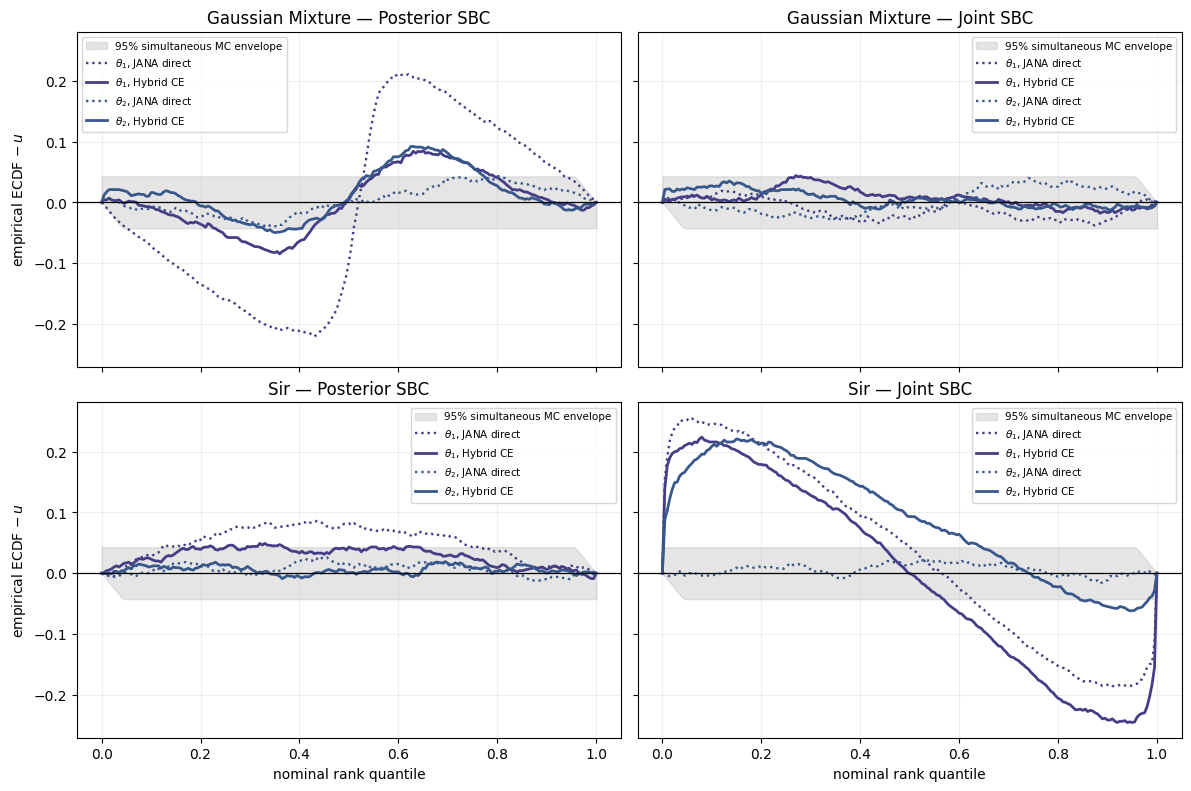

Standalone: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/paper_v11_10k_deep_ensembles_step_lr/plot_fig3_matched_jana_vs_hybrid_ce_sbc.py
Exported /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/paper_v11_10k_deep_ensembles_step_lr/fig3_training_pure_multiclass_ce.png and /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/paper_v11_10k_deep_ensembles_step_lr/fig3_training_pure_multiclass_ce.pdf


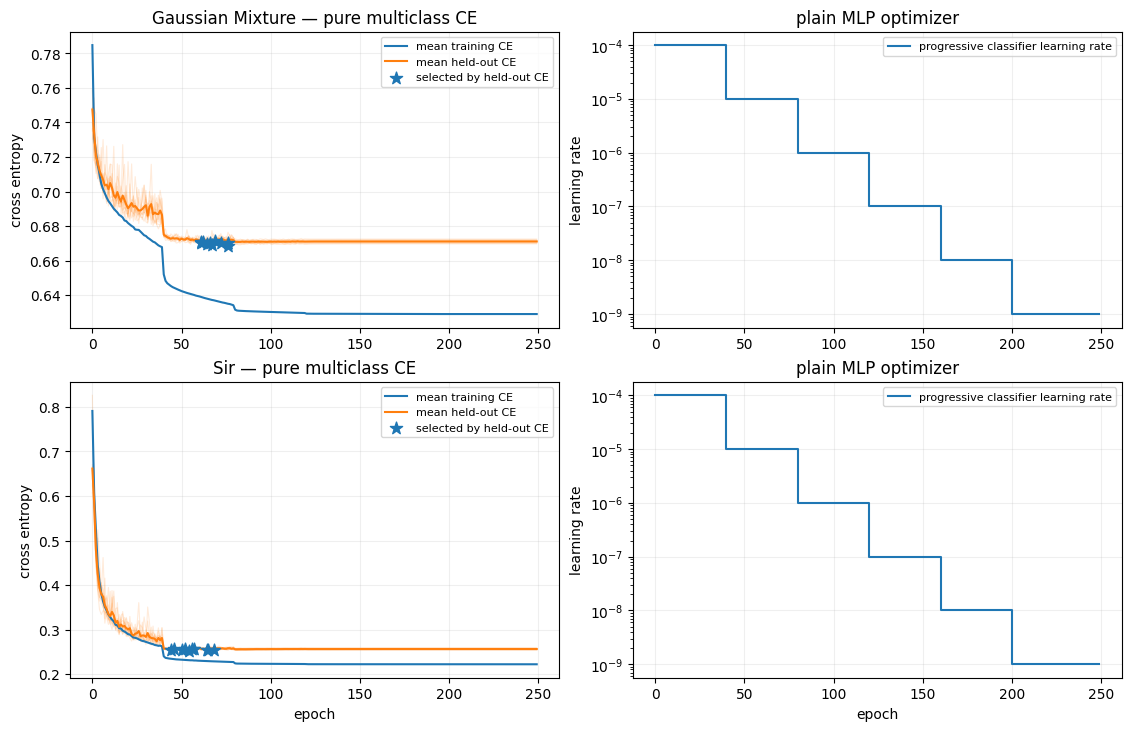

In [12]:
def plot_fig3_four_panel(results):
    fig, axes = plt.subplots(
        2, 2, figsize=(11.8, 7.8), sharex=True, sharey=True, constrained_layout=True
    )
    grid = np.linspace(0.0, 1.0, 201)
    colors = plt.cm.viridis(np.linspace(0.18, 0.82, 8))
    band_rows = []
    for row, task_name in enumerate(("gaussian_mixture", "sir")):
        result = results[task_name]
        names = (
            result["metrics"].query(
                "estimator == 'JANA direct' and diagnostic == 'posterior SBC'"
            )["parameter"].tolist()
        )
        n_ranks = len(result["jana_posterior_ranks"])
        critical = simultaneous_uniform_ecdf_critical(
            n_ranks, confidence=0.95, seed=SEED + 91_000 + row
        )
        lower_band, upper_band = simultaneous_difference_envelope(grid, critical)
        band_rows.append({
            "task": task_name, "n_ranks": n_ranks, "confidence": 0.95,
            "n_mc": SIMULTANEOUS_ECDF_MC, "seed": SEED + 91_000 + row,
            "ks_critical": critical,
        })
        for column, (diagnostic, title) in enumerate(
            (("posterior", "Posterior SBC"), ("joint", "Joint SBC"))
        ):
            ax = axes[row, column]
            ax.fill_between(
                grid, lower_band, upper_band, color="0.75", alpha=0.40,
                label="95% simultaneous MC envelope",
            )
            for index, name in enumerate(names):
                for estimator, prefix, linestyle, linewidth in [
                    ("JANA direct", "jana", ":", 1.7),
                    ("Hybrid CE", "hybrid", "-", 2.0),
                ]:
                    ranks = result[f"{prefix}_{diagnostic}_ranks"]
                    ecdf = (ranks[:, index, None] <= grid[None, :]).mean(axis=0)
                    label = f"{name}, {estimator}"
                    ax.plot(
                        grid, ecdf - grid, lw=linewidth, ls=linestyle,
                        color=colors[index], label=label,
                    )
            ax.axhline(0.0, color="black", lw=0.9)
            ax.set_title(f"{task_name.replace('_', ' ').title()} — {title}")
            ax.grid(alpha=0.2)
            if row == 1:
                ax.set_xlabel("nominal rank quantile")
            if column == 0:
                ax.set_ylabel(r"empirical ECDF $-\,u$")
            ax.legend(fontsize=7.5)
    return fig, pd.DataFrame(band_rows)


if RUN_FIG3:
    fig, fig3_band_table = plot_fig3_four_panel(FIG3_RESULTS)
    fig3_band_table.to_csv(OUTPUT_DIR / "fig3_simultaneous_ecdf_band.csv", index=False)
    export_figure(fig, "fig3_matched_jana_vs_hybrid_ce_sbc")
    plt.show()

    standalone = r'''#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path(__file__).resolve().parent
tasks = ("gaussian_mixture", "sir")
fig, axes = plt.subplots(2, 2, figsize=(11.8, 7.8), sharex=True, sharey=True, constrained_layout=True)
grid = np.linspace(0.0, 1.0, 201)
colors = plt.cm.viridis(np.linspace(0.18, 0.82, 8))
bands = pd.read_csv(root / "fig3_simultaneous_ecdf_band.csv").set_index("task")
for row, task in enumerate(tasks):
    d = np.load(root / f"fig3_{task}_ranks.npz", allow_pickle=False)
    names = d["parameter_names"].astype(str)
    critical = float(bands.loc[task, "ks_critical"])
    lower, upper = np.maximum(-grid, -critical), np.minimum(1-grid, critical)
    for col, (diagnostic, title) in enumerate((("posterior", "Posterior SBC"), ("joint", "Joint SBC"))):
        ax = axes[row, col]
        ax.fill_between(grid, lower, upper, color="0.75", alpha=.40, label="95% simultaneous MC envelope")
        for j, name in enumerate(names):
            for estimator, prefix, linestyle, linewidth in [
                ("JANA direct", "jana", ":", 1.7), ("Hybrid CE", "hybrid", "-", 2.0)
            ]:
                ranks = d[f"{prefix}_{diagnostic}_ranks"]
                ecdf = (ranks[:, j, None] <= grid[None, :]).mean(0)
                ax.plot(grid, ecdf-grid, lw=linewidth, ls=linestyle, color=colors[j],
                        label=f"{name}, {estimator}")
        ax.axhline(0, color="black", lw=.9)
        ax.set_title(f"{task.replace('_',' ').title()} — {title}")
        ax.grid(alpha=.2)
        if row == 1: ax.set_xlabel("nominal rank quantile")
        if col == 0: ax.set_ylabel(r"empirical ECDF $-\,u$")
        ax.legend(fontsize=7.5)
fig.savefig(root / "fig3_matched_jana_vs_hybrid_ce_sbc.pdf", bbox_inches="tight")
fig.savefig(root / "fig3_matched_jana_vs_hybrid_ce_sbc.png", dpi=220, bbox_inches="tight")
'''
    (OUTPUT_DIR / "plot_fig3_matched_jana_vs_hybrid_ce_sbc.py").write_text(standalone)
    print("Standalone:", OUTPUT_DIR / "plot_fig3_matched_jana_vs_hybrid_ce_sbc.py")


def plot_fig3_training_schedules(results):
    fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.2), constrained_layout=True)
    for row, task_name in enumerate(("gaussian_mixture", "sir")):
        history = pd.DataFrame(results[task_name]["history"])
        mean_history = history.groupby("epoch", as_index=False)[["training_ce", "ce", "learning_rate"]].mean()
        for _, member_history in history.groupby("member"):
            axes[row, 0].plot(member_history["epoch"], member_history["ce"], color="C1", alpha=0.15, lw=0.8)
        axes[row, 0].plot(mean_history["epoch"], mean_history["training_ce"], label="mean training CE")
        axes[row, 0].plot(mean_history["epoch"], mean_history["ce"], label="mean held-out CE")
        selected = history["checkpoint_selected"].astype(bool)
        axes[row, 0].scatter(
            history.loc[selected, "epoch"], history.loc[selected, "ce"],
            marker="*", s=85, zorder=5, label="selected by held-out CE",
        )
        axes[row, 0].set(
            title=f"{task_name.replace('_', ' ').title()} — pure multiclass CE",
            ylabel="cross entropy",
        )
        axes[row, 0].grid(alpha=0.2); axes[row, 0].legend(fontsize=8)
        axes[row, 1].step(
            mean_history["epoch"], mean_history["learning_rate"], where="post",
            label="progressive classifier learning rate",
        )
        axes[row, 1].set(title="plain MLP optimizer", ylabel="learning rate", yscale="log")
        axes[row, 1].grid(alpha=0.2); axes[row, 1].legend(fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("epoch")
    return fig


if RUN_FIG3:
    fig = plot_fig3_training_schedules(FIG3_RESULTS)
    export_figure(fig, "fig3_training_pure_multiclass_ce")
    plt.show()
    schedule_script = r"""#!/usr/bin/env python3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
root=Path(__file__).resolve().parent
fig,axes=plt.subplots(2,2,figsize=(11.2,7.2),constrained_layout=True)
for row,task in enumerate(("gaussian_mixture","sir")):
    h=pd.read_csv(root/f"fig3_{task}_training_history.csv")
    mean_h=h.groupby("epoch",as_index=False)[["training_ce","ce","learning_rate"]].mean()
    for _,member_h in h.groupby("member"): axes[row,0].plot(member_h.epoch,member_h.ce,color="C1",alpha=.15,lw=.8)
    axes[row,0].plot(mean_h.epoch,mean_h.training_ce,label="mean training CE")
    axes[row,0].plot(mean_h.epoch,mean_h.ce,label="mean held-out CE")
    selected=h.checkpoint_selected.astype(bool)
    axes[row,0].scatter(h.loc[selected,"epoch"],h.loc[selected,"ce"],marker="*",s=85,zorder=5,label="selected by held-out CE")
    axes[row,0].set(title=f"{task.replace('_',' ').title()} — pure multiclass CE",ylabel="cross entropy")
    axes[row,0].grid(alpha=.2); axes[row,0].legend(fontsize=8)
    axes[row,1].step(mean_h.epoch,mean_h.learning_rate,where="post",label="progressive classifier learning rate")
    axes[row,1].set(title="plain MLP optimizer",ylabel="learning rate",yscale="log")
    axes[row,1].grid(alpha=.2); axes[row,1].legend(fontsize=8)
for a in axes[-1]: a.set_xlabel("epoch")
fig.savefig(root/"fig3_training_pure_multiclass_ce.pdf",bbox_inches="tight")
fig.savefig(root/"fig3_training_pure_multiclass_ce.png",dpi=220,bbox_inches="tight")
"""
    (OUTPUT_DIR / "plot_fig3_training_pure_multiclass_ce.py").write_text(schedule_script)

### Reading the Figure 3 head-to-head

Each panel now overlays the matched-objective JANA direct control (dotted) and Hybrid CE (solid).  Parameter color is held fixed, both estimators use the same simulator bank and calibration truths, and randomized rank jitter is paired.  The CSVs additionally report paired Hybrid-minus-JANA changes in ECDF MAE, RMSE, and KS; negative values favor the CE correction.

This comparison answers the ML question cleanly: does a plain multiclass CE correction improve the same direct NPE/NLE pair?  It does not reproduce the historical TensorFlow checkpoint or its exact optimizer trajectory.  A paper statement of “better than JANA” still requires the `paper` profile, multiple independent training seeds, uncertainty across seeds, and disclosure of any proposal-ESS failures.  A favorable posterior SBC curve with a worse joint SBC curve indicates that the learned likelihood/posterior composition was degraded, not improved.

## Figure 6 campaign: a physical, eventwise DDM likelihood

JANA encoded response by the sign of reaction time and appended a Gaussian dummy coordinate because its coupling flow required at least two continuous dimensions.  Here we keep the physical mixed discrete--continuous factorization

\[
 p(y,t\mid\theta)=p(y\mid\theta)\,
 p(\log t\mid y,\theta)\,t^{-1},\qquad y\in\{0,1\},\ t>0.
\]

The response term is a Bernoulli network and the conditional log-time term is a scalar conditional rational-quadratic-spline flow.  Their Bernoulli and scalar-flow NLLs train the direct likelihood proposal $q_\eta$; they are not ratio losses.  This $q_\eta$ is deliberately **not** the original Exercise 9 vector likelihood architecture.  JANA Figure 6 has exchangeable mixed discrete/continuous events, and its ELPD/LOO comparison needs a normalized likelihood evaluated pointwise for each held-out event.  A continuous vector flow cannot assign Bernoulli mass without changing the statistical problem.  The posterior nevertheless remains one **joint four-dimensional** original-configuration flow $q_\phi(v,a,t_0,w\mid x)$; the four parameters are never factorized into scalar posterior flows.  In log-time coordinates the Jacobian is absent, while every reported physical log likelihood subtracts $\log t$.

The posterior context is a permutation-invariant DeepSet plus $\log N$.  Consequently, the generic single three-logit Figure 3 MLP is not used for DDM.  DDM instead has a plain two-logit softmax head for data-set-level $S/P$ and a plain two-logit softmax head for pointwise event-level $S/L$.  Both are uniform Linear--ReLU stacks with no dropout, weight decay, normalization layer, residual connection, input warping, or output bound.  Their softmax log-probability differences are combined into the data-set three-class logits $(a,0,a-c_{1:N})$.  The **sole optimized correction objective is the overall equal-prior three-class CE on those combined logits**: neither binary head receives a BCE, and there is no direct-$a$ loss, $-\log2$ baseline, preflight stage, normalization loss, or bridge loss.

Softmax probability quotients are used directly for importance weighting.  Log-softmax differences are used only where the combined data-set logits or a physical log likelihood, evidence, or bridge calculation mathematically requires them.  Each constructed $S/P/L$ row is checked at its source: the observed events and their frozen-encoder context stay paired in $S$ and $P$, while the generated $L$ events are encoded by that same frozen encoder before the row is returned.  After the CE checkpoint is frozen, an independent validation-only bank measures posterior and eventwise likelihood mass and a separate IID bank measures raw-bridge variance.  These are consistency checks only.

This exchangeable posterior/event factorization is the deliberate DDM-specific exception.  It is required by the mixed event measure and pointwise ELPD target; it does not alter the central requirement that the complete physical parameter vector is learned jointly by one posterior flow.  The uncorrected DDM route remains a matched direct control, not a historical JANA checkpoint reproduction.

In [13]:
JANA_REPOSITORY = "https://github.com/bayesflow-org/JANA-Paper.git"
JANA_COMMIT = "6cbbc94faf0aa85147986f7f9516d13a52551bd4"
JANA_OSF_PROJECT = "2nbk6"
JANA_SHARED_ROOT = Path(os.environ.get(
    "EX9A_JANA_SHARED_ROOT",
    "/content/drive/MyDrive/hybrid_nsbi_ml/shared_jana"
    if IN_COLAB and USE_GOOGLE_DRIVE else PERSIST_ROOT.parent / "shared_jana",
))
JANA_REPO_ROOT = Path(os.environ.get(
    "JANA_REPO_ROOT", JANA_SHARED_ROOT / f"JANA-Paper-{JANA_COMMIT[:12]}"
))
JANA_DATA_ROOT = Path(os.environ.get(
    "JANA_DATA_ROOT", JANA_SHARED_ROOT / "OSF-2nbk6" / "osfstorage"
))
JANA_OSF_CLONE_ROOT = JANA_DATA_ROOT.parent
JANA_OSF_COMPLETION_MANIFEST = JANA_OSF_CLONE_ROOT / "validated_bank.json"


def prepare_pinned_jana_checkout(repo_root=JANA_REPO_ROOT, allow_clone=False):
    repo_root = Path(repo_root)
    if not (repo_root / ".git").exists():
        if not allow_clone:
            raise FileNotFoundError(
                f"No JANA checkout at {repo_root}. Set JANA_REPO_ROOT or "
                "ALLOW_PINNED_GIT_CLONE=True. This never downloads OSF project 2nbk6."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            ["git", "clone", "--filter=blob:none", "--no-checkout", JANA_REPOSITORY, str(repo_root)],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(repo_root), "sparse-checkout", "set", "experiments/diffusion_model/assets"],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(repo_root), "checkout", "--detach", JANA_COMMIT],
            check=True,
        )
    actual = subprocess.check_output(
        ["git", "-C", str(repo_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if actual != JANA_COMMIT:
        raise RuntimeError(
            f"Expected JANA commit {JANA_COMMIT}, found {actual}. The notebook will not "
            "change an existing checkout automatically."
        )
    return repo_root


def locate_ddm_data_root():
    """Return the one authoritative pre-downloaded Drive directory."""
    data_root = Path(JANA_DATA_ROOT)
    if not data_root.is_dir():
        raise FileNotFoundError(
            f"Pre-downloaded JANA OSF directory not found: {data_root}. "
            "Expected MyDrive/hybrid_nsbi_ml/shared_jana/"
            "OSF-2nbk6/osfstorage."
        )
    return data_root


def feather_schema_names(path):
    """Read only an Arrow/Feather footer; no multi-GB column is materialized."""
    try:
        import pyarrow as pa
        import pyarrow.ipc as ipc
    except ImportError as exc:
        raise ImportError("DDM schema validation requires pyarrow.") from exc
    with pa.memory_map(str(path), "r") as source:
        return set(ipc.open_file(source).schema.names)


def inspect_ddm_inputs(require_complete=True):
    repo = prepare_pinned_jana_checkout(JANA_REPO_ROOT, ALLOW_PINNED_GIT_CLONE)
    data_root = locate_ddm_data_root()
    posterior_files = sorted(
        (data_root / "posterior" / "training" / "sim_data").glob("*.feather")
    )
    likelihood_files = sorted(
        (data_root / "likelihood" / "training" / "sim_data").glob("*.feather")
    )
    posterior_parameter_files = sorted(
        (data_root / "posterior" / "training" / "parameters").glob("*.feather")
    )
    likelihood_parameter_files = sorted(
        (data_root / "likelihood" / "training" / "parameters").glob("*.feather")
    )
    required_assets = [
        repo / "experiments" / "diffusion_model" / "assets" / "bmc_results_100.csv",
        repo / "experiments" / "diffusion_model" / "assets" / "evaluation" / "parameters" / "01.feather",
        repo / "experiments" / "diffusion_model" / "assets" / "evaluation" / "sim_data" / "01.feather",
        repo / "experiments" / "diffusion_model" / "assets" / "evaluation" / "analytic_likelihood" / "01.feather",
    ]
    missing = [str(path) for path in required_assets if not path.exists()]
    bank_files = (
        posterior_files + likelihood_files
        + posterior_parameter_files + likelihood_parameter_files
    )
    expected_posterior_names = {"01.feather"}
    expected_likelihood_names = {f"{index:02d}.feather" for index in range(1, 11)}
    observed_names = {
        "posterior_sim": {path.name for path in posterior_files},
        "posterior_parameters": {path.name for path in posterior_parameter_files},
        "likelihood_sim": {path.name for path in likelihood_files},
        "likelihood_parameters": {path.name for path in likelihood_parameter_files},
    }
    expected_names = {
        "posterior_sim": expected_posterior_names,
        "posterior_parameters": expected_posterior_names,
        "likelihood_sim": expected_likelihood_names,
        "likelihood_parameters": expected_likelihood_names,
    }
    shard_names_match = observed_names == expected_names
    nonempty = len(bank_files) == 22 and all(path.stat().st_size > 0 for path in bank_files)
    schema_errors = []
    for role, files, required_columns in [
        ("posterior_sim", posterior_files, {"cnd", "resp", "rt"}),
        ("likelihood_sim", likelihood_files, {"cnd", "resp", "rt"}),
        ("posterior_parameters", posterior_parameter_files, {"v", "a", "t0", "w"}),
        ("likelihood_parameters", likelihood_parameter_files, {"v", "a", "t0", "w"}),
    ]:
        for path in files:
            try:
                columns = feather_schema_names(path)
            except Exception as exc:
                schema_errors.append(f"{role}:{path.name}: unreadable schema ({exc})")
                continue
            missing_columns = sorted(required_columns - columns)
            if missing_columns:
                schema_errors.append(f"{role}:{path.name}: missing {missing_columns}")
    total_bytes = sum(path.stat().st_size for path in bank_files)
    complete = (
        not missing and shard_names_match and nonempty and not schema_errors
        and total_bytes >= 5_900_000_000
    )
    report = {
        "complete": complete,
        "repo": repo,
        "data_root": data_root,
        "posterior_files": posterior_files,
        "likelihood_files": likelihood_files,
        "posterior_parameter_files": posterior_parameter_files,
        "likelihood_parameter_files": likelihood_parameter_files,
        "total_bytes": total_bytes,
        "shard_names_match": shard_names_match,
        "observed_names": {key: sorted(value) for key, value in observed_names.items()},
        "schema_errors": schema_errors,
        "required_assets": required_assets,
        "missing_assets": missing,
    }
    if require_complete and not complete:
        raise FileNotFoundError(
            "The official DDM bank is incomplete. "
            f"Resolved data root={data_root}; "
            f"Assets missing={missing}; posterior shards={len(posterior_files)}; "
            f"likelihood shards={len(likelihood_files)}; parameter shards="
            f"{len(posterior_parameter_files)}/{len(likelihood_parameter_files)}; "
            f"bytes={total_bytes:,}; exact shard names={shard_names_match}. "
            f"Schema errors={schema_errors}. "
            "Check that Google Drive is mounted and that JANA_DATA_ROOT points to "
            "MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6/osfstorage."
        )
    return report


def prepare_jana_osf():
    """Validate the pre-downloaded Drive bank; never access OSF or the network."""
    report = inspect_ddm_inputs(require_complete=True)
    payload = {
        "project": JANA_OSF_PROJECT,
        "access_mode": JANA_OSF_ACCESS_MODE,
        "jana_commit": JANA_COMMIT,
        "data_root": str(report["data_root"]),
        "posterior_shards": len(report["posterior_files"]),
        "likelihood_shards": len(report["likelihood_files"]),
        "total_bytes": report["total_bytes"],
        "observed_names": report["observed_names"],
        "validated": True,
    }
    JANA_OSF_COMPLETION_MANIFEST.parent.mkdir(parents=True, exist_ok=True)
    JANA_OSF_COMPLETION_MANIFEST.write_text(json.dumps(payload, indent=2))
    print("Using pre-downloaded JANA OSF bank:", report["data_root"])
    return report


def require_ddm_inputs():
    report = prepare_jana_osf()
    if PROFILE == "paper" and (
        CFG["ddm_datasets"] is not None or CFG["ddm_event_cap"] is not None
    ):
        raise RuntimeError("The paper profile must not cap the official DDM banks.")
    return (
        report["repo"], report["posterior_files"],
        report["likelihood_files"], report["required_assets"],
    )


print("Persistent JANA checkout:", JANA_REPO_ROOT)
print("Pre-downloaded OSF project root:", JANA_OSF_CLONE_ROOT)
print("Authoritative OSF data root:", JANA_DATA_ROOT)
print("OSF access mode:", JANA_OSF_ACCESS_MODE)
print("The bank is validated when RUN_DDM=True; this notebook never downloads it.")

Persistent JANA checkout: /content/drive/MyDrive/hybrid_nsbi_ml/shared_jana/JANA-Paper-6cbbc94faf0a
Pre-downloaded OSF project root: /content/drive/MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6
Authoritative OSF data root: /content/drive/MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6/osfstorage
OSF access mode: pre_downloaded_drive_only
The bank is validated when RUN_DDM=True; this notebook never downloads it.


### Pre-downloaded Drive bank

The complete OSF project has already been downloaded to

```text
MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6/osfstorage
```

which Colab resolves as `/content/drive/MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6/osfstorage`. This is the notebook's single authoritative DDM data root. There is no `osfclient` dependency, download flag, clone command, recursive directory search, or network fallback.

When `RUN_DDM=True`, the notebook validates the exact official shard-name sets, non-empty files, at least 5.9 GB of bank data, and the expected Feather columns (`cnd`, `resp`, `rt` and `v`, `a`, `t0`, `w`) before training. Schema checks read Arrow footers only. A missing or incomplete bank produces a direct error naming the expected Drive directory; it never triggers a download. The tutorial likelihood bank is streamed from Arrow record batches with a real event cap. Only the uncapped `paper` profile is a full-bank comparison and requires a high-memory runtime.

In [14]:
DDM_PARAMETER_NAMES = ("v", "a", "t0", "w")
DDM_PRIOR_LOC = np.asarray([0.0, 1.0, 0.4, 0.5], dtype=np.float64)
DDM_PRIOR_SCALE = np.asarray([10.0, 1.0, 0.2, 0.1], dtype=np.float64)
DDM_PRIOR_LOW = np.asarray([-5.0, 0.5, 0.2, 0.3], dtype=np.float64)
DDM_PRIOR_HIGH = np.asarray([5.0, 3.0, 1.0, 0.7], dtype=np.float64)


class BoundedLogitTransform:
    def __init__(self, low, high, clip=1.0e-6):
        self.low = np.asarray(low, dtype=np.float64)
        self.high = np.asarray(high, dtype=np.float64)
        self.clip = float(clip)

    def forward(self, theta):
        theta = as_2d(theta, "theta").astype(np.float64)
        unit = np.clip((theta - self.low) / (self.high - self.low), self.clip, 1.0 - self.clip)
        return (np.log(unit) - np.log1p(-unit)).astype(np.float32)

    def inverse(self, latent):
        latent = as_2d(latent, "latent").astype(np.float64)
        unit = 1.0 / (1.0 + np.exp(-np.clip(latent, -80.0, 80.0)))
        return (self.low + (self.high - self.low) * unit).astype(np.float32)

    def log_abs_det_inverse(self, latent):
        latent = as_2d(latent, "latent").astype(np.float64)
        return np.sum(
            np.log(self.high - self.low)
            - np.logaddexp(0.0, -latent) - np.logaddexp(0.0, latent), axis=1
        )


DDM_TRANSFORM = BoundedLogitTransform(DDM_PRIOR_LOW, DDM_PRIOR_HIGH)


def ddm_prior_log_prob_latent(latent):
    latent = as_2d(latent, "latent")
    theta = DDM_TRANSFORM.inverse(latent).astype(np.float64)
    alpha = (DDM_PRIOR_LOW - DDM_PRIOR_LOC) / DDM_PRIOR_SCALE
    beta = (DDM_PRIOR_HIGH - DDM_PRIOR_LOC) / DDM_PRIOR_SCALE
    log_normalizer = np.log(np.maximum(ndtr(beta) - ndtr(alpha), 1.0e-300))
    standardized = (theta - DDM_PRIOR_LOC) / DDM_PRIOR_SCALE
    log_density = np.sum(
        -0.5 * standardized**2 - np.log(DDM_PRIOR_SCALE)
        - 0.5 * np.log(2.0 * np.pi) - log_normalizer,
        axis=1,
    )
    inside = np.all((theta >= DDM_PRIOR_LOW) & (theta <= DDM_PRIOR_HIGH), axis=1)
    return np.where(inside, log_density + DDM_TRANSFORM.log_abs_det_inverse(latent), -np.inf)


def _paired_parameter_file(simulation_file):
    parts = list(Path(simulation_file).parts)
    reverse_index = len(parts) - 1 - parts[::-1].index("sim_data")
    parts[reverse_index] = "parameters"
    return Path(*parts)


def _ddm_response_offset(observed, source):
    observed = {float(value) for value in observed}
    if not observed or not observed <= {0.0, 1.0, 2.0}:
        raise ValueError(f"{source}: invalid DDM response values {sorted(observed)}.")
    if 0.0 in observed and 2.0 in observed:
        raise ValueError(f"{source}: mixed 0/1 and 1/2 response encodings.")
    if 0.0 in observed:
        return 0.0
    if 2.0 in observed:
        return 1.0
    raise ValueError(
        f"{source}: only response value 1 was observed; 0/1 versus 1/2 "
        "encoding cannot be determined safely."
    )


def _detect_streamed_ddm_response_offset(dataset, batch_size, source):
    observed = set()
    scanner = dataset.scanner(
        columns=["resp"], batch_size=int(batch_size), use_threads=False
    )
    for record_batch in scanner.to_batches():
        values = np.asarray(
            record_batch.column(0).to_numpy(zero_copy_only=False), dtype=np.float32
        )
        observed.update(np.unique(values).tolist())
        if not observed <= {0.0, 1.0, 2.0} or 0.0 in observed or 2.0 in observed:
            return _ddm_response_offset(observed, source)
    return _ddm_response_offset(observed, source)


def load_ddm_feather(simulation_file, limit=None):
    simulation_file = Path(simulation_file)
    parameter_file = _paired_parameter_file(simulation_file)
    if not simulation_file.is_file() or not parameter_file.is_file():
        raise FileNotFoundError(
            f"Missing paired DDM Feather files: sim={simulation_file}, parameters={parameter_file}"
        )
    try:
        frame = pd.read_feather(simulation_file, columns=["cnd", "resp", "rt"])
        parameters = pd.read_feather(
            parameter_file, columns=list(DDM_PARAMETER_NAMES)
        )
    except ImportError as exc:
        raise ImportError("DDM feather files require pyarrow (`pip install pyarrow==10.0.1`).") from exc
    if len(parameters) == 0 or len(frame) == 0:
        raise ValueError(f"{simulation_file}: DDM Feather pair is empty.")
    theta = parameters.to_numpy(dtype=np.float32)
    if limit is not None:
        theta = theta[:int(limit)]
    n_sets = len(parameters)
    if len(frame) % n_sets:
        raise ValueError(f"{simulation_file} does not contain a fixed number of trials per parameter row.")
    n_trials = len(frame) // n_sets
    raw_all = frame.to_numpy().reshape(n_sets, n_trials, 3)
    response_offset = _ddm_response_offset(
        np.unique(raw_all[..., 1]).tolist(), str(simulation_file)
    )
    raw = raw_all[:len(theta)]
    response = raw[..., 1].astype(np.float32)
    response = response - response_offset
    rt = raw[..., 2].astype(np.float64)
    if np.any(rt <= 0.0):
        raise ValueError("Physical reaction times must be positive before log transformation.")
    events = np.stack([response, np.log(rt).astype(np.float32)], axis=-1)
    mask = np.ones(events.shape[:2], dtype=np.float32)
    return theta, events.astype(np.float32), mask


def load_ddm_set_bank(files, max_datasets, seed):
    files = [Path(path) for path in files]
    if not files:
        raise FileNotFoundError(
            "No posterior sim_data Feather shards were found. The OSF completeness "
            "gate should stop here; check the pre-downloaded JANA_DATA_ROOT."
        )
    print(f"Loading DDM posterior sets from {len(files)} validated shard(s); first={files[0]}")
    theta_parts, event_parts = [], []
    remaining = None if max_datasets is None else int(max_datasets)
    for path in files:
        if remaining == 0:
            break
        theta, events, _ = load_ddm_feather(path, limit=remaining)
        theta_parts.append(theta)
        event_parts.append(events)
        if remaining is not None:
            remaining -= len(theta)
    if not theta_parts:
        raise FileNotFoundError("Validated DDM posterior shards produced no training rows.")
    theta = np.concatenate(theta_parts)
    events = np.concatenate(event_parts)
    rng = np.random.default_rng(seed)
    selected_events, masks = [], []
    maximum = int(CFG["ddm_trials_max"])
    observed_trial_counts = []
    for row_index, row in enumerate(events):
        available = int(len(row))
        observed_trial_counts.append(available)
        minimum = int(CFG["ddm_trials_min"])
        if available < minimum:
            raise ValueError(
                f"DDM row {row_index} has {available} trials, below configured minimum {minimum}."
            )
        upper = min(int(CFG["ddm_trials_max"]), available)
        n = int(rng.integers(minimum, upper + 1))
        start = int(rng.integers(0, available - n + 1))
        selected = row[start:start + n]
        padded = np.zeros((maximum, 2), dtype=np.float32)
        mask = np.zeros(maximum, dtype=np.float32)
        padded[:n] = selected
        mask[:n] = 1.0
        selected_events.append(padded)
        masks.append(mask)
    print(
        "DDM source trials per row: "
        f"min={min(observed_trial_counts)}, max={max(observed_trial_counts)}; "
        f"sampled up to {min(int(CFG['ddm_trials_max']), max(observed_trial_counts))}."
    )
    return theta.astype(np.float32), np.stack(selected_events), np.stack(masks)


def _stream_ddm_event_file(simulation_file, event_limit, rng, batch_size=262_144):
    try:
        import pyarrow.dataset as ds
    except ImportError as exc:
        raise ImportError("Streaming DDM Feather files requires pyarrow.") from exc
    parameters = pd.read_feather(
        _paired_parameter_file(simulation_file), columns=list(DDM_PARAMETER_NAMES)
    ).to_numpy(dtype=np.float32)
    dataset = ds.dataset(str(simulation_file), format="ipc")
    n_rows = int(dataset.count_rows())
    if len(parameters) == 0 or n_rows % len(parameters):
        raise ValueError(f"{simulation_file} does not have fixed trials per parameter row.")
    n_trials = n_rows // len(parameters)
    inside = np.all((parameters >= DDM_PRIOR_LOW) & (parameters <= DDM_PRIOR_HIGH), axis=1)
    z_parameters = DDM_TRANSFORM.forward(parameters)
    response_offset = _detect_streamed_ddm_response_offset(
        dataset, batch_size, str(simulation_file)
    )
    z_parts, event_parts, offset, accepted = [], [], 0, 0
    stopped_for_limit = False
    scanner = dataset.scanner(
        columns=["resp", "rt"], batch_size=int(batch_size), use_threads=False
    )
    for record_batch in scanner.to_batches():
        rows = int(record_batch.num_rows)
        parameter_index = np.arange(offset, offset + rows, dtype=np.int64) // n_trials
        offset += rows
        keep = inside[parameter_index]
        if not np.any(keep):
            continue
        response = np.asarray(
            record_batch.column(0).to_numpy(zero_copy_only=False), dtype=np.float32
        )[keep]
        expected = {response_offset, response_offset + 1.0}
        observed = set(np.unique(response).tolist())
        if not observed <= expected:
            raise ValueError(
                f"{simulation_file}: response values {sorted(observed)} do not match "
                f"the file-level encoding {sorted(expected)}."
            )
        response = response - response_offset
        rt = np.asarray(record_batch.column(1).to_numpy(zero_copy_only=False), dtype=np.float64)[keep]
        if np.any(rt <= 0.0):
            raise ValueError("Physical reaction times must be positive before log transformation.")
        z_batch = z_parameters[parameter_index[keep]]
        events = np.column_stack([response, np.log(rt)]).astype(np.float32)
        if event_limit is not None:
            remaining = int(event_limit) - accepted
            if remaining <= 0:
                stopped_for_limit = True
                break
            if len(events) > remaining:
                chosen = rng.choice(len(events), size=remaining, replace=False)
                z_batch, events = z_batch[chosen], events[chosen]
        z_parts.append(z_batch.astype(np.float32))
        event_parts.append(events)
        accepted += len(events)
        if event_limit is not None and accepted >= int(event_limit):
            stopped_for_limit = offset < n_rows
            break
    if offset > n_rows:
        raise RuntimeError(f"{simulation_file}: Arrow scanner exceeded its declared row count.")
    if not stopped_for_limit and offset != n_rows:
        raise RuntimeError(
            f"{simulation_file}: Arrow scanner consumed {offset} of {n_rows} rows."
        )
    if not z_parts:
        return np.empty((0, 4), dtype=np.float32), np.empty((0, 2), dtype=np.float32)
    return np.concatenate(z_parts), np.concatenate(event_parts)


def load_ddm_event_bank(files, max_events, seed):
    rng = np.random.default_rng(seed)
    files = [Path(path) for path in files]
    if max_events is not None:
        files = [files[index] for index in rng.permutation(len(files))]
    z_parts, event_parts = [], []
    remaining = None if max_events is None else int(max_events)
    for position, path in enumerate(files):
        if remaining is not None and remaining <= 0:
            break
        files_left = len(files) - position
        target = None if remaining is None else int(math.ceil(remaining / files_left))
        z_batch, events = _stream_ddm_event_file(path, target, rng)
        if len(events):
            z_parts.append(z_batch); event_parts.append(events)
            if remaining is not None:
                remaining -= len(events)
    if not z_parts:
        raise FileNotFoundError("No DDM likelihood training events were loaded.")
    z = np.concatenate(z_parts)
    events = np.concatenate(event_parts)
    if max_events is not None and len(events) > int(max_events):
        raise RuntimeError("The streamed DDM event cap was exceeded.")
    print(f"Streamed {len(events):,} DDM likelihood events (cap={max_events}).")
    return z, events

In [15]:
class DeepSetEncoder(nn.Module):
    def __init__(self, event_mean, event_std, embedding_dim=64, width=192):
        super().__init__()
        self.register_buffer("event_mean", torch.as_tensor(event_mean, dtype=torch.float32))
        self.register_buffer("event_std", torch.as_tensor(event_std, dtype=torch.float32))
        self.phi = nn.Sequential(
            nn.Linear(2, width), nn.SiLU(), nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
        )
        self.rho = nn.Sequential(
            nn.Linear(2 * width + 1, width), nn.SiLU(),
            nn.Linear(width, embedding_dim), nn.SiLU(),
        )

    def forward(self, events, mask):
        scaled = (events - self.event_mean) / self.event_std
        hidden = self.phi(scaled)
        weight = mask[..., None]
        count = weight.sum(dim=1).clamp_min(1.0)
        mean = (hidden * weight).sum(dim=1) / count
        variance = ((hidden - mean[:, None, :]).square() * weight).sum(dim=1) / count
        return self.rho(torch.cat([mean, torch.sqrt(variance + 1.0e-6), torch.log(count)], dim=-1))


class SetRegressionModel(nn.Module):
    def __init__(self, encoder, embedding_dim, n_parameters):
        super().__init__()
        self.encoder = encoder
        self.regression = nn.Sequential(
            nn.Linear(embedding_dim, 256), nn.SiLU(), nn.Linear(256, n_parameters)
        )

    def forward(self, events, mask):
        return self.regression(self.encoder(events, mask))


def train_ddm_encoder(z, events, mask, seed):
    seed_everything(seed)
    valid = events[mask.astype(bool)]
    event_mean = valid.mean(axis=0)
    event_std = np.maximum(valid.std(axis=0), 1.0e-4)
    z_mean, z_std = z.mean(axis=0), np.maximum(z.std(axis=0), 1.0e-4)
    encoder = DeepSetEncoder(event_mean, event_std).to(DEVICE)
    model = SetRegressionModel(encoder, 64, z.shape[1]).to(DEVICE)
    checkpoint = MODEL_DIR / "ddm_set_encoder.pt"
    fingerprint = array_digest(z, events[:min(512, len(events))], mask[:min(512, len(mask))])
    if checkpoint.exists() and not FORCE_RETRAIN:
        saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
        if saved.get("fingerprint") != fingerprint:
            raise RuntimeError("Stale DDM set-encoder checkpoint; bump RUN_TAG or retrain.")
        model.load_state_dict(saved["state_dict"])
        return model.encoder.eval()
    dataset = TensorDataset(torch.as_tensor(events), torch.as_tensor(mask), torch.as_tensor(z))
    loader = DataLoader(dataset, batch_size=64 if PROFILE != "smoke" else 16, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    optimizer = torch.optim.Adam(model.parameters(), lr=5.0e-4)
    n_epochs = 2 if PROFILE == "smoke" else (30 if PROFILE == "tutorial" else 100)
    best, best_state = np.inf, None
    for epoch in range(n_epochs):
        model.train()
        total, count = 0.0, 0
        for batch_events, batch_mask, batch_z in loader:
            batch_events, batch_mask, batch_z = batch_events.to(DEVICE), batch_mask.to(DEVICE), batch_z.to(DEVICE)
            target = (batch_z - torch.as_tensor(z_mean, device=DEVICE)) / torch.as_tensor(z_std, device=DEVICE)
            prediction = model(batch_events, batch_mask)
            loss = F.mse_loss(prediction, target)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += float(loss) * len(batch_events)
            count += len(batch_events)
        mean_loss = total / count
        if mean_loss < best:
            best, best_state = mean_loss, copy.deepcopy(model.state_dict())
        if epoch in {0, n_epochs - 1}:
            print(f"DDM DeepSet epoch {epoch + 1}/{n_epochs}: regression MSE={mean_loss:.5f}")
    model.load_state_dict(best_state)
    torch.save({"state_dict": best_state, "fingerprint": fingerprint,
                "z_mean": z_mean, "z_std": z_std}, checkpoint)
    return model.encoder.eval()


def encode_ddm_sets(encoder, events, mask, batch_size=256):
    chunks = []
    encoder.eval()
    with torch.no_grad():
        for start in range(0, len(events), batch_size):
            chunks.append(encoder(
                torch.as_tensor(events[start:start + batch_size], device=DEVICE),
                torch.as_tensor(mask[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks).astype(np.float32)

In [16]:
class BernoulliResponseModel(nn.Module):
    """Plain Bernoulli base model; this is part of q_eta, not the CE correction."""

    def __init__(self, input_mean, input_std, width, hidden_layers):
        super().__init__()
        self.register_buffer("input_mean", torch.as_tensor(input_mean, dtype=torch.float32))
        self.register_buffer("input_std", torch.as_tensor(input_std, dtype=torch.float32))
        self.head = PlainMLP(len(input_mean), width, hidden_layers, 1)

    def forward(self, z):
        return self.head((z - self.input_mean) / self.input_std)[:, 0]


def train_ddm_response(z_events, events, seed):
    seed_everything(seed)
    model = BernoulliResponseModel(
        z_events.mean(axis=0), np.maximum(z_events.std(axis=0), 1.0e-4),
        CFG["class_width"], CFG["class_layers"],
    ).to(DEVICE)
    checkpoint = MODEL_DIR / "ddm_response_bernoulli.pt"
    fingerprint = array_digest(z_events, events[:, :1])
    configuration = {
        "architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "width": CFG["class_width"], "hidden_layers": CFG["class_layers"],
        "batch_size": CFG["flow_batch_size"], "epochs": CFG["flow_epochs"],
        "initial_learning_rate": INITIAL_LEARNING_RATE,
        "minimum_learning_rate": MINIMUM_LEARNING_RATE,
        "learning_rate_drop_factor": LEARNING_RATE_DROP_FACTOR,
        "learning_rate_step_epochs": LEARNING_RATE_STEP_EPOCHS,
        "regularization": "none",
    }
    if checkpoint.exists() and not FORCE_RETRAIN:
        saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
        if (
            saved.get("fingerprint") != fingerprint
            or saved.get("configuration") != configuration
        ):
            raise RuntimeError("Stale DDM response checkpoint; bump RUN_TAG or retrain.")
        model.load_state_dict(saved["state_dict"])
        return model.eval()
    dataset = TensorDataset(torch.as_tensor(z_events), torch.as_tensor(events[:, 0]))
    loader = DataLoader(dataset, batch_size=CFG["flow_batch_size"],
                        shuffle=True, generator=torch.Generator().manual_seed(seed))
    optimizer = torch.optim.Adam(model.parameters(), lr=INITIAL_LEARNING_RATE)
    n_epochs = int(CFG["flow_epochs"])
    best, best_state = np.inf, None
    for epoch in range(n_epochs):
        learning_rate = set_optimizer_learning_rate(optimizer, epoch)
        model.train()
        total, count = 0.0, 0
        for batch_z, response in loader:
            batch_z, response = batch_z.to(DEVICE), response.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(batch_z), response)
            optimizer.zero_grad(set_to_none=True); loss.backward()
            optimizer.step()
            total += float(loss) * len(batch_z); count += len(batch_z)
        mean_loss = total / count
        if mean_loss < best:
            best, best_state = mean_loss, copy.deepcopy(model.state_dict())
        if epoch == 0 or (epoch + 1) % LEARNING_RATE_STEP_EPOCHS == 0 or epoch + 1 == n_epochs:
            print(f"DDM response epoch {epoch + 1}/{n_epochs}: Bernoulli NLL={mean_loss:.5f}, lr={learning_rate:.1e}")
    model.load_state_dict(best_state)
    torch.save({
        "state_dict": best_state, "fingerprint": fingerprint,
        "configuration": configuration,
    }, checkpoint)
    return model.eval()


def ddm_response_log_prob(response_model, z, response, batch_size=65_536):
    z = as_2d(z, "z")
    response = np.asarray(response, dtype=np.float32).reshape(-1)
    chunks = []
    response_model.eval()
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            z_batch = torch.as_tensor(z[start:start + batch_size], device=DEVICE)
            y_batch = torch.as_tensor(response[start:start + batch_size], device=DEVICE)
            logits = response_model(z_batch)
            chunks.append(-F.binary_cross_entropy_with_logits(logits, y_batch, reduction="none").cpu().numpy())
    return np.concatenate(chunks)


def train_ddm_likelihood_base(z_events, events, seed):
    response_model = train_ddm_response(z_events, events, seed)
    rt_context = np.column_stack([z_events, events[:, 0]]).astype(np.float32)
    model_config, training_config = benchmark_flow_configs(1)
    q_log_rt = train_spline_flow_ensemble(
        events[:, 1:2], context=rt_context,
        checkpoint=MODEL_DIR / "ddm_q_log_rt.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=model_config,
        training_config=training_config, device=DEVICE, seed=seed + 1,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )
    return response_model, q_log_rt


def ddm_base_event_log_prob(response_model, q_log_rt, z, events):
    z, events = as_2d(z, "z"), as_2d(events, "events")
    context = np.column_stack([z, events[:, 0]])
    return (
        ddm_response_log_prob(response_model, z, events[:, 0])
        + spline_flow_ensemble_log_prob(q_log_rt, events[:, 1:2], context=context)
    )


def sample_ddm_base_events(response_model, q_log_rt, z, n_samples, seed):
    # This composite draw reserves the two-seed namespace [seed, seed + 1]:
    # Bernoulli responses use seed; conditional log-times use seed + 1.
    z = as_2d(z, "z")
    rng = np.random.default_rng(seed)
    response_model.eval()
    with torch.no_grad():
        logits = response_model(torch.as_tensor(z, device=DEVICE)).cpu().numpy()
    probability = 1.0 / (1.0 + np.exp(-np.clip(logits, -40.0, 40.0)))
    response = (rng.random((len(z), int(n_samples))) < probability[:, None]).astype(np.float32)
    repeated_z = np.repeat(z[:, None, :], int(n_samples), axis=1)
    context = np.concatenate([repeated_z, response[..., None]], axis=-1)
    log_rt = sample_spline_flow_ensemble(
        q_log_rt, 1, context=context.reshape(-1, context.shape[-1]), seed=seed + 1
    ).reshape(len(z), int(n_samples), 1)
    return np.concatenate([response[..., None], log_rt], axis=-1).astype(np.float32)

In [17]:
class DDMPlainThreeClass(nn.Module):
    """Plain softmax heads adapted only to DDM's set/event factorization."""

    def __init__(self, n_a_input, n_c_input, width, hidden_layers):
        super().__init__()
        self.a_head = PlainMLP(n_a_input, width, hidden_layers, 2)
        self.c_head = PlainMLP(n_c_input, width, hidden_layers, 2)

    @staticmethod
    def _log_ratio(logits):
        log_probability = F.log_softmax(logits.to(torch.float64), dim=-1)
        return log_probability[:, 0] - log_probability[:, 1]

    @staticmethod
    def _probability_ratio(logits):
        probability = F.softmax(logits.to(torch.float64), dim=-1)
        return probability[:, 0] / probability[:, 1].clamp_min(torch.finfo(torch.float64).tiny)

    def a_logits(self, z, context):
        return self.a_head(torch.cat([z, context], dim=-1))

    def event_c_logits(self, z, event):
        return self.c_head(torch.cat([z, event], dim=-1))

    def a_log_ratio(self, z, context):
        return self._log_ratio(self.a_logits(z, context))

    def a_probability_ratio(self, z, context):
        return self._probability_ratio(self.a_logits(z, context))

    def event_c_log_ratio(self, z, event):
        return self._log_ratio(self.event_c_logits(z, event))

    def event_c_probability_ratio(self, z, event):
        return self._probability_ratio(self.event_c_logits(z, event))

    def forward(self, z, context, events, mask):
        log_rp = self.a_log_ratio(z, context)
        batch, n_trials, _ = events.shape
        repeated_z = z[:, None, :].expand(-1, n_trials, -1)
        log_rl_event = self.event_c_log_ratio(
            repeated_z.reshape(batch * n_trials, -1),
            events.reshape(batch * n_trials, -1),
        ).reshape(batch, n_trials)
        log_rl = (log_rl_event * mask).sum(dim=1)
        logits = torch.stack([log_rp, torch.zeros_like(log_rp), log_rp - log_rl], dim=-1)
        return logits.to(z.dtype)


def ddm_a_probability_ratio_torch(model_or_models, z, context):
    values = [member.a_probability_ratio(z, context) for member in classifier_members(model_or_models)]
    scale = float(len(values))
    return torch.stack([value / scale for value in values], dim=0).sum(dim=0)


def ddm_a_ratio_torch(model_or_models, z, context):
    """Log of the arithmetic data-set S/P ratio ensemble."""
    value = ddm_a_probability_ratio_torch(model_or_models, z, context)
    return value.clamp_min(torch.finfo(torch.float64).tiny).log()


def ddm_event_c_probability_ratio_torch(model_or_models, z, event):
    values = [member.event_c_probability_ratio(z, event) for member in classifier_members(model_or_models)]
    scale = float(len(values))
    return torch.stack([value / scale for value in values], dim=0).sum(dim=0)


def ddm_event_c_ratio_torch(model_or_models, z, event):
    """Log of the arithmetic event S/L ratio ensemble."""
    value = ddm_event_c_probability_ratio_torch(model_or_models, z, event)
    return value.clamp_min(torch.finfo(torch.float64).tiny).log()


def ddm_logits_torch(model_or_models, z, context, events, mask):
    members = classifier_members(model_or_models)
    if len(members) == 1:
        return members[0](z, context, events, mask)
    probabilities = torch.stack([
        F.softmax(member(z, context, events, mask).to(torch.float64), dim=-1)
        for member in members
    ], dim=0).mean(dim=0)
    return probabilities.clamp_min(torch.finfo(torch.float64).tiny).log().to(z.dtype)


@dataclass
class DDMConsistencyBank:
    posterior_source_indices: np.ndarray
    likelihood_source_indices: np.ndarray
    posterior_z_a: np.ndarray
    posterior_z_b: np.ndarray
    posterior_context: np.ndarray
    likelihood_z: np.ndarray
    likelihood_events_a: np.ndarray
    likelihood_events_b: np.ndarray
    bridge_z: np.ndarray
    bridge_context: np.ndarray
    bridge_events: np.ndarray
    bridge_mask: np.ndarray
    bridge_log_base: np.ndarray
    n_contexts: int
    n_inner: int


def train_ddm_posterior_flow(z, contexts, seed):
    model_config, training_config = benchmark_flow_configs(z.shape[1])
    return train_spline_flow_ensemble(
        z, context=contexts, checkpoint=MODEL_DIR / "ddm_q_phi.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=model_config,
        training_config=training_config, device=DEVICE, seed=seed,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )


def _ddm_base_dataset_log_prob(response_model, q_log_rt, z, events, mask):
    z = as_2d(z, "z")
    events = np.asarray(events, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)
    if len(z) != len(events) or events.shape[:2] != mask.shape:
        raise ValueError("DDM z/events/mask rows do not align.")
    batch, n_trials, _ = events.shape
    repeated_z = np.repeat(z[:, None, :], n_trials, axis=1)
    valid = mask.astype(bool).reshape(-1)
    values = np.zeros(batch * n_trials, dtype=np.float64)
    values[valid] = ddm_base_event_log_prob(
        response_model, q_log_rt,
        repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid],
    )
    return values.reshape(batch, n_trials).sum(axis=1)


def _assert_ddm_group_value(name, observed, expected, *, exact=False):
    observed = np.asarray(observed)
    expected = np.asarray(expected)
    if observed.shape != expected.shape:
        raise RuntimeError(
            f"DDM S/P/L alignment failed for {name}: "
            f"shape {observed.shape} != {expected.shape}."
        )
    aligned = (
        np.array_equal(observed, expected)
        if exact else np.allclose(observed, expected, rtol=1.0e-5, atol=1.0e-6)
    )
    if not aligned:
        maximum_error = float(np.max(np.abs(observed.astype(np.float64) - expected)))
        raise RuntimeError(
            f"DDM S/P/L alignment failed for {name}; maximum error={maximum_error:.3e}."
        )


def assert_ddm_three_class_alignment(
    encoder, z_s, z_p, contexts_s, contexts_l, events_s, events_l, mask_s,
    z_groups, context_groups, events_groups, mask_groups,
):
    """Require each class row to retain its own coherent (z, x) pair."""
    n = len(z_s)
    if not (
        z_groups.shape[:2] == (n, 3)
        and context_groups.shape[:2] == (n, 3)
        and events_groups.shape[:2] == (n, 3)
        and mask_groups.shape[:2] == (n, 3)
    ):
        raise RuntimeError("DDM class arrays must all preserve the (group, S/P/L, ...) axes.")
    for name, values in (
        ("z groups", z_groups), ("context groups", context_groups),
        ("event groups", events_groups), ("mask groups", mask_groups),
    ):
        if not np.isfinite(values).all():
            raise RuntimeError(f"DDM S/P/L alignment failed: {name} contain non-finite values.")

    # Re-encoding the observed bank makes the frozen-encoder provenance test explicit.
    observed_contexts = encode_ddm_sets(encoder, events_s, mask_s)
    _assert_ddm_group_value("observed frozen-encoder context", contexts_s, observed_contexts)
    _assert_ddm_group_value("S parameters", z_groups[:, 0], z_s)
    _assert_ddm_group_value("P parameters", z_groups[:, 1], z_p)
    _assert_ddm_group_value("L parameters", z_groups[:, 2], z_s)
    _assert_ddm_group_value("S context", context_groups[:, 0], contexts_s)
    _assert_ddm_group_value("P context", context_groups[:, 1], contexts_s)
    _assert_ddm_group_value("L generated-event context", context_groups[:, 2], contexts_l)
    _assert_ddm_group_value("S events", events_groups[:, 0], events_s)
    _assert_ddm_group_value("P events", events_groups[:, 1], events_s)
    _assert_ddm_group_value("L generated events", events_groups[:, 2], events_l)
    for class_index, class_name in enumerate(("S", "P", "L")):
        _assert_ddm_group_value(
            f"{class_name} event mask", mask_groups[:, class_index], mask_s, exact=True
        )
    if np.any(events_groups[mask_groups == 0] != 0.0):
        raise RuntimeError("DDM S/P/L alignment failed: padded events must be exactly zero.")


def build_ddm_three_class_problem(
    z_s, contexts_s, events_s, mask_s, encoder, q_phi, response_model, q_log_rt, seed
):
    n, maximum, _ = events_s.shape
    z_p = sample_spline_flow_ensemble(q_phi, 1, context=contexts_s, seed=seed + 1).reshape(n, -1)
    z_l = z_s.copy()
    generated = sample_ddm_base_events(
        response_model, q_log_rt, z_l, maximum, seed + 10_000
    )
    events_l = generated.copy()
    events_l[mask_s == 0] = 0.0
    contexts_l = encode_ddm_sets(encoder, events_l, mask_s)
    z_groups = np.stack([z_s, z_p, z_l], axis=1).astype(np.float32)
    context_groups = np.stack([contexts_s, contexts_s, contexts_l], axis=1).astype(np.float32)
    events_groups = np.stack([events_s, events_s, events_l], axis=1).astype(np.float32)
    mask_groups = np.stack([mask_s, mask_s, mask_s], axis=1).astype(np.float32)
    assert_ddm_three_class_alignment(
        encoder, z_s, z_p, contexts_s, contexts_l, events_s, events_l, mask_s,
        z_groups, context_groups, events_groups, mask_groups,
    )
    return z_groups, context_groups, events_groups, mask_groups


def build_ddm_consistency_bank(
    z_s, contexts_s, events_s, mask_s, q_phi, response_model, q_log_rt,
    candidate_indices, seed,
):
    rng = np.random.default_rng(seed)
    candidate_indices = np.asarray(candidate_indices, dtype=np.int64)
    c = min(int(CFG["diagnostic_contexts"]), len(candidate_indices))
    k = int(CFG["diagnostic_inner"])
    selected = rng.choice(candidate_indices, size=c, replace=False)
    context, events, mask = contexts_s[selected], events_s[selected], mask_s[selected]

    z_a = sample_spline_flow_ensemble(
        q_phi, k, context=context, seed=seed + 1, allocation="balanced"
    )
    z_b = sample_spline_flow_ensemble(
        q_phi, k, context=context, seed=seed + 2, allocation="balanced"
    )
    z_bridge = sample_spline_flow_ensemble(
        q_phi, k, context=context, seed=seed + 3, allocation="iid"
    )
    if z_a.ndim == 2:
        z_a, z_b, z_bridge = z_a[None], z_b[None], z_bridge[None]

    likelihood_indices = rng.choice(candidate_indices, size=c, replace=False)
    z_likelihood = z_s[likelihood_indices]
    events_a = sample_ddm_base_events(response_model, q_log_rt, z_likelihood, k, seed + 10_000)
    events_b = sample_ddm_base_events(response_model, q_log_rt, z_likelihood, k, seed + 20_000)

    flat_z = z_bridge.reshape(c * k, -1)
    repeated_context = np.repeat(context[:, None, :], k, axis=1).reshape(c * k, -1)
    log_qp = spline_flow_ensemble_log_prob(q_phi, flat_z, context=repeated_context)
    repeated_events = np.repeat(events[:, None, :, :], k, axis=1).reshape(c * k, events.shape[1], 2)
    repeated_mask = np.repeat(mask[:, None, :], k, axis=1).reshape(c * k, mask.shape[1])
    log_ql = _ddm_base_dataset_log_prob(response_model, q_log_rt, flat_z, repeated_events, repeated_mask)
    bridge_log_base = (ddm_prior_log_prob_latent(flat_z) + log_ql - log_qp).reshape(c, k).astype(np.float32)
    return DDMConsistencyBank(
        posterior_source_indices=selected.astype(np.int64),
        likelihood_source_indices=likelihood_indices.astype(np.int64),
        posterior_z_a=z_a.astype(np.float32), posterior_z_b=z_b.astype(np.float32),
        posterior_context=context.astype(np.float32),
        likelihood_z=z_likelihood.astype(np.float32),
        likelihood_events_a=events_a.astype(np.float32),
        likelihood_events_b=events_b.astype(np.float32),
        bridge_z=z_bridge.astype(np.float32), bridge_context=context.astype(np.float32),
        bridge_events=events.astype(np.float32), bridge_mask=mask.astype(np.float32),
        bridge_log_base=bridge_log_base, n_contexts=c, n_inner=k,
    )


def ddm_consistency_statistics_torch(model, bank, context_indices):
    """Return held-out mass and raw-bridge statistics without changing the model."""
    index = np.asarray(context_indices, dtype=np.int64)
    z_a = torch.as_tensor(bank.posterior_z_a[index], device=DEVICE)
    z_b = torch.as_tensor(bank.posterior_z_b[index], device=DEVICE)
    context = torch.as_tensor(bank.posterior_context[index], device=DEVICE)
    b, k, d = z_a.shape
    context_repeat = context[:, None, :].expand(-1, k, -1)
    rp_a = ddm_a_probability_ratio_torch(
        model, z_a.reshape(b * k, d), context_repeat.reshape(b * k, -1)
    ).reshape(b, k)
    rp_b = ddm_a_probability_ratio_torch(
        model, z_b.reshape(b * k, d), context_repeat.reshape(b * k, -1)
    ).reshape(b, k)
    zpa, zpb = rp_a.mean(dim=1), rp_b.mean(dim=1)

    z_l = torch.as_tensor(bank.likelihood_z[index], device=DEVICE)
    event_a = torch.as_tensor(bank.likelihood_events_a[index], device=DEVICE)
    event_b = torch.as_tensor(bank.likelihood_events_b[index], device=DEVICE)
    z_l_repeat = z_l[:, None, :].expand(-1, k, -1)
    rl_a = ddm_event_c_probability_ratio_torch(
        model, z_l_repeat.reshape(b * k, -1), event_a.reshape(b * k, -1)
    ).reshape(b, k)
    rl_b = ddm_event_c_probability_ratio_torch(
        model, z_l_repeat.reshape(b * k, -1), event_b.reshape(b * k, -1)
    ).reshape(b, k)
    zla, zlb = rl_a.mean(dim=1), rl_b.mean(dim=1)

    z_bridge = torch.as_tensor(bank.bridge_z[index], device=DEVICE)
    bridge_context = torch.as_tensor(bank.bridge_context[index], device=DEVICE)
    bridge_context_repeat = bridge_context[:, None, :].expand(-1, k, -1)
    a_bridge = ddm_a_ratio_torch(
        model, z_bridge.reshape(b * k, d), bridge_context_repeat.reshape(b * k, -1)
    ).reshape(b, k)
    bridge_events = torch.as_tensor(bank.bridge_events[index], device=DEVICE)
    bridge_mask = torch.as_tensor(bank.bridge_mask[index], device=DEVICE)
    maximum = bridge_events.shape[1]
    events_expanded = bridge_events[:, None, :, :].expand(-1, k, -1, -1)
    mask_expanded = bridge_mask[:, None, :].expand(-1, k, -1)
    z_expanded = z_bridge[:, :, None, :].expand(-1, -1, maximum, -1)
    c = ddm_event_c_ratio_torch(
        model,
        z_expanded.reshape(b * k * maximum, -1),
        events_expanded.reshape(b * k * maximum, -1),
    ).reshape(b, k, maximum)
    c_dataset = (c * mask_expanded).sum(dim=-1)
    base = torch.as_tensor(bank.bridge_log_base[index], device=DEVICE)
    raw_log_bridge = base + c_dataset - a_bridge
    return (
        ((zpa - 1.0) * (zpb - 1.0)).mean(),
        ((zla - 1.0) * (zlb - 1.0)).mean(),
        raw_log_bridge.var(dim=1, unbiased=True).mean(),
    )

In [18]:
def evaluate_ddm_consistency_checks(model, bank):
    posterior_mass, likelihood_mass, bridge, count = 0.0, 0.0, 0.0, 0
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(bank.n_contexts):
            posterior_value, likelihood_value, bridge_value = ddm_consistency_statistics_torch(
                model, bank, np.asarray([start])
            )
            posterior_mass += float(posterior_value)
            likelihood_mass += float(likelihood_value)
            bridge += float(bridge_value)
            count += 1
    return {
        "posterior_cross_mass": posterior_mass / count,
        "likelihood_cross_mass": likelihood_mass / count,
        "raw_bridge_variance": bridge / count,
        "n_contexts": int(bank.n_contexts),
        "n_inner": int(bank.n_inner),
    }


def evaluate_ddm_classifier(model, arrays, group_indices):
    z_groups, context_groups, events_groups, mask_groups = arrays
    total_ce, count = 0.0, 0
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(group_indices), 32):
            selected = group_indices[start:start + 32]
            batch_z_groups = torch.as_tensor(z_groups[selected], device=DEVICE)
            batch_context_groups = torch.as_tensor(context_groups[selected], device=DEVICE)
            batch_event_groups = torch.as_tensor(events_groups[selected], device=DEVICE)
            batch_mask_groups = torch.as_tensor(mask_groups[selected], device=DEVICE)
            n_groups = len(selected)
            batch_z = batch_z_groups.reshape(n_groups * 3, -1)
            batch_context = batch_context_groups.reshape(n_groups * 3, -1)
            batch_events = batch_event_groups.reshape(n_groups * 3, batch_event_groups.shape[-2], 2)
            batch_mask = batch_mask_groups.reshape(n_groups * 3, batch_mask_groups.shape[-1])
            batch_labels = torch.arange(3, device=DEVICE).repeat(n_groups)
            logits = ddm_logits_torch(model, batch_z, batch_context, batch_events, batch_mask)
            total_ce += float(F.cross_entropy(logits, batch_labels, reduction="sum"))
            count += len(batch_labels)
    return total_ce / max(1, count)


def train_ddm_multiclass_classifier(
    arrays, fingerprint, training_index, validation_index, seed,
):
    """Train independent DDM-adapted members with pure multiclass CE."""
    z_groups, context_groups, events_groups, mask_groups = arrays
    if z_groups.ndim != 3 or z_groups.shape[1] != 3:
        raise ValueError("DDM classifier arrays must preserve (groups, 3, ...) axes.")
    training_index, validation_index = validate_group_partition(
        len(z_groups), training_index, validation_index, "DDM classifier"
    )
    dataset = TensorDataset(
        torch.as_tensor(z_groups[training_index]),
        torch.as_tensor(context_groups[training_index]),
        torch.as_tensor(events_groups[training_index]),
        torch.as_tensor(mask_groups[training_index]),
    )
    ddm_batch = max(1, CFG["classifier_batch_size"] // 3)
    base_configuration = {
        "width": CFG["class_width"], "hidden_layers": CFG["class_layers"],
        "architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "classifier_ensemble": CFG["classifier_ensemble"],
        "class_grouping": DDM_CLASS_GROUP_SCHEMA,
        "training_objective": TRAINING_OBJECTIVE_VERSION,
        "initial_learning_rate": INITIAL_LEARNING_RATE,
        "minimum_learning_rate": MINIMUM_LEARNING_RATE,
        "learning_rate_drop_factor": LEARNING_RATE_DROP_FACTOR,
        "learning_rate_step_epochs": LEARNING_RATE_STEP_EPOCHS,
        "batch_size_row_budget": CFG["classifier_batch_size"],
        "epochs": CFG["classifier_epochs"],
        "patience": CFG["training_patience"],
        "selection_metric": "heldout_multiclass_ce_only",
        "physical_likelihood": "bernoulli_response_times_scalar_conditional_logrt_rqs_v2",
        "classifier_factorization": "plain_dataset_S_P_and_event_S_L_softmax_heads_overall_three_class_ce_v2",
        "regularization": "none",
        "normalization_or_bridge_in_training": False,
    }

    models, all_history = [], []
    for member_index in range(int(CFG["classifier_ensemble"])):
        member_seed = int(seed + 2_000_000 * (member_index + 1))
        seed_everything(member_seed)
        model = DDMPlainThreeClass(
            z_groups.shape[-1] + context_groups.shape[-1],
            z_groups.shape[-1] + events_groups.shape[-1],
            CFG["class_width"], CFG["class_layers"],
        ).to(DEVICE)
        configuration = {**base_configuration, "member_index": member_index}
        print(
            f"DDM classifier member {member_index + 1}/{CFG['classifier_ensemble']}: "
            f"S/P parameters={parameter_count(model.a_head):,}; "
            f"event S/L parameters={parameter_count(model.c_head):,}"
        )
        checkpoint = MODEL_DIR / f"ddm_plain_multiclass_ce.member_{member_index:02d}.pt"
        if checkpoint.exists() and not FORCE_RETRAIN:
            saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
            if (
                saved.get("fingerprint") != fingerprint
                or saved.get("configuration") != configuration
                or int(saved.get("member_seed", -1)) != member_seed
            ):
                raise RuntimeError("Stale DDM CE checkpoint; bump RUN_TAG or retrain.")
            model.load_state_dict(saved["state_dict"])
            model.eval()
            models.append(model)
            all_history.extend(dict(row) for row in saved.get("history", []))
            continue

        loader = DataLoader(
            dataset, batch_size=ddm_batch, shuffle=True,
            generator=torch.Generator().manual_seed(member_seed + 100_000),
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=INITIAL_LEARNING_RATE)
        history, best, best_state, best_epoch = [], np.inf, None, None
        stale_epochs = 0
        for epoch in range(int(CFG["classifier_epochs"])):
            learning_rate = set_optimizer_learning_rate(optimizer, epoch)
            model.train()
            train_total, train_count = 0.0, 0
            for batch_z_groups, batch_context_groups, batch_event_groups, batch_mask_groups in loader:
                n_groups = len(batch_z_groups)
                batch_z = batch_z_groups.to(DEVICE).reshape(n_groups * 3, -1)
                batch_context = batch_context_groups.to(DEVICE).reshape(n_groups * 3, -1)
                batch_events = batch_event_groups.to(DEVICE).reshape(n_groups * 3, batch_event_groups.shape[-2], 2)
                batch_mask = batch_mask_groups.to(DEVICE).reshape(n_groups * 3, batch_mask_groups.shape[-1])
                batch_labels = torch.arange(3, device=DEVICE).repeat(n_groups)
                loss = F.cross_entropy(
                    ddm_logits_torch(model, batch_z, batch_context, batch_events, batch_mask),
                    batch_labels,
                )
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                train_total += float(loss.detach()) * len(batch_labels)
                train_count += len(batch_labels)
            validation_ce = evaluate_ddm_classifier(model, arrays, validation_index)
            row = {
                "member": member_index, "member_seed": member_seed, "epoch": epoch,
                "learning_rate": learning_rate,
                "training_ce": train_total / max(1, train_count),
                "ce": validation_ce, "objective": validation_ce,
                "checkpoint_selected": False,
                "selection_metric": "heldout_multiclass_ce_only",
            }
            history.append(row)
            if validation_ce < best - 1.0e-6:
                best = validation_ce
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = len(history) - 1
                stale_epochs = 0
            else:
                stale_epochs += 1
            if (
                epoch == 0 or (epoch + 1) % LEARNING_RATE_STEP_EPOCHS == 0
                or epoch + 1 == CFG["classifier_epochs"]
            ):
                print("DDM pure CE", row)
            if stale_epochs >= int(CFG["training_patience"]):
                print(f"DDM member {member_index}: CE early stopping after {epoch + 1} epochs")
                break
        if best_state is None or best_epoch is None:
            raise RuntimeError("No finite DDM multiclass-CE checkpoint was selected.")
        history[best_epoch]["checkpoint_selected"] = True
        model.load_state_dict(best_state)
        model.eval()
        torch.save({
            "state_dict": best_state, "history": history, "fingerprint": fingerprint,
            "configuration": configuration, "member_seed": member_seed,
        }, checkpoint)
        models.append(model)
        all_history.extend(history)
    return models, all_history


### Corrected DDM densities

For an event in log-time coordinates,

\[
 \log \widehat p(y,\ell\mid\theta)
 =\log q_B(y\mid\theta)+\log q_T(\ell\mid y,\theta)
  +\log r_L(\theta,y,\ell)-\log Z_L(\theta).
\]

The physical density adds $-\ell$.  Posterior correction uses $q_\phi(z\mid h(x))r_P/Z_P$.  For sampling, $r_P$ and $r_L$ are obtained directly as float64 quotients of softmax class probabilities and normalized without exponentiating network outputs.  Only the log-density path uses the equivalent log-softmax differences.

Evidence is evaluated with the bridge identity including both corrections,

\[
 \log m(x;z)=\log\rho(z)+\log q_\eta(x\mid z)-\log q_\phi(z\mid x)
 +\log r_L^{1:N}(z,x)-\log r_P(z,x)+\log Z_P(x)-N\log Z_L(z),
\]

and then subtracts $\sum_i\log t_i$ to return to the physical measure.  The distribution over posterior proposal draws exposes remaining bridge inconsistency.

All $Z_P$ and $Z_L$ factors are estimated **after pure-CE training** from fresh proposal samples.  They correct reconstructed densities but never alter classifier parameters.  The bridge spread is likewise a post-training consistency diagnostic, not a penalty.

In [19]:
def ddm_a_numpy(model, z, context, batch_size=65_536):
    z, context = as_2d(z, "z"), as_2d(context, "context")
    chunks = []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            chunks.append(ddm_a_ratio_torch(model,
                torch.as_tensor(z[start:start + batch_size], device=DEVICE),
                torch.as_tensor(context[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks)


def ddm_a_probability_numpy(model, z, context, batch_size=65_536):
    z, context = as_2d(z, "z"), as_2d(context, "context")
    chunks = []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            chunks.append(ddm_a_probability_ratio_torch(
                model,
                torch.as_tensor(z[start:start + batch_size], device=DEVICE),
                torch.as_tensor(context[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks)


def ddm_c_event_numpy(model, z, events, batch_size=65_536):
    z, events = as_2d(z, "z"), as_2d(events, "events")
    chunks = []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            chunks.append(ddm_event_c_ratio_torch(model,
                torch.as_tensor(z[start:start + batch_size], device=DEVICE),
                torch.as_tensor(events[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks)


def ddm_c_event_probability_numpy(model, z, events, batch_size=65_536):
    z, events = as_2d(z, "z"), as_2d(events, "events")
    chunks = []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            chunks.append(ddm_event_c_probability_ratio_torch(
                model,
                torch.as_tensor(z[start:start + batch_size], device=DEVICE),
                torch.as_tensor(events[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks)


def ddm_log_z_event(model, response_model, q_log_rt, z, n_candidates, seed):
    z = as_2d(z, "z")
    candidates = sample_ddm_base_events(response_model, q_log_rt, z, n_candidates, seed)
    repeated_z = np.repeat(z[:, None, :], n_candidates, axis=1)
    c = ddm_c_event_numpy(model, repeated_z.reshape(-1, z.shape[1]), candidates.reshape(-1, 2))
    return (logsumexp(c.reshape(len(z), n_candidates), axis=1) - math.log(n_candidates)).astype(np.float64)


def ddm_corrected_posterior(
    model, q_phi, encoder, events, mask, n_draws, n_candidates, seed
):
    context = encode_ddm_sets(encoder, events, mask)
    candidates = sample_spline_flow_ensemble(
        q_phi, n_candidates, context=context, seed=seed, allocation="iid"
    )
    if candidates.ndim == 2:
        candidates = candidates[None, :, :]
    rng = np.random.default_rng(seed + 900_000)
    output, ess, log_zp = [], [], []
    for h, candidate in zip(context, candidates):
        repeated_h = np.repeat(h[None, :], len(candidate), axis=0)
        ratio_p = ddm_a_probability_numpy(model, candidate, repeated_h)
        log_ratio_p = ddm_a_numpy(model, candidate, repeated_h)
        draw, value = importance_resample(candidate, ratio_p, n_draws, rng)
        output.append(draw); ess.append(value)
        log_zp.append(float(logsumexp(log_ratio_p) - math.log(len(log_ratio_p))))
    return np.stack(output), np.asarray(ess), np.asarray(log_zp), context


def ddm_corrected_likelihood_sets(
    model, response_model, q_log_rt, z, trial_counts, n_candidates, seed
):
    z = as_2d(z, "z")
    maximum = int(np.max(trial_counts))
    output = np.zeros((len(z), maximum, 2), dtype=np.float32)
    mask = np.zeros((len(z), maximum), dtype=np.float32)
    rng = np.random.default_rng(seed + 900_000)
    for index, (parameter, count) in enumerate(zip(z, trial_counts)):
        count = int(count)
        repeated_z = np.repeat(parameter[None, :], count, axis=0)
        candidates = sample_ddm_base_events(
            response_model, q_log_rt, repeated_z, n_candidates, seed + 10_000 + 100 * index
        )
        flat_z = np.repeat(repeated_z[:, None, :], n_candidates, axis=1)
        ratio_l = ddm_c_event_probability_numpy(
            model, flat_z.reshape(-1, z.shape[1]), candidates.reshape(-1, 2)
        ).reshape(count, n_candidates)
        for event_index in range(count):
            selected = rng.choice(
                n_candidates, p=normalize_probability_weights(ratio_l[event_index])
            )
            output[index, event_index] = candidates[event_index, selected]
        mask[index, :count] = 1.0
    return output, mask


def ddm_corrected_dataset_loglik(
    model, response_model, q_log_rt, z, events, mask,
    log_z_event=None, physical=True, z_event_candidates=512, seed=0,
):
    z = as_2d(z, "z")
    events = np.asarray(events, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)
    batch, n_trials, _ = events.shape
    repeated_z = np.repeat(z[:, None, :], n_trials, axis=1)
    valid = mask.astype(bool).reshape(-1)
    base = np.zeros(batch * n_trials, dtype=np.float64)
    correction = np.zeros(batch * n_trials, dtype=np.float64)
    base[valid] = ddm_base_event_log_prob(
        response_model, q_log_rt,
        repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid],
    )
    correction[valid] = ddm_c_event_numpy(
        model, repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid]
    )
    if log_z_event is None:
        log_z_event = ddm_log_z_event(
            model, response_model, q_log_rt, z, z_event_candidates, seed
        )
    value = (base + correction).reshape(batch, n_trials).sum(axis=1)
    value -= mask.sum(axis=1) * np.asarray(log_z_event)
    if physical:
        value -= (events[..., 1] * mask).sum(axis=1)
    return value


def ddm_jana_direct_posterior(q_phi, encoder, events, mask, n_draws, seed):
    """Direct q_phi draws: the matched-capacity JANA posterior."""
    context = encode_ddm_sets(encoder, events, mask)
    draws = sample_spline_flow_ensemble(
        q_phi, int(n_draws), context=context, seed=int(seed), allocation="iid"
    )
    draws = np.asarray(draws, dtype=np.float32)
    if draws.ndim == 2:
        draws = draws[None, :, :]
    if draws.shape[:2] != (len(context), int(n_draws)) or not np.isfinite(draws).all():
        raise RuntimeError(f"Unexpected matched-JANA DDM posterior shape {draws.shape}.")
    return draws, context


def ddm_jana_direct_likelihood_sets(
    response_model, q_log_rt, z, trial_counts, seed,
):
    """Draw event sets directly from the normalized JANA likelihood base."""
    z = as_2d(z, "z")
    maximum = int(np.max(trial_counts))
    output = np.zeros((len(z), maximum, 2), dtype=np.float32)
    mask = np.zeros((len(z), maximum), dtype=np.float32)
    for index, (parameter, count) in enumerate(zip(z, trial_counts)):
        count = int(count)
        repeated_z = np.repeat(parameter[None, :], count, axis=0)
        values = sample_ddm_base_events(
            response_model, q_log_rt, repeated_z, 1, seed + 10_000 + 100 * index
        )
        output[index, :count] = np.asarray(values)[:, 0, :]
        mask[index, :count] = 1.0
    return output, mask


def ddm_jana_direct_dataset_loglik(
    response_model, q_log_rt, z, events, mask, physical=True,
):
    """Normalized direct-JANA event likelihood for a padded set."""
    z = as_2d(z, "z")
    events = np.asarray(events, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)
    batch, n_trials, _ = events.shape
    repeated_z = np.repeat(z[:, None, :], n_trials, axis=1)
    valid = mask.astype(bool).reshape(-1)
    base = np.zeros(batch * n_trials, dtype=np.float64)
    base[valid] = ddm_base_event_log_prob(
        response_model, q_log_rt,
        repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid],
    )
    value = base.reshape(batch, n_trials).sum(axis=1)
    if physical:
        value -= (events[..., 1] * mask).sum(axis=1)
    return value

In [20]:
def ddm_evidence_samples(
    model, q_phi, response_model, q_log_rt, encoder, events, mask,
    n_candidates, seed, inner_z_candidates,
):
    context = encode_ddm_sets(encoder, events, mask)
    # Keep the IID outer bridge draws independent of the IID pool used
    # to estimate posterior mass.  The plotted quantiles are a bridge-spread
    # diagnostic across the IID outer pool, never a confidence interval.
    z = sample_spline_flow_ensemble(
        q_phi, n_candidates, context=context, seed=seed, allocation="iid"
    )
    z_normalization = sample_spline_flow_ensemble(
        q_phi, n_candidates, context=context, seed=seed + 10_000_000,
        allocation="iid",
    )
    if z.ndim == 2:
        z = z[None, :, :]
        z_normalization = z_normalization[None, :, :]
    all_samples = []
    rows = zip(z, z_normalization, context, events, mask)
    for index, (candidate, normalization_candidate, h, event_set, event_mask) in enumerate(rows):
        repeated_h = np.repeat(h[None, :], len(candidate), axis=0)
        a = ddm_a_numpy(model, candidate, repeated_h)
        normalization_h = np.repeat(h[None, :], len(normalization_candidate), axis=0)
        normalization_a = ddm_a_numpy(model, normalization_candidate, normalization_h)
        log_zp = logsumexp(normalization_a) - math.log(len(normalization_a))
        log_qp = spline_flow_ensemble_log_prob(
            q_phi, candidate, context=repeated_h
        )
        repeated_events = np.repeat(event_set[None, :, :], len(candidate), axis=0)
        repeated_mask = np.repeat(event_mask[None, :], len(candidate), axis=0)
        log_likelihood_transformed = ddm_corrected_dataset_loglik(
            model, response_model, q_log_rt, candidate,
            repeated_events, repeated_mask, physical=False,
            z_event_candidates=int(inner_z_candidates),
            seed=seed + 20_000_000 + 100 * index,
        )
        log_m_transformed = (
            ddm_prior_log_prob_latent(candidate) + log_likelihood_transformed
            - log_qp - a + log_zp
        )
        physical_jacobian = float(np.sum(event_set[:, 1] * event_mask))
        all_samples.append(log_m_transformed - physical_jacobian)
    return np.stack(all_samples)


def ddm_loo_one_dataset(
    model, q_phi, response_model, q_log_rt, encoder, events, mask,
    posterior_draws, posterior_candidates, seed,
):
    n = int(mask.sum())
    elpd = 0.0
    for left_out in range(n):
        keep = np.ones(n, dtype=bool); keep[left_out] = False
        reduced_events = np.zeros_like(events)
        reduced_mask = np.zeros_like(mask)
        reduced_events[:n - 1] = events[:n][keep]
        reduced_mask[:n - 1] = 1.0
        z_draws, _, _, _ = ddm_corrected_posterior(
            model, q_phi, encoder, reduced_events[None], reduced_mask[None],
            posterior_draws, posterior_candidates, seed + 101 * left_out,
        )
        z_draws = z_draws[0]
        event = np.repeat(events[left_out:left_out + 1], len(z_draws), axis=0)
        log_z = ddm_log_z_event(
            model, response_model, q_log_rt, z_draws,
            128 if PROFILE != "smoke" else 16, seed + 5_000_000 + 100 * left_out,
        )
        log_probability = (
            ddm_base_event_log_prob(response_model, q_log_rt, z_draws, event)
            + ddm_c_event_numpy(model, z_draws, event) - log_z - event[:, 1]
        )
        elpd += float(logsumexp(log_probability) - math.log(len(log_probability)))
    return elpd



def ddm_jana_direct_evidence_samples(
    q_phi, response_model, q_log_rt, encoder, events, mask, n_candidates, seed,
):
    """Evaluate the direct JANA evidence identity along IID q_phi draws."""
    context = encode_ddm_sets(encoder, events, mask)
    z = sample_spline_flow_ensemble(
        q_phi, int(n_candidates), context=context, seed=int(seed), allocation="iid"
    )
    z = np.asarray(z, dtype=np.float32)
    if z.ndim == 2:
        z = z[None, :, :]
    rows = []
    for candidate, h, event_set, event_mask in zip(z, context, events, mask):
        repeated_h = np.repeat(h[None, :], len(candidate), axis=0)
        log_qp = spline_flow_ensemble_log_prob(q_phi, candidate, context=repeated_h)
        repeated_events = np.repeat(event_set[None, :, :], len(candidate), axis=0)
        repeated_mask = np.repeat(event_mask[None, :], len(candidate), axis=0)
        log_likelihood_transformed = ddm_jana_direct_dataset_loglik(
            response_model, q_log_rt, candidate, repeated_events, repeated_mask,
            physical=False,
        )
        physical_jacobian = float(np.sum(event_set[:, 1] * event_mask))
        rows.append(
            ddm_prior_log_prob_latent(candidate)
            + log_likelihood_transformed - log_qp - physical_jacobian
        )
    return np.stack(rows)


def ddm_jana_direct_loo_one_dataset(
    q_phi, response_model, q_log_rt, encoder, events, mask,
    posterior_draws, seed,
):
    n = int(mask.sum())
    elpd = 0.0
    for left_out in range(n):
        keep = np.ones(n, dtype=bool)
        keep[left_out] = False
        reduced_events = np.zeros_like(events)
        reduced_mask = np.zeros_like(mask)
        reduced_events[:n - 1] = events[:n][keep]
        reduced_mask[:n - 1] = 1.0
        z_draws, _ = ddm_jana_direct_posterior(
            q_phi, encoder, reduced_events[None], reduced_mask[None],
            posterior_draws, seed + 101 * left_out,
        )
        z_draws = z_draws[0]
        event = np.repeat(events[left_out:left_out + 1], len(z_draws), axis=0)
        log_probability = (
            ddm_base_event_log_prob(response_model, q_log_rt, z_draws, event)
            - event[:, 1]
        )
        elpd += float(logsumexp(log_probability) - math.log(len(log_probability)))
    return elpd


def evaluate_ddm_truth_likelihood(
    model, response_model, q_log_rt, analytic_file, parameter_file, seed
):
    analytic = pd.read_feather(analytic_file)
    parameters = pd.read_feather(parameter_file)
    rows, curve = [], None
    for offset, identifier in enumerate(sorted(analytic["id"].unique())):
        reference = analytic.loc[analytic["id"] == identifier].copy()
        parameter_row = parameters.loc[
            parameters["id"] == identifier, list(DDM_PARAMETER_NAMES)
        ]
        if len(parameter_row) != 1:
            raise ValueError(f"Expected one parameter row for DDM id={identifier}.")
        theta = parameter_row.to_numpy(dtype=np.float32)
        z_single = DDM_TRANSFORM.forward(theta)
        signed_rt = reference["rt"].to_numpy(dtype=np.float64)
        valid_rt = np.abs(signed_rt) > 1.0e-8
        response = (signed_rt[valid_rt] > 0.0).astype(np.float32)
        log_rt = np.log(np.abs(signed_rt[valid_rt])).astype(np.float32)
        event = np.column_stack([response, log_rt]).astype(np.float32)
        z = np.repeat(z_single, len(event), axis=0)
        direct = ddm_base_event_log_prob(response_model, q_log_rt, z, event) - log_rt
        log_z = float(ddm_log_z_event(
            model, response_model, q_log_rt, z_single,
            2048 if PROFILE == "paper" else (512 if PROFILE == "tutorial" else 32),
            seed + 100 * offset,
        )[0])
        hybrid = (
            ddm_base_event_log_prob(response_model, q_log_rt, z, event)
            + ddm_c_event_numpy(model, z, event) - log_z - log_rt
        )
        truth = reference.loc[valid_rt, "lpdf"].to_numpy(dtype=np.float64)
        for estimator, learned in (("JANA direct", direct), ("Hybrid CE", hybrid)):
            finite = np.isfinite(truth) & np.isfinite(learned)
            metric = regression_metrics(
                truth[finite], learned[finite], f"analytic likelihood id={identifier}"
            )
            metric["estimator"] = estimator
            metric["id"] = int(identifier)
            rows.append(metric)
        if curve is None:
            curve = {
                "signed_rt": signed_rt[valid_rt], "truth_logpdf": truth,
                "jana_logpdf": direct, "hybrid_logpdf": hybrid,
                "id": int(identifier), "theta": theta[0],
            }
    return pd.DataFrame(rows), curve


def load_ddm_evaluation(assets_root, n_datasets):
    simulation_file = assets_root / "evaluation" / "sim_data" / "01.feather"
    theta, events_full, _ = load_ddm_feather(simulation_file, limit=n_datasets)
    n_trials = 100
    if events_full.shape[1] < n_trials:
        raise ValueError("Official DDM evaluation bank has fewer than 100 trials per set.")
    maximum = int(CFG["ddm_trials_max"])
    if maximum < n_trials:
        maximum = n_trials
    events = np.zeros((len(theta), maximum, 2), dtype=np.float32)
    mask = np.zeros((len(theta), maximum), dtype=np.float32)
    events[:, :n_trials] = events_full[:, :n_trials]
    mask[:, :n_trials] = 1.0
    return theta, events, mask

In [21]:
def run_ddm_campaign():
    repo, posterior_files, likelihood_files, required_assets = require_ddm_inputs()
    assets_root = repo / "experiments" / "diffusion_model" / "assets"
    print(
        f"DDM profile={PROFILE}: posterior cap={CFG['ddm_datasets']}, "
        f"event cap={CFG['ddm_event_cap']}."
    )
    theta_s, events_s, mask_s = load_ddm_set_bank(
        posterior_files, CFG["ddm_datasets"], SEED + 60_000
    )
    z_s = DDM_TRANSFORM.forward(theta_s)
    encoder = train_ddm_encoder(z_s, events_s, mask_s, SEED + 61_000)
    contexts_s = encode_ddm_sets(encoder, events_s, mask_s)
    q_phi = train_ddm_posterior_flow(z_s, contexts_s, SEED + 62_000)

    z_events, events_flat = load_ddm_event_bank(
        likelihood_files, CFG["ddm_event_cap"], SEED + 63_000
    )
    response_model, q_log_rt = train_ddm_likelihood_base(
        z_events, events_flat, SEED + 64_000
    )
    del z_events, events_flat

    n = len(z_s)
    training_index, validation_index = split_group_indices(
        n, 0.15, SEED + 67_000, "DDM classifier"
    )
    z_groups, context_groups, events_groups, mask_groups = build_ddm_three_class_problem(
        z_s, contexts_s, events_s, mask_s, encoder, q_phi, response_model, q_log_rt,
        SEED + 65_000,
    )
    fingerprint = array_digest(
        z_groups, context_groups, events_groups[:min(512, n)], mask_groups[:min(512, n)],
        training_index, validation_index,
    )
    model, history = train_ddm_multiclass_classifier(
        (z_groups, context_groups, events_groups, mask_groups), fingerprint,
        training_index, validation_index, SEED + 67_000,
    )
    validation_consistency = build_ddm_consistency_bank(
        z_s, contexts_s, events_s, mask_s, q_phi, response_model, q_log_rt,
        validation_index, SEED + 166_000,
    )
    validation_sources = np.concatenate([
        validation_consistency.posterior_source_indices,
        validation_consistency.likelihood_source_indices,
    ])
    if not np.all(np.isin(validation_sources, validation_index)):
        raise RuntimeError("DDM consistency diagnostics escaped the classifier validation split.")
    consistency = pd.DataFrame([{
        "split": "heldout_classifier_validation",
        "role": "post_training_consistency_check_only",
        **evaluate_ddm_consistency_checks(model, validation_consistency),
    }])
    consistency.to_csv(OUTPUT_DIR / "ddm_post_training_consistency.csv", index=False)

    pd.DataFrame(history).to_csv(OUTPUT_DIR / "ddm_training_history.csv", index=False)
    history_frame = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.1), constrained_layout=True)
    mean_history = history_frame.groupby("epoch", as_index=False)[["training_ce", "ce", "learning_rate"]].mean()
    for _, member_history in history_frame.groupby("member"):
        axes[0].plot(member_history["epoch"], member_history["ce"], color="C1", alpha=0.15, lw=0.8)
    axes[0].plot(mean_history["epoch"], mean_history["training_ce"], label="mean training CE")
    axes[0].plot(mean_history["epoch"], mean_history["ce"], label="mean held-out CE")
    selected = history_frame["checkpoint_selected"].astype(bool)
    axes[0].scatter(
        history_frame.loc[selected, "epoch"], history_frame.loc[selected, "ce"],
        marker="*", s=80, zorder=5, label="selected by held-out CE",
    )
    axes[1].step(
        mean_history["epoch"], mean_history["learning_rate"], where="post",
        label="progressive classifier learning rate",
    )
    for axis in axes:
        axis.set_xlabel("epoch"); axis.grid(alpha=0.2); axis.legend(fontsize=8)
    axes[0].set_ylabel("cross entropy")
    axes[1].set_ylabel("learning rate"); axes[1].set_yscale("log")
    axes[0].set_title("DDM plain MLP — pure multiclass CE")
    axes[1].set_title("plain MLP optimizer")
    export_figure(fig, "fig6_ddm_training_pure_multiclass_ce"); plt.show()
    ddm_schedule_script = r"""#!/usr/bin/env python3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
root=Path(__file__).resolve().parent; h=pd.read_csv(root/"ddm_training_history.csv")
fig,ax=plt.subplots(1,2,figsize=(10.8,4.1),constrained_layout=True)
mean_h=h.groupby("epoch",as_index=False)[["training_ce","ce","learning_rate"]].mean()
for _,member_h in h.groupby("member"): ax[0].plot(member_h.epoch,member_h.ce,color="C1",alpha=.15,lw=.8)
ax[0].plot(mean_h.epoch,mean_h.training_ce,label="mean training CE"); ax[0].plot(mean_h.epoch,mean_h.ce,label="mean held-out CE")
selected=h.checkpoint_selected.astype(bool)
ax[0].scatter(h.loc[selected,"epoch"],h.loc[selected,"ce"],marker="*",s=80,zorder=5,label="selected by held-out CE")
ax[1].step(mean_h.epoch,mean_h.learning_rate,where="post",label="progressive classifier learning rate")
for a in ax: a.set_xlabel("epoch"); a.grid(alpha=.2); a.legend(fontsize=8)
ax[0].set_ylabel("cross entropy"); ax[1].set_ylabel("learning rate"); ax[1].set_yscale("log")
ax[0].set_title("DDM plain MLP — pure multiclass CE"); ax[1].set_title("plain MLP optimizer")
fig.savefig(root/"fig6_ddm_training_pure_multiclass_ce.pdf",bbox_inches="tight")
fig.savefig(root/"fig6_ddm_training_pure_multiclass_ce.png",dpi=220,bbox_inches="tight")
"""
    (OUTPUT_DIR / "plot_fig6_ddm_training_pure_multiclass_ce.py").write_text(ddm_schedule_script)


    n_evaluation = int(CFG["ddm_eval_datasets"])
    theta_eval, events_eval, mask_eval = load_ddm_evaluation(assets_root, n_evaluation)
    z_eval = DDM_TRANSFORM.forward(theta_eval)
    trial_counts = mask_eval.sum(axis=1).astype(int)

    # Direct JANA and Hybrid CE use the same held-out truths and paired rank jitter.
    jana_posterior_z, _ = ddm_jana_direct_posterior(
        q_phi, encoder, events_eval, mask_eval, CFG["rank_draws"], SEED + 68_000
    )
    jana_posterior_ranks = rank_fraction(jana_posterior_z, z_eval, SEED + 68_500)
    jana_surrogate_events, jana_surrogate_mask = ddm_jana_direct_likelihood_sets(
        response_model, q_log_rt, z_eval, trial_counts, SEED + 69_000
    )
    jana_joint_z, _ = ddm_jana_direct_posterior(
        q_phi, encoder, jana_surrogate_events, jana_surrogate_mask,
        CFG["rank_draws"], SEED + 70_000,
    )
    jana_joint_ranks = rank_fraction(jana_joint_z, z_eval, SEED + 70_500)

    hybrid_posterior_z, hybrid_posterior_ess, _, _ = ddm_corrected_posterior(
        model, q_phi, encoder, events_eval, mask_eval, CFG["rank_draws"],
        CFG["posterior_candidates"], SEED + 68_000,
    )
    hybrid_posterior_ranks = rank_fraction(
        hybrid_posterior_z, z_eval, SEED + 68_500
    )
    hybrid_surrogate_events, hybrid_surrogate_mask = ddm_corrected_likelihood_sets(
        model, response_model, q_log_rt, z_eval, trial_counts,
        CFG["likelihood_candidates"], SEED + 69_000,
    )
    hybrid_joint_z, hybrid_joint_ess, _, _ = ddm_corrected_posterior(
        model, q_phi, encoder, hybrid_surrogate_events, hybrid_surrogate_mask,
        CFG["rank_draws"], CFG["posterior_candidates"], SEED + 70_000,
    )
    hybrid_joint_ranks = rank_fraction(hybrid_joint_z, z_eval, SEED + 70_500)

    calibration = pd.concat([
        labeled_calibration_metrics(
            jana_posterior_ranks, "JANA direct", "posterior SBC", DDM_PARAMETER_NAMES
        ),
        labeled_calibration_metrics(
            jana_joint_ranks, "JANA direct", "joint SBC", DDM_PARAMETER_NAMES
        ),
        labeled_calibration_metrics(
            hybrid_posterior_ranks, "Hybrid CE", "posterior SBC", DDM_PARAMETER_NAMES
        ),
        labeled_calibration_metrics(
            hybrid_joint_ranks, "Hybrid CE", "joint SBC", DDM_PARAMETER_NAMES
        ),
    ], ignore_index=True)
    calibration["median_candidate_ESS"] = np.nan
    calibration.loc[
        (calibration["estimator"] == "Hybrid CE")
        & (calibration["diagnostic"] == "posterior SBC"),
        "median_candidate_ESS",
    ] = float(np.median(hybrid_posterior_ess))
    calibration.loc[
        (calibration["estimator"] == "Hybrid CE")
        & (calibration["diagnostic"] == "joint SBC"),
        "median_candidate_ESS",
    ] = float(np.median(hybrid_joint_ess))
    calibration["classifier_ensemble_members"] = np.where(
        calibration["estimator"].eq("Hybrid CE"), CFG["classifier_ensemble"], 0
    )
    calibration.to_csv(OUTPUT_DIR / "ddm_calibration_metrics.csv", index=False)

    truth_metrics, truth_curve = evaluate_ddm_truth_likelihood(
        model, response_model, q_log_rt,
        assets_root / "evaluation" / "analytic_likelihood" / "01.feather",
        assets_root / "evaluation" / "parameters" / "01.feather",
        SEED + 71_000,
    )
    truth_metrics["classifier_ensemble_members"] = np.where(
        truth_metrics["estimator"].eq("Hybrid CE"), CFG["classifier_ensemble"], 0
    )
    truth_metrics.to_csv(OUTPUT_DIR / "ddm_likelihood_truth_metrics.csv", index=False)

    inner_z_main = 32 if PROFILE == "smoke" else (256 if PROFILE == "tutorial" else 1024)
    posterior_draws_loo = 32 if PROFILE == "smoke" else 250
    posterior_candidates_loo = (
        96 if PROFILE == "smoke" else CFG["posterior_candidates"]
    )
    result_cache = OUTPUT_DIR / f"ddm_fig6_matched_results_encoder_aligned_v3_inner_{inner_z_main}.npz"
    cache_metadata = {
        "cache_schema": "ddm_matched_comparison_encoder_aligned_v3",
        "ddm_class_group_schema": DDM_CLASS_GROUP_SCHEMA,
        "run_tag": RUN_TAG,
        "profile": PROFILE,
        "seed": int(SEED),
        "n_evaluation": int(len(events_eval)),
        "posterior_candidates": int(CFG["posterior_candidates"]),
        "posterior_draws_loo": int(posterior_draws_loo),
        "posterior_candidates_loo": int(posterior_candidates_loo),
        "inner_z_main": int(inner_z_main),
        "evaluation_digest": array_digest(z_eval, events_eval, mask_eval),
    }
    expected_cache_shapes = {
        "jana_evidence_samples": (len(events_eval), CFG["posterior_candidates"]),
        "hybrid_evidence_samples": (len(events_eval), CFG["posterior_candidates"]),
        "jana_loo": (len(events_eval),),
        "hybrid_loo": (len(events_eval),),
    }
    required_cache_keys = set(expected_cache_shapes) | set(cache_metadata)

    def validate_ddm_result_cache(payload):
        for key, expected_shape in expected_cache_shapes.items():
            value = np.asarray(payload[key])
            if value.shape != expected_shape or not np.isfinite(value).all():
                raise RuntimeError(
                    f"Invalid {key} in {result_cache}: shape={value.shape}, "
                    f"expected={expected_shape}, finite={np.isfinite(value).all()}."
                )
        for key, expected in cache_metadata.items():
            observed = np.asarray(payload[key]).item()
            if observed != expected:
                raise RuntimeError(
                    f"Stale DDM comparison cache {result_cache}: "
                    f"{key}={observed!r}, expected {expected!r}."
                )

    if result_cache.exists() and not FORCE_RETRAIN:
        with np.load(result_cache, allow_pickle=False) as cached:
            if not required_cache_keys.issubset(cached.files):
                raise RuntimeError(f"Stale DDM comparison cache {result_cache}; delete it or retrain.")
            cache_payload = {key: cached[key].copy() for key in required_cache_keys}
        validate_ddm_result_cache(cache_payload)
        jana_evidence_samples = cache_payload["jana_evidence_samples"]
        hybrid_evidence_samples = cache_payload["hybrid_evidence_samples"]
        jana_loo = cache_payload["jana_loo"]
        hybrid_loo = cache_payload["hybrid_loo"]
    else:
        jana_evidence_samples = ddm_jana_direct_evidence_samples(
            q_phi, response_model, q_log_rt, encoder, events_eval, mask_eval,
            CFG["posterior_candidates"], SEED + 72_000,
        )
        hybrid_evidence_samples = ddm_evidence_samples(
            model, q_phi, response_model, q_log_rt, encoder,
            events_eval, mask_eval, CFG["posterior_candidates"], SEED + 72_000,
            inner_z_main,
        )
        jana_loo = np.asarray([
            ddm_jana_direct_loo_one_dataset(
                q_phi, response_model, q_log_rt, encoder,
                events_eval[index], mask_eval[index], posterior_draws_loo,
                SEED + 80_000 + 10_000 * index,
            )
            for index in range(len(events_eval))
        ])
        hybrid_loo = np.asarray([
            ddm_loo_one_dataset(
                model, q_phi, response_model, q_log_rt, encoder,
                events_eval[index], mask_eval[index], posterior_draws_loo,
                posterior_candidates_loo, SEED + 80_000 + 10_000 * index,
            )
            for index in range(len(events_eval))
        ])
        cache_payload = {
            "jana_evidence_samples": jana_evidence_samples,
            "hybrid_evidence_samples": hybrid_evidence_samples,
            "jana_loo": jana_loo,
            "hybrid_loo": hybrid_loo,
            **{key: np.asarray(value) for key, value in cache_metadata.items()},
        }
        validate_ddm_result_cache(cache_payload)
        np.savez_compressed(result_cache, **cache_payload)

    # Hybrid-only convergence of the finite Z_c estimator. Direct JANA is normalized by construction.
    inner_sizes = (
        [8, 32] if PROFILE == "smoke" else
        ([32, 128, 512] if PROFILE == "tutorial" else [128, 512, 2048])
    )
    convergence_events = events_eval[:min(5, len(events_eval))]
    convergence_mask = mask_eval[:len(convergence_events)]
    outer_convergence = min(
        CFG["posterior_candidates"], 256 if PROFILE != "paper" else 512
    )
    convergence_rows = []
    for inner_size in inner_sizes:
        paired = ddm_evidence_samples(
            model, q_phi, response_model, q_log_rt, encoder,
            convergence_events, convergence_mask, outer_convergence,
            SEED + 73_000, inner_size,
        )
        for dataset_index, estimate in enumerate(np.median(paired, axis=1)):
            convergence_rows.append({
                "estimator": "Hybrid CE", "dataset": dataset_index,
                "inner_Z_candidates": inner_size,
                "outer_IID_candidates": outer_convergence,
                "median_log_evidence": float(estimate),
            })
    convergence = pd.DataFrame(convergence_rows)
    largest_inner = inner_sizes[-1]
    largest = convergence.query(
        "inner_Z_candidates == @largest_inner"
    ).set_index("dataset")["median_log_evidence"]
    convergence["delta_from_largest_inner_Z"] = [
        row.median_log_evidence - largest.loc[row.dataset]
        for row in convergence.itertuples()
    ]
    convergence.to_csv(OUTPUT_DIR / "ddm_inner_Z_convergence.csv", index=False)

    official = pd.read_csv(assets_root / "bmc_results_100.csv", sep=r"\s+").iloc[:n_evaluation]
    jana_evidence_median = np.nanmedian(jana_evidence_samples, axis=1)
    hybrid_evidence_median = np.nanmedian(hybrid_evidence_samples, axis=1)
    comparison_rows = []
    for estimator, evidence, loo in [
        ("JANA direct", jana_evidence_median, jana_loo),
        ("Hybrid CE", hybrid_evidence_median, hybrid_loo),
    ]:
        for quantity, reference, estimate in [
            ("log evidence", official["LML"], evidence),
            ("LOO ELPD", official["ELPD"], loo),
        ]:
            metric = regression_metrics(reference, estimate, quantity)
            metric["estimator"] = estimator
            metric["quantity"] = quantity
            comparison_rows.append(metric)
    comparison_metrics = pd.DataFrame(comparison_rows)
    comparison_metrics["classifier_ensemble_members"] = np.where(
        comparison_metrics["estimator"].eq("Hybrid CE"),
        CFG["classifier_ensemble"], 0,
    )
    comparison_metrics.to_csv(
        OUTPUT_DIR / "ddm_fig6_comparison_metrics.csv", index=False
    )
    display(consistency)
    display(calibration)
    display(truth_metrics)
    display(comparison_metrics)

    np.savez_compressed(
        OUTPUT_DIR / "ddm_fig6_plot_data.npz",
        jana_posterior_ranks=jana_posterior_ranks,
        jana_joint_ranks=jana_joint_ranks,
        hybrid_posterior_ranks=hybrid_posterior_ranks,
        hybrid_joint_ranks=hybrid_joint_ranks,
        parameter_names=np.asarray(DDM_PARAMETER_NAMES),
        signed_rt=truth_curve["signed_rt"], truth_logpdf=truth_curve["truth_logpdf"],
        jana_logpdf=truth_curve["jana_logpdf"], hybrid_logpdf=truth_curve["hybrid_logpdf"],
        truth_theta=truth_curve["theta"],
        bridge_lml=official["LML"].to_numpy(),
        jana_lml=jana_evidence_median,
        jana_lml_low=np.nanquantile(jana_evidence_samples, 0.05, axis=1),
        jana_lml_high=np.nanquantile(jana_evidence_samples, 0.95, axis=1),
        hybrid_lml=hybrid_evidence_median,
        hybrid_lml_low=np.nanquantile(hybrid_evidence_samples, 0.05, axis=1),
        hybrid_lml_high=np.nanquantile(hybrid_evidence_samples, 0.95, axis=1),
        psis_elpd=official["ELPD"].to_numpy(), psis_se=official["ELPD_SE"].to_numpy(),
        jana_loo=jana_loo, hybrid_loo=hybrid_loo,
    )
    return {
        "model": model, "encoder": encoder, "q_phi": q_phi,
        "response_model": response_model, "q_log_rt": q_log_rt,
        "consistency": consistency, "calibration": calibration,
        "truth_metrics": truth_metrics, "comparison_metrics": comparison_metrics,
    }

In [22]:
DDM_RESULTS = None
DDM_CAMPAIGN_COMPLETED = False
if RUN_DDM:
    # The flag remains False if preparation or training raises.  Therefore a
    # Colab "run all" cannot cascade into a second missing-plot-file error.
    DDM_RESULTS = run_ddm_campaign()
    DDM_CAMPAIGN_COMPLETED = True
else:
    print(
        "RUN_DDM=False: the 6 GB DDM campaign was intentionally not started. "
        "Set paths, run require_ddm_inputs(), choose a profile, then opt in."
    )

RUN_DDM=False: the 6 GB DDM campaign was intentionally not started. Set paths, run require_ddm_inputs(), choose a profile, then opt in.


In [23]:
def plot_fig6_four_panel(plot_data):
    fig, axes = plt.subplots(2, 2, figsize=(11.7, 9.0), constrained_layout=True)
    signed_rt = plot_data["signed_rt"]
    axes[0, 0].plot(
        signed_rt, np.exp(np.clip(plot_data["truth_logpdf"], -60.0, 20.0)),
        color="black", lw=1.9, label="rtdists reference",
    )
    axes[0, 0].plot(
        signed_rt, np.exp(np.clip(plot_data["jana_logpdf"], -60.0, 20.0)),
        color="#315a9b", lw=1.6, ls=":", label="JANA direct",
    )
    axes[0, 0].plot(
        signed_rt, np.exp(np.clip(plot_data["hybrid_logpdf"], -60.0, 20.0)),
        color="#8f2727", lw=1.7, ls="--", label="Hybrid CE",
    )
    axes[0, 0].set(
        xlabel="signed reaction time [s]", ylabel="physical density",
        title="(a) Event likelihood",
    )
    axes[0, 0].legend(fontsize=8); axes[0, 0].grid(alpha=0.2)

    grid = np.linspace(0.0, 1.0, 201)
    n_ranks = len(plot_data["jana_joint_ranks"])
    critical = simultaneous_uniform_ecdf_critical(
        n_ranks, confidence=0.95, seed=SEED + 92_000
    )
    lower_band, upper_band = simultaneous_difference_envelope(grid, critical)
    axes[0, 1].fill_between(
        grid, lower_band, upper_band, color="0.75", alpha=0.40,
        label="95% simultaneous MC envelope",
    )
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(plot_data["parameter_names"])))
    for estimator, key, linestyle in [
        ("JANA direct", "jana_joint_ranks", ":"),
        ("Hybrid CE", "hybrid_joint_ranks", "-"),
    ]:
        ranks = plot_data[key]
        for index, name in enumerate(plot_data["parameter_names"].astype(str)):
            ecdf = (ranks[:, index, None] <= grid[None, :]).mean(axis=0)
            axes[0, 1].plot(
                grid, ecdf - grid, lw=1.6, ls=linestyle, color=colors[index],
                label=f"{name}, {estimator}",
            )
    axes[0, 1].axhline(0.0, color="black", lw=0.9)
    axes[0, 1].set(
        xlabel="nominal rank quantile", ylabel=r"empirical ECDF $-\,u$",
        title="(b) Joint SBC",
    )
    axes[0, 1].legend(fontsize=7.5); axes[0, 1].grid(alpha=0.2)

    x = plot_data["bridge_lml"]
    for estimator, key, low_key, high_key, color, marker in [
        ("JANA direct", "jana_lml", "jana_lml_low", "jana_lml_high", "#315a9b", "s"),
        ("Hybrid CE", "hybrid_lml", "hybrid_lml_low", "hybrid_lml_high", "#8f2727", "o"),
    ]:
        y = plot_data[key]
        axes[1, 0].errorbar(
            x, y, yerr=np.vstack([y - plot_data[low_key], plot_data[high_key] - y]),
            fmt=marker, ms=3.7, color=color, alpha=0.68, lw=0.8, label=estimator,
        )
    limits = [min(np.min(x), np.min(plot_data["jana_lml"]), np.min(plot_data["hybrid_lml"])),
              max(np.max(x), np.max(plot_data["jana_lml"]), np.max(plot_data["hybrid_lml"]))]
    axes[1, 0].plot(limits, limits, color="black", ls="--", lw=1.0)
    axes[1, 0].set(
        xlabel="Bridge sampling log evidence", ylabel="amortized log evidence",
        title="(c) Absolute evidence (5–95% path spread)",
    )
    axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.2)

    x = plot_data["psis_elpd"]
    for estimator, key, color, marker in [
        ("JANA direct", "jana_loo", "#315a9b", "s"),
        ("Hybrid CE", "hybrid_loo", "#8f2727", "o"),
    ]:
        axes[1, 1].errorbar(
            x, plot_data[key], xerr=plot_data["psis_se"], fmt=marker, ms=3.7,
            color=color, alpha=0.68, lw=0.8, label=estimator,
        )
    limits = [min(np.min(x), np.min(plot_data["jana_loo"]), np.min(plot_data["hybrid_loo"])),
              max(np.max(x), np.max(plot_data["jana_loo"]), np.max(plot_data["hybrid_loo"]))]
    axes[1, 1].plot(limits, limits, color="black", ls="--", lw=1.0)
    axes[1, 1].set(
        xlabel="PSIS-LOO ELPD", ylabel="amortized LOO estimate",
        title="(d) Leave-one-out prediction",
    )
    axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.2)
    return fig


if DDM_CAMPAIGN_COMPLETED:
    ddm_plot_data = np.load(OUTPUT_DIR / "ddm_fig6_plot_data.npz")
    ddm_critical = simultaneous_uniform_ecdf_critical(
        len(ddm_plot_data["jana_joint_ranks"]), confidence=0.95, seed=SEED + 92_000
    )
    pd.DataFrame([{
        "panel": "DDM joint SBC", "n_ranks": len(ddm_plot_data["jana_joint_ranks"]),
        "confidence": 0.95, "n_mc": SIMULTANEOUS_ECDF_MC,
        "seed": SEED + 92_000, "ks_critical": ddm_critical,
    }]).to_csv(OUTPUT_DIR / "ddm_simultaneous_ecdf_band.csv", index=False)
    fig = plot_fig6_four_panel(ddm_plot_data)
    export_figure(fig, "fig6_ddm_matched_jana_vs_hybrid_ce")
    plt.show()

    standalone = r'''#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
root=Path(__file__).resolve().parent; d=np.load(root/"ddm_fig6_plot_data.npz")
fig,ax=plt.subplots(2,2,figsize=(11.7,9.0),constrained_layout=True); rt=d["signed_rt"]
ax[0,0].plot(rt,np.exp(np.clip(d["truth_logpdf"],-60,20)),color="black",lw=1.9,label="rtdists reference")
ax[0,0].plot(rt,np.exp(np.clip(d["jana_logpdf"],-60,20)),color="#315a9b",lw=1.6,ls=":",label="JANA direct")
ax[0,0].plot(rt,np.exp(np.clip(d["hybrid_logpdf"],-60,20)),color="#8f2727",lw=1.7,ls="--",label="Hybrid CE")
ax[0,0].set(xlabel="signed reaction time [s]",ylabel="physical density",title="(a) Event likelihood"); ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=.2)
u=np.linspace(0,1,201); critical=float(pd.read_csv(root/"ddm_simultaneous_ecdf_band.csv").iloc[0].ks_critical)
ax[0,1].fill_between(u,np.maximum(-u,-critical),np.minimum(1-u,critical),color=".75",alpha=.40,label="95% simultaneous MC envelope")
colors=plt.cm.viridis(np.linspace(.15,.85,len(d["parameter_names"])))
for estimator,key,ls in [("JANA direct","jana_joint_ranks",":"),("Hybrid CE","hybrid_joint_ranks","-")]:
    ranks=d[key]
    for j,name in enumerate(d["parameter_names"].astype(str)):
        ecdf=(ranks[:,j,None]<=u[None,:]).mean(0); ax[0,1].plot(u,ecdf-u,lw=1.6,ls=ls,color=colors[j],label=f"{name}, {estimator}")
ax[0,1].axhline(0,color="black",lw=.9); ax[0,1].set(xlabel="nominal rank quantile",ylabel=r"empirical ECDF $-\,u$",title="(b) Joint SBC"); ax[0,1].legend(fontsize=7.5); ax[0,1].grid(alpha=.2)
x=d["bridge_lml"]
for estimator,key,lo,hi,color,marker in [("JANA direct","jana_lml","jana_lml_low","jana_lml_high","#315a9b","s"),("Hybrid CE","hybrid_lml","hybrid_lml_low","hybrid_lml_high","#8f2727","o")]:
    y=d[key]; ax[1,0].errorbar(x,y,yerr=np.vstack([y-d[lo],d[hi]-y]),fmt=marker,ms=3.7,color=color,alpha=.68,lw=.8,label=estimator)
lim=[min(x.min(),d["jana_lml"].min(),d["hybrid_lml"].min()),max(x.max(),d["jana_lml"].max(),d["hybrid_lml"].max())]; ax[1,0].plot(lim,lim,"k--",lw=1)
ax[1,0].set(xlabel="Bridge sampling log evidence",ylabel="amortized log evidence",title="(c) Absolute evidence (5–95% path spread)"); ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=.2)
x=d["psis_elpd"]
for estimator,key,color,marker in [("JANA direct","jana_loo","#315a9b","s"),("Hybrid CE","hybrid_loo","#8f2727","o")]: ax[1,1].errorbar(x,d[key],xerr=d["psis_se"],fmt=marker,ms=3.7,color=color,alpha=.68,lw=.8,label=estimator)
lim=[min(x.min(),d["jana_loo"].min(),d["hybrid_loo"].min()),max(x.max(),d["jana_loo"].max(),d["hybrid_loo"].max())]; ax[1,1].plot(lim,lim,"k--",lw=1)
ax[1,1].set(xlabel="PSIS-LOO ELPD",ylabel="amortized LOO estimate",title="(d) Leave-one-out prediction"); ax[1,1].legend(fontsize=8); ax[1,1].grid(alpha=.2)
fig.savefig(root/"fig6_ddm_matched_jana_vs_hybrid_ce.pdf",bbox_inches="tight"); fig.savefig(root/"fig6_ddm_matched_jana_vs_hybrid_ce.png",dpi=220,bbox_inches="tight")
'''
    (OUTPUT_DIR / "plot_fig6_ddm_matched_jana_vs_hybrid_ce.py").write_text(standalone)
    print("Standalone:", OUTPUT_DIR / "plot_fig6_ddm_matched_jana_vs_hybrid_ce.py")
else:
    print("DDM plotting skipped because the campaign did not complete successfully.")

DDM plotting skipped because the campaign did not complete successfully.


## Reporting checklist and limits

- In Figure 3, “JANA direct” is the standard summed NPE/NLE objective evaluated without CE. It shares the exact same frozen four-member flow mixtures, simulations, transforms, and held-out rows with Hybrid CE. It is a matched-objective method control, not a historical TensorFlow/BayesFlow checkpoint.
- Every hybrid posterior flow models the complete parameter vector jointly.  In particular, a $(\mu,\alpha)$ problem uses $q_\phi(\mu,\alpha\mid x)$, never a scalar posterior factorization.
- Each Figure 3 conditional density and each DDM continuous conditional density is an equal-weight mixture of four independently initialized flows. The members retain the original Exercise 9 architecture: ten 512-by-4 conditional RQS layers, 16 bins, tail 5, and no dropout. Training uses batch 32 for 250 epochs, with learning rate $10^{-4}$ divided by ten every 40 epochs down to $10^{-9}$, full patience, validation fraction 0.2, and gradient clipping at 5.
- Figure 3 uses an ensemble of ten plain three-logit Linear--ReLU MLPs. DDM uses ten copies of its two plain binary softmax heads. All correction members have no dropout, weight decay, normalization layer, residual connection, output bound, special preprocessing, auxiliary BCE, $-\log2$ term, or preflight objective. Overall equal-prior multiclass CE is the complete correction loss, and inference averages the positive softmax ratios arithmetically.
- Importance sampling uses float64 quotients of softmax probabilities directly.  Log-softmax differences appear only where log densities, evidence, and bridge identities require logs.
- The direct flows are normalized conditional densities by construction.  Hybrid normalization is a finite-proposal post-training operation.  Normalization and raw bridge checks never enter gradients or checkpoint selection.
- The DDM direct control uses this notebook's Bernoulli-response plus scalar log-RT factorization and a regression-pretrained, frozen set encoder.  Its $S/P/L$ builder encodes generated $L$ events before returning and asserts the frozen-context/event pairing for every class row.  It is a matched direct control, not a reproduction of JANA's end-to-end historical DDM checkpoint.
- The OSF gate uses only the fixed pre-downloaded Drive directory, requires all official shards, and prevents an empty file list from reaching training. It has no downloader or network fallback. If the campaign fails, the plot cell is guarded and cannot emit a second misleading missing-NPZ error.
- The ten classifier members and four flow members quantify initialization variability within one fixed simulator bank; they are not a replacement for repeated independent 10,000-simulation campaigns. A superiority claim still requires repeated campaign seeds and disclosure of any ESS or composition failure.

In [ ]:
manifest = {
    "exercise": "Exercise_9a_JANA",
    "run_tag": RUN_TAG,
    "profile": PROFILE,
    "seed": SEED,
    "device": str(DEVICE),
    "run_fig3": RUN_FIG3,
    "run_ddm": RUN_DDM,
    "baseline": {
        "label": "matched-objective JANA direct (Figure 3); matched direct NPE/NLE control (DDM)",
        "objective": "sum of direct posterior and likelihood NLLs with disjoint parameters; DDM summary regression-pretrained and frozen",
        "comparison": "same frozen direct posterior/likelihood proposals and simulations as Hybrid CE; correction off",
        "historical_bayesflow_checkpoint": False,
    },
    "persistent_storage": {
        "root": str(PERSIST_ROOT),
        "models": str(MODEL_DIR),
        "cache": str(CACHE_DIR),
        "outputs": str(OUTPUT_DIR),
        "jana_repo": str(JANA_REPO_ROOT),
        "jana_osf_project_root": str(JANA_OSF_CLONE_ROOT),
        "jana_data": str(JANA_DATA_ROOT),
        "jana_osf_access_mode": JANA_OSF_ACCESS_MODE,
    },
    "profile_configuration": CFG,
    "classifier_ensemble_members": CFG["classifier_ensemble"],
    "classifier_architecture": CLASSIFIER_ARCHITECTURE_VERSION,
    "numerical_guard": {
        "nflows_version": NFLOWS_VERSION,
        "required_nflows_version": "0.14",
        "inverse_rqs_float64_retry_active": RQS_NUMERIC_GUARD_ACTIVE,
        "retry_count_at_manifest": int(getattr(RQS_NUMERIC_GUARD, "retry_count", 0)),
        "policy": "retry same finite inverse-RQS tensors in float64; never clip/drop/resample",
    },
    "classifier_semantics": {
        "figure3": "ten plain three-logit MLPs; arithmetic mean of direct equal-prior softmax probability quotients",
        "ddm": "plain two-logit data-set S/P head plus plain two-logit event S/L head; combined data-set logits; only overall equal-prior three-class CE",
    },
    "classifier_member_seeds": {
        "gaussian_mixture": [SEED + 2_000 + 1_000_000 * (index + 1) for index in range(CFG["classifier_ensemble"])],
        "sir": [SEED + 12_000 + 1_000_000 * (index + 1) for index in range(CFG["classifier_ensemble"])],
        "ddm": [SEED + 67_000 + 2_000_000 * (index + 1) for index in range(CFG["classifier_ensemble"])],
    },
    "flow_topology": {
        "figure3": "original dual hNPE--hNDE: four-member mixtures of joint full-parameter q_phi and q_eta conditional RQS flows",
        "ddm_posterior": "one joint four-parameter conditional RQS q_phi with frozen DeepSet context",
        "ddm_likelihood": "pointwise normalized Bernoulli response times scalar conditional log-RT RQS",
        "ddm_reason": "exchangeable mixed discrete/continuous events and pointwise ELPD/LOO require an event-measure factorization",
        "original_exercise9_architecture_where_applicable": "10 coupling layers, 512 hidden, 4 blocks, 16 bins, tail 5, dropout 0",
        "controlled_training": "batch 32, 250 epochs, lr 1e-4 divided by 10 every 40 epochs to 1e-9, full patience, gradient clip 5 for flows",
        "ensemble_members": CFG["flow_ensemble"],
    },
    "ddm_scientific_exception": {
        "applies_to": "Figure 6 DDM only; Figure 3 retains the literal original Exercise 9 dual-flow path with four proposal members and ten generic three-logit correction members",
        "likelihood": "Bernoulli response times scalar conditional log-RT flow, not the original Exercise 9 vector q_eta",
        "why": "mixed discrete/continuous exchangeable events and pointwise normalized likelihood evaluation for ELPD/LOO",
        "correction": "ten independent copies of plain data-set S/P and event S/L softmax heads combined into overall S/P/L logits",
        "optimized_loss": "overall equal-prior three-class CE only; no per-head BCE, direct-a objective, log2 term, regularization, or preflight",
        "weighting": "softmax probability quotients; log-softmax differences only when logarithms are mathematically required",
        "row_alignment_schema": DDM_CLASS_GROUP_SCHEMA,
    },
    "calibration": {
        "rank_randomization": "integer rank plus deterministic Uniform(0,1) jitter, divided by draws + 1",
        "ecdf_envelope": "deterministic Monte-Carlo simultaneous two-sided one-sample KS envelope",
        "confidence": 0.95,
        "monte_carlo_replicates": SIMULTANEOUS_ECDF_MC,
        "fig3_seed_base": SEED + 91_000,
        "ddm_seed": SEED + 92_000,
        "evidence_pooling": "IID outer bridge pool plus independent IID posterior-mass pool; quantiles are diagnostic spread; composite RNG namespaces are disjoint",
    },
    "loss": {
        "proposal_objective": "matched direct posterior NLL + likelihood NLL",
        "objective": "equal-prior multiclass CE only",
        "figure3_classifier": "ten independently initialized plain three-logit MLPs optimized by equal-prior S/P/L CE",
        "ddm_classifier": "ten independent copies of two plain binary softmax heads combined into data-set S/P/L logits; only the overall equal-prior three-class CE is optimized",
        "objective_version": TRAINING_OBJECTIVE_VERSION,
        "initial_learning_rate": INITIAL_LEARNING_RATE,
        "minimum_learning_rate": MINIMUM_LEARNING_RATE,
        "learning_rate_step_epochs": LEARNING_RATE_STEP_EPOCHS,
        "epochs": CFG["classifier_epochs"],
        "selection_metric": "heldout multiclass CE only",
        "normalization_training_weight": 0.0,
        "bridge_training_weight": 0.0,
        "auxiliary_binary_loss": False,
        "preflight": False,
        "regularization": "none: no dropout, weight decay, normalization, residuals, or output bounds",
        "class_grouping": "matched equal-prior S/P/L group split; diagnostic sources are held-out validation rows",
        "ddm_class_group_schema": DDM_CLASS_GROUP_SCHEMA,
        "classifier_architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "sampling_weights": "float64 softmax probability quotients; no explicit logit exponentiation",
        "post_training_density_normalization": "fresh proposal Monte Carlo Z factors",
        "normalization_diagnostic": NORMALIZATION_ESTIMATOR,
        "bridge_diagnostic": BRIDGE_ESTIMATOR,
        "diagnostics_in_gradients_or_selection": False,
    },
    "figure3_simulators": {
        "schema": JANA_FIG3_SIMULATOR_SCHEMA,
        "bayesflow_commit": JANA_BAYESFLOW_COMMIT,
        "bayesflow_source_license": "MIT; Copyright (c) 2022 The BayesFlow Developers",
        "source_files": {
            "gaussian_mixture": f"https://github.com/stefanradev93/bayesflow/blob/{JANA_BAYESFLOW_COMMIT}/bayesflow/benchmarks/gaussian_mixture.py",
            "sir": f"https://github.com/stefanradev93/bayesflow/blob/{JANA_BAYESFLOW_COMMIT}/bayesflow/benchmarks/sir.py",
        },
        "gaussian_mixture": "Uniform([-10,10]^2); equal N(theta,I)/N(theta,0.01^2 I) mixture; observations / 12",
        "parameter_coordinates": "hybrid bounded-logit coordinate with exact Jacobian (not JANA's optional Gaussian-mixture theta/10 NN scaling)",
        "sir": "LogNormal(log 0.4,0.5) x LogNormal(log 1/8,0.2); scipy odeint on linspace(0,160,160); stride 16; Binomial(1000,I/1e6)/1000",
        "sir_observation_adapter": "one shared Gaussian(0,1e-6) convolution draw per scaled-count row",
        "cache_policy": "raw immutable banks; exact metadata and SHA-256 payload validation; separate training/calibration simulator calls",
        "seed_offsets": {
            "calibration_generation": JANA_FIG3_CALIBRATION_SEED_OFFSET,
            "training_adapter": JANA_FIG3_TRAIN_ADAPTER_SEED_OFFSET,
            "calibration_adapter": JANA_FIG3_CALIBRATION_ADAPTER_SEED_OFFSET,
        },
    },
    "jana_repository": JANA_REPOSITORY,
    "jana_commit": JANA_COMMIT,
    "jana_license": "MIT",
    "bayesflow_commit_reported_by_jana": JANA_BAYESFLOW_COMMIT,
    "jana_osf_project": JANA_OSF_PROJECT,
    "measure_conventions": {
        "sir": "scaled Binomial(1000,p)/1000 convolved once with Gaussian sigma 1e-3 and shared across each structured S/P/L row",
        "ddm": "exchangeable Bernoulli response times scalar conditional log-RT density; subtract sum(log RT) for physical density; generated L events use their own frozen-encoder context",
        "dummy": "unit-density auxiliary coordinate; log constant = 0; never physical",
    },
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print("Manifest:", OUTPUT_DIR / "run_manifest.json")